# Tugas UAS - II4013 Data Analytics
## Kelompok 1

| NIM | Nama |
|-----|------|
| 18223061 | Naura Ayurachmani |
| 18223069 | Catherine Alicia N. |
| 18223081 | Aliya Harta A. |
| 18223095 | Noeriza Aqila W. |

## 1. Import Library

In [1]:
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

## 2. Load Dataset

Dataset bersumber dari tiga file:
- **SIPSN**: data capaian pengelolaan sampah per kabupaten/kota
- **TPA**: data fasilitas Tempat Pemrosesan Akhir sampah
- **Peta**: geometri batas wilayah Indonesia (GeoJSON)

In [2]:
URL_SIPSN = 'https://drive.google.com/uc?export=download&id=19o6WuM83duQ8EH7BcfunllkAzJXOIbaS'
URL_TPA   = 'https://drive.google.com/uc?export=download&id=1Fndlht7ZHUQMINWfIx1Nma2MA3dSDouW'
URL_MAP   = 'https://drive.google.com/uc?export=download&id=1FwbUxWe7AyzvPQiPcWC--uUsVUsYDFv-'

df_sipsn = pd.read_excel(URL_SIPSN, skiprows=1)
df_tpa   = pd.read_excel(URL_TPA, skiprows=1)
df_map   = gpd.read_file(URL_MAP)

print(f'df_sipsn : {df_sipsn.shape}')
print(f'df_tpa   : {df_tpa.shape}')
print(f'df_map   : {df_map.shape}')

df_sipsn : (279, 14)
df_tpa   : (309, 32)
df_map   : (502, 14)


### Struktur Dataset

In [3]:
df_sipsn.info()

<class 'pandas.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 14 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Tahun                                      279 non-null    int64  
 1   Provinsi                                   279 non-null    str    
 2   Kabupaten/Kota                             279 non-null    str    
 3   Timbulan Sampah Tahunan (ton/tahun)(A)     279 non-null    float64
 4   Pengurangan Sampah Tahunan (ton/tahun)(B)  279 non-null    float64
 5   %Pengurangan Sampah(B/A)                   279 non-null    float64
 6   Penanganan Sampah Tahunan (ton/tahun)(C)   279 non-null    float64
 7   %Penanganan Sampah(C/A)                    279 non-null    float64
 8   Sampah Terkelola Tahunan (ton/tahun)(B+C)  279 non-null    float64
 9   %Sampah Terkelola(B+C)/A                   279 non-null    float64
 10  Daur ulang Sampah Tahunan (ton/tahun)

In [4]:
df_tpa.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Unnamed: 0                              0 non-null      float64
 1   Tahun                                   309 non-null    int64  
 2   P                                       309 non-null    int64  
 3   Provinsi                                309 non-null    str    
 4   Kabupaten/Kota                          309 non-null    str    
 5   Nama Fasilitas                          309 non-null    str    
 6   Jenis                                   303 non-null    str    
 7   Status                                  309 non-null    str    
 8   Sampahmasuk (ton/thn)                   309 non-null    float64
 9   Sampahmasuk Landfill (ton/thn)          309 non-null    float64
 10  Sampah Organikterolah (ton/thn)         309 non-null    float64
 11  Samp

In [5]:
df_map.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   GID_2      502 non-null    str     
 1   GID_0      502 non-null    str     
 2   COUNTRY    502 non-null    str     
 3   GID_1      502 non-null    str     
 4   NAME_1     502 non-null    str     
 5   NL_NAME_1  502 non-null    str     
 6   NAME_2     502 non-null    str     
 7   VARNAME_2  502 non-null    str     
 8   NL_NAME_2  502 non-null    str     
 9   TYPE_2     502 non-null    str     
 10  ENGTYPE_2  502 non-null    str     
 11  CC_2       502 non-null    str     
 12  HASC_2     502 non-null    str     
 13  geometry   502 non-null    geometry
dtypes: geometry(1), str(13)
memory usage: 55.0 KB


## 3. Data Cleaning

Tahapan pembersihan data meliputi:
- Penggabungan (merge) dataset SIPSN dan TPA
- Pengecekan missing values, duplikasi, tipe data, dan outlier
- Standarisasi format kolom kategorikal dan tanggal

### 3.1 Merge Dataset

In [6]:
df_merged = pd.merge(
    df_sipsn,
    df_tpa,
    on=['Provinsi', 'Kabupaten/Kota'],
    how='outer',
    suffixes=('_sipsn', '_tpa'),
)

print(f'df_sipsn shape : {df_sipsn.shape}')
print(f'df_tpa shape   : {df_tpa.shape}')
print(f'df_merged shape: {df_merged.shape}')
df_merged.head()

df_sipsn shape : (279, 14)
df_tpa shape   : (309, 32)
df_merged shape: (370, 44)


,Tahun_sipsn,Provinsi,Kabupaten/Kota,Timbulan Sampah Tahunan (ton/tahun)(A),Pengurangan Sampah Tahunan (ton/tahun)(B),%Pengurangan Sampah(B/A),Penanganan Sampah Tahunan (ton/tahun)(C),%Penanganan Sampah(C/A),Sampah Terkelola Tahunan (ton/tahun)(B+C),%Sampah Terkelola(B+C)/A,...,Luas Landfill Aktif (m2),Pencatatan,Jembatan Timbang,Penutupan Sampah Zona Aktif,Jml Sumur Pantau,IPL,Jml Uji Lindi,Ada Drainase,Pemanfaatan Gas Metana,Jumlah KK yang memanfaatkan gas Metana
0,2025.0,Aceh,Kab. Aceh Barat,30802.93,0.61,0.00,22909.85,74.38,22910.46,74.38,...,10000,Manual Book,Ada tapi sedang rusak,Tiga hari sekali atau seminggu dua kali,1,"Ada, Instalasi Pengolahan Air Lindi (IPAL) di ...",-,ADA,Tidak ada. Gas Metana dibakar.,-
1,2025.0,Aceh,Kab. Aceh Barat Daya,29444.55,228.13,0.77,299.30,1.02,527.43,1.79,...,3833,Kombinasi timbangan dengan Komputer (excel / t...,Ada dan berfungsi dengan baik,Tiga hari sekali atau seminggu dua kali,1,-,-,ADA,-,-
2,2025.0,Aceh,Kab. Aceh Besar,55435.47,4.62,0.01,1144.16,2.06,1148.78,2.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025.0,Aceh,Kab. Aceh Jaya,18506.78,0.00,0.00,280.80,1.52,280.80,1.52,...,5000,Manual Book,Tidak Ada,Setahun Sekali,1,"Ada, Instalasi Pengolahan Air Lindi (IPAL) di ...",-,ADA,-,-
4,2025.0,Aceh,Kab. Aceh Jaya,18506.78,0.00,0.00,280.80,1.52,280.80,1.52,...,5000,Manual Book,Tidak Ada,Setahun Sekali,-,"Ada, Instalasi Pengolahan Air Lindi (IPAL) di ...",-,ADA,-,-


In [7]:
df_merged.to_csv('Dataset/merged_waste_management.csv', index=False)
df = pd.read_csv('Dataset/merged_waste_management.csv')

### 3.2 Pemeriksaan Awal

In [8]:
print(df.dtypes)
print(f'\nTotal kolom: {len(df.columns)}')

Tahun_sipsn                                  float64
Provinsi                                         str
Kabupaten/Kota                                   str
Timbulan Sampah Tahunan (ton/tahun)(A)       float64
Pengurangan Sampah Tahunan (ton/tahun)(B)    float64
%Pengurangan Sampah(B/A)                     float64
Penanganan Sampah Tahunan (ton/tahun)(C)     float64
%Penanganan Sampah(C/A)                      float64
Sampah Terkelola Tahunan (ton/tahun)(B+C)    float64
%Sampah Terkelola(B+C)/A                     float64
Daur ulang Sampah Tahunan (ton/tahun)(D)     float64
Bahan baku Sampah Tahunan (ton/tahun)(E)     float64
Recycling Rate(D+E)/A                        float64
P1/P2                                            str
Unnamed: 0                                   float64
Tahun_tpa                                    float64
P                                            float64
Nama Fasilitas                                   str
Jenis                                         

#### Missing Values

In [9]:
missing     = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct,
}).sort_values('Persentase (%)', ascending=False)

print('Missing Values')
print(missing_df[missing_df['Jumlah Missing'] > 0])
print(f'\nTotal baris          : {len(df)}')
print(f'Kolom tanpa missing  : {(missing == 0).sum()}')
print(f'Kolom dengan missing : {(missing > 0).sum()}')

Missing Values
                                           Jumlah Missing  Persentase (%)
Unnamed: 0                                            370          100.00
Kelurahan                                             184           49.73
Kecamatan                                             184           49.73
Pengelola                                              82           22.16
Jenis                                                  67           18.11
Sampah Organikterolah (ton/thn)                        61           16.49
Tgl Awal Operasi                                       61           16.49
Energi(MW)                                             61           16.49
Alamat                                                 61           16.49
Luas (hektar)                                          61           16.49
Sistem Operasional                                     61           16.49
Tgl. Akhir Operasi                                     61           16.49
Sampah An-Organikterola

#### Duplikasi

In [10]:
print(f'Duplikat (semua kolom)                              : {df.duplicated().sum()}')
print(f'Duplikat (Provinsi + Kabupaten/Kota + Nama Fasilitas): '
      f"{df.duplicated(subset=['Provinsi', 'Kabupaten/Kota', 'Nama Fasilitas']).sum()}")

dupes = df[df.duplicated(keep=False)]
if not dupes.empty:
    print(f'\nBaris duplikat ditemukan ({len(dupes)} baris):')
    print(dupes[['Provinsi', 'Kabupaten/Kota', 'Nama Fasilitas']].head(10))
else:
    print('\nTidak ada baris duplikat.')

Duplikat (semua kolom)                              : 0
Duplikat (Provinsi + Kabupaten/Kota + Nama Fasilitas): 0

Tidak ada baris duplikat.


#### Distribusi Wilayah

In [11]:
print(f'Unique Provinsi      : {df["Provinsi"].nunique()}')
print(sorted(df['Provinsi'].dropna().unique()))

print(f'\nUnique Kabupaten/Kota: {df["Kabupaten/Kota"].nunique()}')
print(sorted(df['Kabupaten/Kota'].dropna().unique())[:20])

Unique Provinsi      : 37
['Aceh', 'Bali', 'Banten', 'Bengkulu', 'DKI Jakarta', 'Daerah Istimewa Yogyakarta', 'Gorontalo', 'Jambi', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara', 'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'Lampung', 'Maluku', 'Maluku Utara', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Papua', 'Papua Barat', 'Papua Barat Daya', 'Papua Selatan', 'Papua Tengah', 'Riau', 'Sulawesi Barat', 'Sulawesi Selatan', 'Sulawesi Tengah', 'Sulawesi Tenggara', 'Sulawesi Utara', 'Sumatera Barat', 'Sumatera Selatan', 'Sumatera Utara']

Unique Kabupaten/Kota: 315
['Kab. Aceh Barat', 'Kab. Aceh Barat Daya', 'Kab. Aceh Besar', 'Kab. Aceh Jaya', 'Kab. Aceh Selatan', 'Kab. Aceh Singkil', 'Kab. Aceh Tamiang', 'Kab. Aceh Tengah', 'Kab. Aceh Tenggara', 'Kab. Aceh Timur', 'Kab. Aceh Utara', 'Kab. Adm. Kep. Seribu', 'Kab. Agam', 'Kab. Alor', 'Kab. Asmat', 'Kab. Badung', 'Kab. Balangan', 'Kab. 

#### Format Tanggal

In [12]:
print('Tgl Awal Operasi (sample):')
print(df['Tgl Awal Operasi'].dropna().unique()[:20])

print('\nTgl. Akhir Operasi (sample):')
print(df['Tgl. Akhir Operasi'].dropna().unique()[:20])

print('\nCatatan: Format tanggal tidak konsisten (tahun saja, dd/mm/yyyy, teks, dll).')

Tgl Awal Operasi (sample):
<StringArray>
[            '2022',             '2013',             '2015',
             '2006',                '-',             '2010',
 '26 Februari 2016',       'TAHUN 2013',             '2016',
             '2011',     '1 Maret 2008',             '2020',
   '1 Januari 2019',       '01/01/2014',       '17-10-2012',
     'JANUARI 2012', '15 November 2017',         '13 April',
     'Januari 2010',             '2008']
Length: 20, dtype: str

Tgl. Akhir Operasi (sample):
<StringArray>
[             '-',           '2036',   '30 Juni 2022',           '2024',
           '2030',           '2026',           '2032',           '2021',
  'Desember 2030',           '2016',           '2027',           '2035',
           '2033',           '2023',     '01-01-2038', '1 Januari 2025',
           '2022',           '2025',           '2020',              '5']
Length: 20, dtype: str

Catatan: Format tanggal tidak konsisten (tahun saja, dd/mm/yyyy, teks, dll).


#### Kolom Kategorikal

In [13]:
KATEGORI_COLS = [
    'Jenis', 'Status', 'Sistem Operasional', 'Pencatatan',
    'Jembatan Timbang', 'Penutupan Sampah Zona Aktif',
    'Ada Drainase', 'P1/P2', 'Pengelola',
]

for col in KATEGORI_COLS:
    if col in df.columns:
        print(f'--- {col} ---')
        print(df[col].value_counts(dropna=False))
        print()

--- Jenis ---
Jenis
TPA Pemda (Non Regional)    280
NaN                          67
TPA Regional                 23
Name: count, dtype: int64

--- Status ---
Status
A      309
NaN     61
Name: count, dtype: int64

--- Sistem Operasional ---
Sistem Operasional
Open Dumping         166
Control Landfill     102
NaN                   61
-                     30
Sanitary Landfill     11
Name: count, dtype: int64

--- Pencatatan ---
Pencatatan
Manual Book                                                     165
Kombinasi timbangan dengan Komputer (excel / tidak otomatis)     89
NaN                                                              61
Otomatis Komputerisasi (Aplikasi Khusus TPA)                     42
-                                                                13
Name: count, dtype: int64

--- Jembatan Timbang ---
Jembatan Timbang
Tidak Ada                        140
Ada dan berfungsi dengan baik    125
NaN                               61
Ada tapi sedang rusak             34
-

#### Statistik Deskriptif dan Outlier (Metode IQR)

In [14]:
numerik_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('Statistik Deskriptif (Numerik)')
print(df[numerik_cols].describe().round(2))

print('\nDeteksi Outlier (IQR Method)')
for col in numerik_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        print(f'  {col}: {n_out} outlier (range normal: {lower:.2f} - {upper:.2f})')

Statistik Deskriptif (Numerik)
       Tahun_sipsn  Timbulan Sampah Tahunan (ton/tahun)(A)  \
count        329.0                                  329.00   
mean        2025.0                               113091.78   
std            0.0                               145678.89   
min         2025.0                                 4425.99   
25%         2025.0                                31626.81   
50%         2025.0                                59240.96   
75%         2025.0                               142935.17   
max         2025.0                              1037020.30   

       Pengurangan Sampah Tahunan (ton/tahun)(B)  %Pengurangan Sampah(B/A)  \
count                                     329.00                    329.00   
mean                                     1988.68                      1.61   
std                                      9812.67                      5.43   
min                                         0.00                      0.00   
25%                 

### 3.3 Pembersihan Data

#### Drop Kolom Tidak Relevan

In [15]:
print(f"'Unnamed: 0' non-null: {df['Unnamed: 0'].notna().sum()} -> di-drop")
print(f"'P'          non-null: {df['P'].notna().sum()} -> di-drop")
print("'Tahun_sipsn' dan 'Tahun_tpa' akan digabung menjadi kolom 'Tahun'.")

'Unnamed: 0' non-null: 0 -> di-drop
'P'          non-null: 309 -> di-drop
'Tahun_sipsn' dan 'Tahun_tpa' akan digabung menjadi kolom 'Tahun'.


In [16]:
df_clean = df.drop(columns=['Unnamed: 0', 'P'])
print(f"Kolom 'Unnamed: 0' dan 'P' berhasil di-drop.")

Kolom 'Unnamed: 0' dan 'P' berhasil di-drop.


#### Konsolidasi Kolom Tahun

In [17]:
df_clean['Tahun'] = df_clean['Tahun_sipsn'].fillna(df_clean['Tahun_tpa']).astype(int)
df_clean = df_clean.drop(columns=['Tahun_sipsn', 'Tahun_tpa'])

# Pindahkan kolom 'Tahun' ke posisi pertama
cols     = ['Tahun'] + [c for c in df_clean.columns if c != 'Tahun']
df_clean = df_clean[cols]

print("Kolom 'Tahun_sipsn' dan 'Tahun_tpa' digabung menjadi 'Tahun'.")
print(df_clean['Tahun'].value_counts())

Kolom 'Tahun_sipsn' dan 'Tahun_tpa' digabung menjadi 'Tahun'.
Tahun
2025    370
Name: count, dtype: int64


#### Normalisasi Nilai Sentinel

In [18]:
df_clean = df_clean.replace('-', np.nan)

missing_after = df_clean.isnull().sum()
print("Missing values setelah mengganti '-' dengan NaN:")
print(missing_after[missing_after > 0].sort_values(ascending=False))

Missing values setelah mengganti '-' dengan NaN:
Jumlah KK yang memanfaatkan gas Metana       351
Tgl. Akhir Operasi                           287
Jml Uji Lindi                                214
Kelurahan                                    185
Kecamatan                                    184
Pemanfaatan Gas Metana                       180
Tgl Awal Operasi                             179
Jml Sumur Pantau                             172
IPL                                          100
Luas Landfill Aktif (m2)                      97
Sistem Operasional                            91
Pengelola                                     82
Pencatatan                                    74
Jembatan Timbang                              71
Penutupan Sampah Zona Aktif                   69
Jenis                                         67
Luas (hektar)                                 62
Ada Drainase                                  61
Alamat                                        61
Energi(MW)          

#### Konversi Tipe Data Numerik

In [19]:
KOLOM_NUMERIK = [
    'Luas Landfill Aktif (m2)', 'Jml Sumur Pantau', 'Jml Uji Lindi',
    'Luas (hektar)', 'Energi(MW)', 'Sampahmasuk (ton/thn)',
    'Sampahmasuk Landfill (ton/thn)', 'Sampah Organikterolah (ton/thn)',
    'Sampah An-Organikterolah (ton/thn)', 'RecoveryPemulung (ton/thn)',
    'Jumlah KK yang memanfaatkan gas Metana',
]

for col in KOLOM_NUMERIK:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('Tipe data setelah konversi:')
print(df_clean[KOLOM_NUMERIK].dtypes)

Tipe data setelah konversi:
Luas Landfill Aktif (m2)                  float64
Jml Sumur Pantau                          float64
Jml Uji Lindi                             float64
Luas (hektar)                             float64
Energi(MW)                                float64
Sampahmasuk (ton/thn)                     float64
Sampahmasuk Landfill (ton/thn)            float64
Sampah Organikterolah (ton/thn)           float64
Sampah An-Organikterolah (ton/thn)        float64
RecoveryPemulung (ton/thn)                float64
Jumlah KK yang memanfaatkan gas Metana    float64
dtype: object


#### Ekstraksi Tahun dari Kolom Tanggal

In [20]:
def extract_year(val: object) -> float:
    """Ekstrak tahun (4 digit) dari string tanggal dengan format tidak konsisten."""
    if pd.isna(val):
        return np.nan
    match = re.search(r'(19|20)\d{2}', str(val).strip())
    return int(match.group()) if match else np.nan


df_clean['Tahun Awal Operasi']  = df_clean['Tgl Awal Operasi'].apply(extract_year)
df_clean['Tahun Akhir Operasi'] = df_clean['Tgl. Akhir Operasi'].apply(extract_year)
df_clean = df_clean.drop(columns=['Tgl Awal Operasi', 'Tgl. Akhir Operasi'])

print(f'Tahun Awal Operasi  - range: '
      f"{df_clean['Tahun Awal Operasi'].min():.0f} - {df_clean['Tahun Awal Operasi'].max():.0f}")
print(f'Tahun Akhir Operasi - range: '
      f"{df_clean['Tahun Akhir Operasi'].min():.0f} - {df_clean['Tahun Akhir Operasi'].max():.0f}")

df_clean[['Nama Fasilitas', 'Tahun Awal Operasi', 'Tahun Akhir Operasi']].dropna().head(10)

Tahun Awal Operasi  - range: 1972 - 2024
Tahun Akhir Operasi - range: 2016 - 2046


,Nama Fasilitas,Tahun Awal Operasi,Tahun Akhir Operasi
16,TPA BABAH DUA,2016.0,2036.0
17,TPA Cot Padang Lila,2012.0,2022.0
24,TPA LHOK BATEE,2000.0,2024.0
37,Cilowong,1995.0,2026.0
41,TPA,2012.0,2032.0
43,TPA Air Sebakul,1992.0,2032.0
66,TPA Gunungsantri,1986.0,2021.0
75,TPA Galuga,2010.0,2030.0
77,UPT TPA Cipayung,1992.0,2016.0
79,TPA WINONG,1990.0,2027.0


#### Standarisasi Kolom Kategorikal

In [21]:
def simplify_jembatan(val: object) -> object:
    """Sederhanakan nilai kolom 'Jembatan Timbang' menjadi 3 kategori."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if 'berfungsi' in val or 'ada dan' in val:
        return 'Ada & Berfungsi'
    if 'rusak' in val:
        return 'Ada tapi Rusak'
    if 'tidak' in val:
        return 'Tidak Ada'
    return val.title()


def simplify_penutupan(val: object) -> object:
    """Sederhanakan nilai kolom 'Penutupan Sampah Zona Aktif'."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    mapping = {
        'setiap hari':              'Setiap Hari',
        'tiga hari':                '2-3x Seminggu',
        'seminggu dua':             '2-3x Seminggu',
        'tujuh hari':               'Seminggu Sekali',
        'seminggu sekali':          'Seminggu Sekali',
        'dua minggu':               'Dua Minggu Sekali',
        'sebulan':                  'Sebulan Sekali',
        'tiga atau empat bulan':    '3-4 Bulan Sekali',
        'setahun':                  'Setahun Sekali',
        'tidak ditutup':            'Tidak Ditutup',
    }
    for key, label in mapping.items():
        if key in val:
            return label
    return val.title()


if 'Ada Drainase' in df_clean.columns:
    df_clean['Ada Drainase'] = df_clean['Ada Drainase'].str.strip().str.upper()

df_clean['Jembatan Timbang']            = df_clean['Jembatan Timbang'].apply(simplify_jembatan)
df_clean['Penutupan Sampah Zona Aktif'] = df_clean['Penutupan Sampah Zona Aktif'].apply(simplify_penutupan)

print('--- Jembatan Timbang ---')
print(df_clean['Jembatan Timbang'].value_counts(dropna=False))

print('\n--- Penutupan Sampah Zona Aktif ---')
print(df_clean['Penutupan Sampah Zona Aktif'].value_counts(dropna=False))

print('\n--- Ada Drainase ---')
print(df_clean['Ada Drainase'].value_counts(dropna=False))

--- Jembatan Timbang ---
Jembatan Timbang
Tidak Ada          140
Ada & Berfungsi    125
NaN                 71
Ada tapi Rusak      34
Name: count, dtype: int64

--- Penutupan Sampah Zona Aktif ---
Penutupan Sampah Zona Aktif
NaN                  69
Seminggu Sekali      67
Tidak Ditutup        54
Sebulan Sekali       42
2-3x Seminggu        40
Dua Minggu Sekali    38
Setahun Sekali       26
3-4 Bulan Sekali     23
Setiap Hari          11
Name: count, dtype: int64

--- Ada Drainase ---
Ada Drainase
ADA          228
TIDAK ADA     81
NaN           61
Name: count, dtype: int64


#### Penandaan Ketersediaan Data SIPSN dan TPA

In [22]:
KOLOM_SIPSN = [
    'Timbulan Sampah Tahunan (ton/tahun)(A)',
    'Pengurangan Sampah Tahunan (ton/tahun)(B)',
    '%Pengurangan Sampah(B/A)',
    'Penanganan Sampah Tahunan (ton/tahun)(C)',
    '%Penanganan Sampah(C/A)',
    'Sampah Terkelola Tahunan (ton/tahun)(B+C)',
    '%Sampah Terkelola(B+C)/A',
    'Daur ulang Sampah Tahunan (ton/tahun)(D)',
    'Bahan baku Sampah Tahunan (ton/tahun)(E)',
    'Recycling Rate(D+E)/A',
]

df_clean['Ada Data SIPSN'] = df_clean[KOLOM_SIPSN[0]].notna()
df_clean['Ada Data TPA']   = df_clean['Nama Fasilitas'].notna()

print(f"Baris dengan data SIPSN : {df_clean['Ada Data SIPSN'].sum()}")
print(f"Baris dengan data TPA   : {df_clean['Ada Data TPA'].sum()}")
print(f"Baris dengan keduanya   : {(df_clean['Ada Data SIPSN'] & df_clean['Ada Data TPA']).sum()}")
print(f"Baris SIPSN saja        : {(df_clean['Ada Data SIPSN'] & ~df_clean['Ada Data TPA']).sum()}")
print(f"Baris TPA saja          : {(~df_clean['Ada Data SIPSN'] & df_clean['Ada Data TPA']).sum()}")

Baris dengan data SIPSN : 329
Baris dengan data TPA   : 309
Baris dengan keduanya   : 268
Baris SIPSN saja        : 61
Baris TPA saja          : 41


#### Imputasi Missing Value pada Kolom Kategorikal

In [23]:
df_clean['Pengelola']          = df_clean['Pengelola'].fillna('Tidak Diketahui')
df_clean['Sistem Operasional'] = df_clean['Sistem Operasional'].fillna('Tidak Diketahui')

print('--- Pengelola ---')
print(df_clean['Pengelola'].value_counts())

print('\n--- Sistem Operasional ---')
print(df_clean['Sistem Operasional'].value_counts())

--- Pengelola ---
Pengelola
Pemda DATI II      256
Tidak Diketahui     82
Pemda DATI I        16
Lainnya             15
Swasta               1
Name: count, dtype: int64

--- Sistem Operasional ---
Sistem Operasional
Open Dumping         166
Control Landfill     102
Tidak Diketahui       91
Sanitary Landfill     11
Name: count, dtype: int64


#### Pengecekan dan Penghapusan Duplikat

In [24]:
n_dupes = df_clean.duplicated().sum()
print(f'Duplikat sempurna (semua kolom): {n_dupes}')

if n_dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{n_dupes} duplikat sempurna dihapus.')
else:
    print('Tidak ada duplikat sempurna, tidak perlu penghapusan.')

Duplikat sempurna (semua kolom): 0
Tidak ada duplikat sempurna, tidak perlu penghapusan.


#### Penanganan Outlier

> Outlier **ditandai namun tidak dihapus**. Variasi data sampah antar daerah memang sangat besar; menghapus outlier berarti menghapus data kabupaten/kota besar yang valid.

In [25]:
EXCLUDE_COLS  = ['Tahun', 'Ada Data SIPSN', 'Ada Data TPA']
numerik_clean = (
    df_clean.select_dtypes(include=[np.number])
    .drop(columns=EXCLUDE_COLS, errors='ignore')
)

outlier_flags = {}
for col in numerik_clean.columns:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    if n_out > 0:
        outlier_flags[col] = n_out

print('Outlier per kolom (IQR method):')
for col, count in sorted(outlier_flags.items(), key=lambda x: x[1], reverse=True):
    print(f'  {col}: {count} outlier')

Outlier per kolom (IQR method):
  Sampah An-Organikterolah (ton/thn): 77 outlier
  %Pengurangan Sampah(B/A): 69 outlier
  Daur ulang Sampah Tahunan (ton/tahun)(D): 69 outlier
  Pengurangan Sampah Tahunan (ton/tahun)(B): 64 outlier
  Sampah Organikterolah (ton/thn): 57 outlier
  Luas (hektar): 44 outlier
  RecoveryPemulung (ton/thn): 39 outlier
  Sampahmasuk (ton/thn): 38 outlier
  Sampahmasuk Landfill (ton/thn): 37 outlier
  Sampah Terkelola Tahunan (ton/tahun)(B+C): 33 outlier
  Penanganan Sampah Tahunan (ton/tahun)(C): 31 outlier
  Bahan baku Sampah Tahunan (ton/tahun)(E): 31 outlier
  Timbulan Sampah Tahunan (ton/tahun)(A): 27 outlier
  Luas Landfill Aktif (m2): 20 outlier
  Recycling Rate(D+E)/A: 12 outlier
  Jml Sumur Pantau: 12 outlier
  Jml Uji Lindi: 9 outlier
  Tahun Awal Operasi: 4 outlier
  Jumlah KK yang memanfaatkan gas Metana: 3 outlier
  Tahun Akhir Operasi: 3 outlier
  Energi(MW): 2 outlier


### 3.4 Ringkasan Data Cleaning

In [26]:
print(f'Shape awal  : {df.shape}')
print(f'Shape akhir : {df_clean.shape}')

print('\nKolom di-drop    : Unnamed: 0, P, Tgl Awal Operasi, Tgl. Akhir Operasi, Tahun_sipsn, Tahun_tpa')
print('Kolom ditambah   : Tahun, Tahun Awal Operasi, Tahun Akhir Operasi, Ada Data SIPSN, Ada Data TPA')

missing_final = df_clean.isnull().sum()
print('\nMissing values tersisa:')
print(missing_final[missing_final > 0].sort_values(ascending=False))

print('\nTipe data akhir:')
print(df_clean.dtypes)

df_clean.to_csv('Dataset/cleaned_waste_management.csv', index=False)
print('\nDataset disimpan: Dataset/cleaned_waste_management.csv')

Shape awal  : (370, 44)
Shape akhir : (370, 43)

Kolom di-drop    : Unnamed: 0, P, Tgl Awal Operasi, Tgl. Akhir Operasi, Tahun_sipsn, Tahun_tpa
Kolom ditambah   : Tahun, Tahun Awal Operasi, Tahun Akhir Operasi, Ada Data SIPSN, Ada Data TPA

Missing values tersisa:
Jumlah KK yang memanfaatkan gas Metana       351
Tahun Akhir Operasi                          299
Jml Uji Lindi                                214
Kelurahan                                    185
Kecamatan                                    184
Tahun Awal Operasi                           180
Pemanfaatan Gas Metana                       180
Jml Sumur Pantau                             172
IPL                                          100
Luas Landfill Aktif (m2)                      97
Pencatatan                                    74
Jembatan Timbang                              71
Penutupan Sampah Zona Aktif                   69
Jenis                                         67
Luas (hektar)                                 62


## 4. Feature Selection

Tahap ini mengidentifikasi dan menghapus fitur yang tidak memberi nilai tambah pada model.

| Kriteria Drop | Alasan |
|---|---|
| **Missing > 50%** | Imputasi akan menambah bias yang signifikan |
| **Near-zero variance** | Hampir semua nilai sama — tidak diskriminatif untuk model |
| **Kolom derivatif** | Dihitung dari kolom lain — menyebabkan multikolinearitas |
| **Identifier / teks** | Penanda unik, bukan fitur prediktif |

In [27]:
df_clean = pd.read_csv('Dataset/cleaned_waste_management.csv')

EXCLUDE_COLS = ['Tahun', 'Ada Data SIPSN', 'Ada Data TPA']
numerik = (
    df_clean.select_dtypes(include=[np.number])
    .drop(columns=EXCLUDE_COLS, errors='ignore')
)

print(f'Shape sebelum feature selection: {df_clean.shape}')
print(f'Jumlah kolom numerik           : {len(numerik.columns)}')

Shape sebelum feature selection: (370, 43)
Jumlah kolom numerik           : 23


### 4.1 Matriks Korelasi (Sebelum Feature Selection)

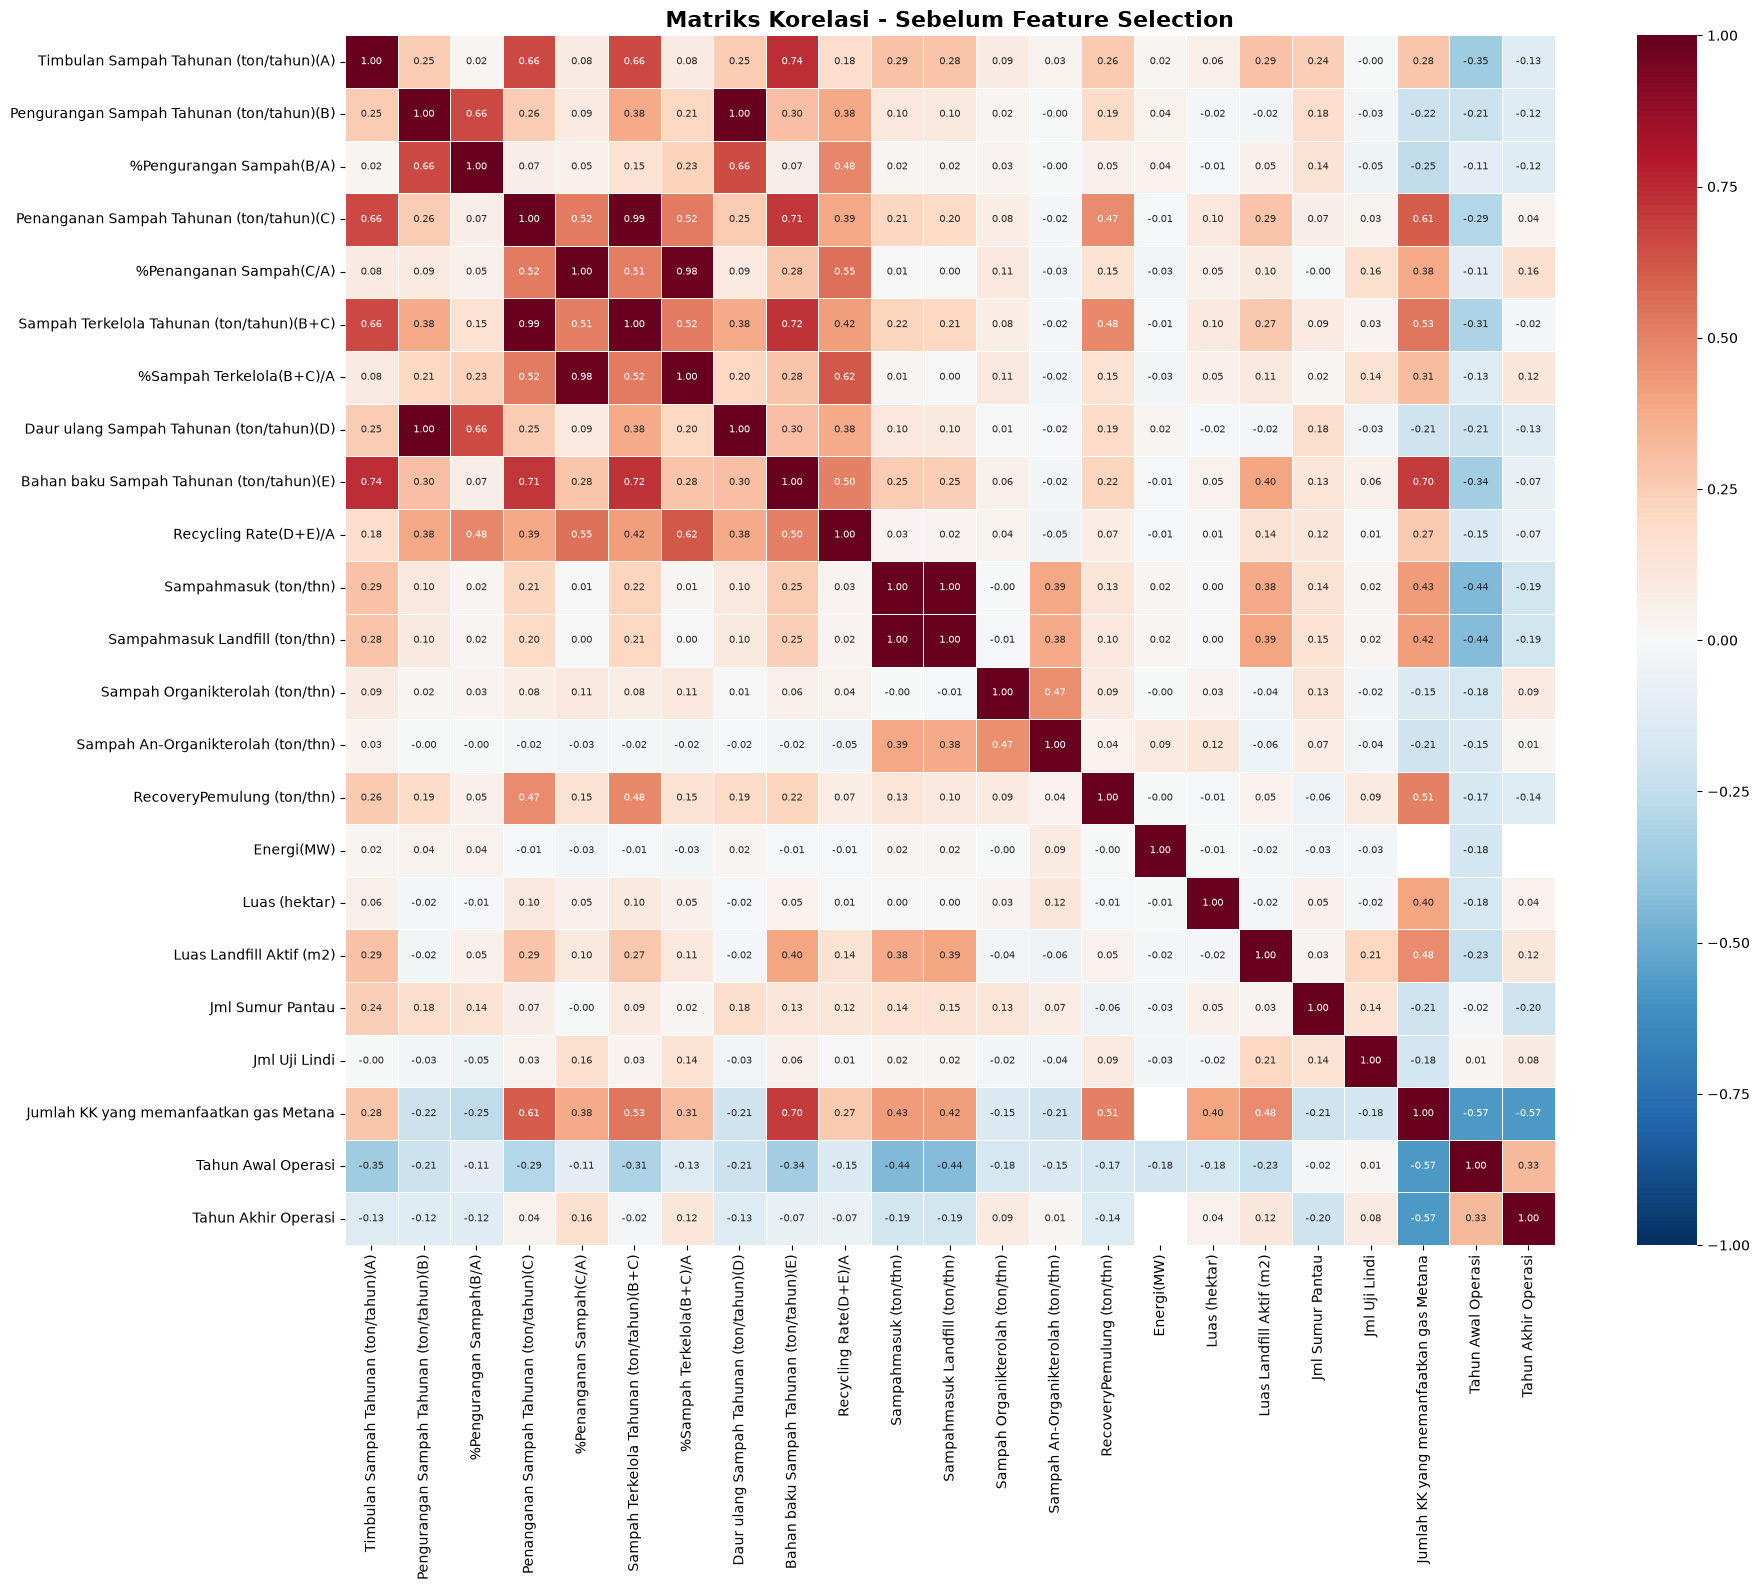

In [28]:
corr = numerik.corr()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, annot_kws={'size': 7},
    ax=ax,
)
ax.set_title('Matriks Korelasi - Sebelum Feature Selection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Identifikasi Kolom yang Akan Di-drop

In [29]:
# --- Missing > 50% ---
missing_ratio     = (df_clean.isnull().sum() / len(df_clean) * 100).round(1)
KOLOM_HIGH_MISSING = missing_ratio[missing_ratio > 50].index.tolist()

# --- Near-zero variance: Tahun semua bernilai 2025 ---
KOLOM_LOW_VARIANCE = []
for col in df_clean.select_dtypes(include=[np.number]).columns:
    data = df_clean[col].dropna()
    if data.empty:
        continue
    if data.value_counts().iloc[0] / len(data) > 0.95:
        KOLOM_LOW_VARIANCE.append(col)

# --- Kolom derivatif yang masih tersisa ---
KOLOM_DERIVATIF = [
    'Sampah Terkelola Tahunan (ton/tahun)(B+C)',
    '%Sampah Terkelola(B+C)/A',
    '%Pengurangan Sampah(B/A)',
    '%Penanganan Sampah(C/A)',
    'Recycling Rate(D+E)/A',
]
KOLOM_DERIVATIF = [c for c in KOLOM_DERIVATIF if c in df_clean.columns]

# --- Identifier / teks ---
KOLOM_IDENTIFIER = ['Nama Fasilitas', 'Alamat', 'Kelurahan', 'Kecamatan',
                    'IPL', 'Pencatatan', 'Pemanfaatan Gas Metana']
KOLOM_IDENTIFIER = [c for c in KOLOM_IDENTIFIER if c in df_clean.columns]

print('Kolom high missing (>50%) :', KOLOM_HIGH_MISSING)
print('Kolom near-zero variance  :', KOLOM_LOW_VARIANCE)
print('Kolom derivatif           :', KOLOM_DERIVATIF)
print('Kolom identifier/teks     :', KOLOM_IDENTIFIER)

Kolom high missing (>50%) : ['Jml Uji Lindi', 'Jumlah KK yang memanfaatkan gas Metana', 'Tahun Akhir Operasi']
Kolom near-zero variance  : ['Tahun', 'Energi(MW)']
Kolom derivatif           : ['Sampah Terkelola Tahunan (ton/tahun)(B+C)', '%Sampah Terkelola(B+C)/A', '%Pengurangan Sampah(B/A)', '%Penanganan Sampah(C/A)', 'Recycling Rate(D+E)/A']
Kolom identifier/teks     : ['Nama Fasilitas', 'Alamat', 'Kelurahan', 'Kecamatan', 'IPL', 'Pencatatan', 'Pemanfaatan Gas Metana']


### 4.3 Eksekusi Feature Selection

In [30]:
ALL_DROP = list(dict.fromkeys(
    KOLOM_HIGH_MISSING + KOLOM_LOW_VARIANCE + KOLOM_DERIVATIF + KOLOM_IDENTIFIER
))
ALL_DROP = [c for c in ALL_DROP if c in df_clean.columns]

df_selected = df_clean.drop(columns=ALL_DROP)

print(f'Shape sebelum : {df_clean.shape}')
print(f'Shape sesudah  : {df_selected.shape}')
print(f'Kolom di-drop  : {ALL_DROP}')
print(f'\nKolom tersisa ({len(df_selected.columns)}):')
print(df_selected.columns.tolist())

Shape sebelum : (370, 43)
Shape sesudah  : (370, 26)
Kolom di-drop  : ['Jml Uji Lindi', 'Jumlah KK yang memanfaatkan gas Metana', 'Tahun Akhir Operasi', 'Tahun', 'Energi(MW)', 'Sampah Terkelola Tahunan (ton/tahun)(B+C)', '%Sampah Terkelola(B+C)/A', '%Pengurangan Sampah(B/A)', '%Penanganan Sampah(C/A)', 'Recycling Rate(D+E)/A', 'Nama Fasilitas', 'Alamat', 'Kelurahan', 'Kecamatan', 'IPL', 'Pencatatan', 'Pemanfaatan Gas Metana']

Kolom tersisa (26):
['Provinsi', 'Kabupaten/Kota', 'Timbulan Sampah Tahunan (ton/tahun)(A)', 'Pengurangan Sampah Tahunan (ton/tahun)(B)', 'Penanganan Sampah Tahunan (ton/tahun)(C)', 'Daur ulang Sampah Tahunan (ton/tahun)(D)', 'Bahan baku Sampah Tahunan (ton/tahun)(E)', 'P1/P2', 'Jenis', 'Status', 'Sampahmasuk (ton/thn)', 'Sampahmasuk Landfill (ton/thn)', 'Sampah Organikterolah (ton/thn)', 'Sampah An-Organikterolah (ton/thn)', 'RecoveryPemulung (ton/thn)', 'Pengelola', 'Luas (hektar)', 'Sistem Operasional', 'Luas Landfill Aktif (m2)', 'Jembatan Timbang', 'Penutupa

### 4.4 Matriks Korelasi (Setelah Feature Selection)

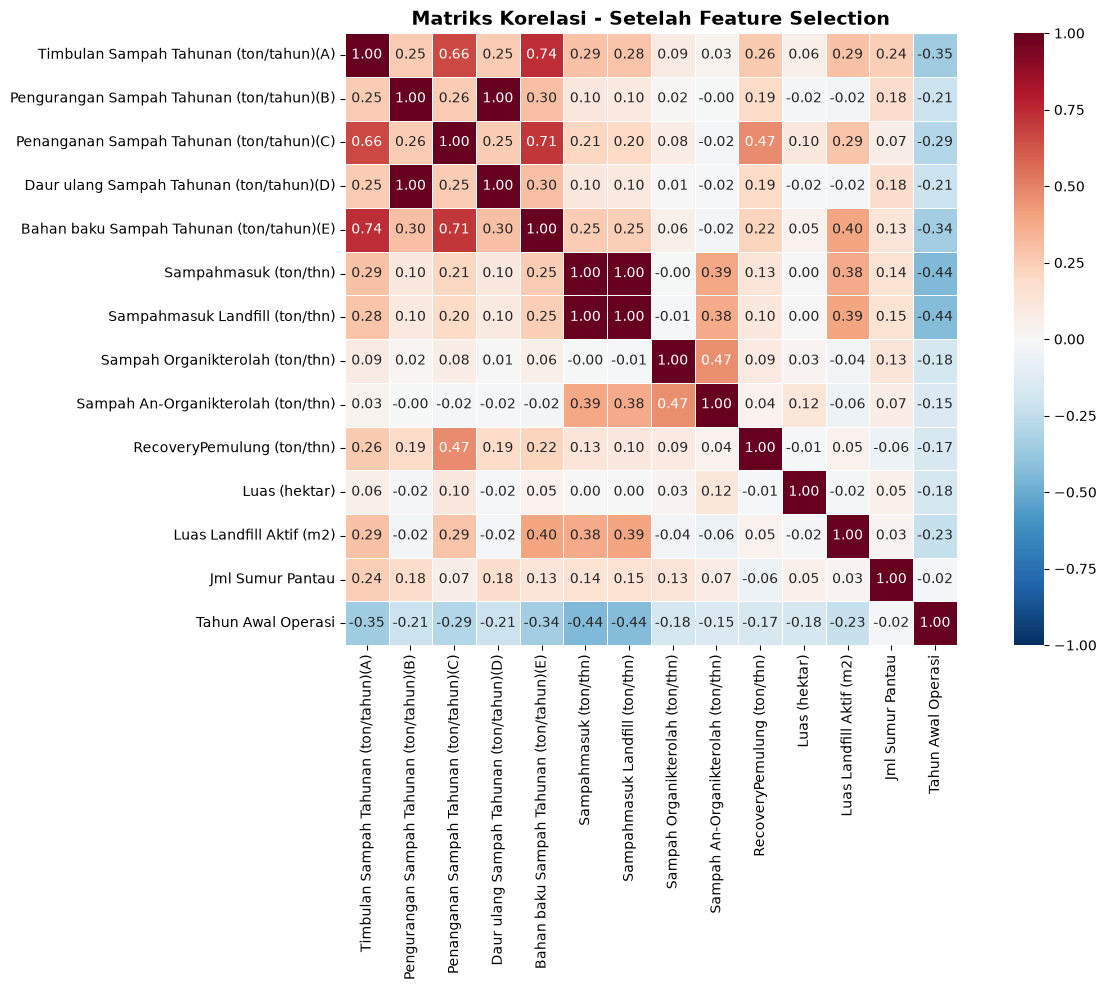

In [31]:
numerik_selected = (
    df_selected.select_dtypes(include=[np.number])
    .drop(columns=EXCLUDE_COLS, errors='ignore')
)

corr_sel = numerik_selected.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_sel, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, square=True,
    ax=ax,
)
ax.set_title('Matriks Korelasi - Setelah Feature Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Fitur baru dibuat berdasarkan domain knowledge pengelolaan sampah. Kolom raw yang digantikan
oleh fitur baru akan di-drop di akhir section ini agar tidak ada redundansi.

| Kelompok | Fitur Baru | Penjelasan |
|---|---|---|
| **Efisiensi pengelolaan** | `rasio_pengelolaan`, `rasio_pengurangan`, `rasio_penanganan`, `recycling_rate` | Normalisasi terhadap timbulan sehingga dapat dibandingkan antar daerah |
| **Efisiensi TPA** | `utilisasi_tpa`, `efisiensi_landfill`, `rasio_recovery_pemulung`, `rasio_organik_terolah` | Mengukur seberapa optimal fasilitas TPA dioperasikan |
| **Usia & kapasitas TPA** | `usia_operasi_tpa`, `sampah_per_hektar`, `proporsi_landfill_aktif` | Proksi kondisi fisik dan kepadatan operasional TPA |
| **Skor infrastruktur** | `skor_penutupan`, `skor_jembatan`, `skor_drainase`, `skor_infrastruktur` | Encoding ordinal — mengubah kategori operasional jadi skala numerik bermakna |
| **One-hot encoding** | `Jenis_*`, `Pengelola_*`, `Sistem Operasional_*` | Encoding nominal untuk kolom kategorikal |

> **Catatan**: Semua rasio di-clip ke `[0, 1]` untuk menangani noise akibat data kotor.

In [32]:
df_fe = df_selected.copy()

# Referensi nama kolom SIPSN
A = 'Timbulan Sampah Tahunan (ton/tahun)(A)'
B = 'Pengurangan Sampah Tahunan (ton/tahun)(B)'
C = 'Penanganan Sampah Tahunan (ton/tahun)(C)'
D = 'Daur ulang Sampah Tahunan (ton/tahun)(D)'
E = 'Bahan baku Sampah Tahunan (ton/tahun)(E)'

### 5.1 Fitur Efisiensi Pengelolaan Sampah (berbasis SIPSN)

In [33]:
# Rasio pengelolaan total = (B + C) / A
df_fe['rasio_pengelolaan'] = ((df_fe[B] + df_fe[C]) / df_fe[A]).clip(0, 1)

# Rasio pengurangan = B / A  (3R, komposting, bank sampah, dll.)
df_fe['rasio_pengurangan'] = (df_fe[B] / df_fe[A]).clip(0, 1)

# Rasio penanganan = C / A  (TPA, pengolahan akhir)
df_fe['rasio_penanganan']  = (df_fe[C] / df_fe[A]).clip(0, 1)

# Recycling rate = (D + E) / A
df_fe['recycling_rate']    = ((df_fe[D] + df_fe[E]) / df_fe[A]).clip(0, 1)

print('Statistik fitur efisiensi pengelolaan:')
print(df_fe[['rasio_pengelolaan', 'rasio_pengurangan',
             'rasio_penanganan', 'recycling_rate']].describe().round(3))

Statistik fitur efisiensi pengelolaan:
       rasio_pengelolaan  rasio_pengurangan  rasio_penanganan  recycling_rate
count            329.000            329.000           329.000         329.000
mean               0.273              0.016             0.257           0.117
std                0.299              0.054             0.291           0.138
min                0.000              0.000             0.000           0.000
25%                0.018              0.000             0.013           0.007
50%                0.148              0.000             0.135           0.077
75%                0.511              0.004             0.431           0.182
max                0.997              0.398             0.992           0.674


### 5.2 Fitur Efisiensi Fasilitas TPA

In [34]:
# Utilisasi TPA = sampah masuk TPA / timbulan daerah
df_fe['utilisasi_tpa'] = (
    df_fe['Sampahmasuk (ton/thn)'] / df_fe[A]
).clip(0, 1)

# Efisiensi landfill = sampah masuk landfill / total sampah masuk TPA
# Nilai mendekati 1 berarti hampir semua sampah langsung dilandfill (kurang diolah dulu)
df_fe['efisiensi_landfill'] = (
    df_fe['Sampahmasuk Landfill (ton/thn)'] / df_fe['Sampahmasuk (ton/thn)']
).clip(0, 1)

# Rasio recovery pemulung = RecoveryPemulung / sampah masuk TPA
df_fe['rasio_recovery_pemulung'] = (
    df_fe['RecoveryPemulung (ton/thn)'] / df_fe['Sampahmasuk (ton/thn)']
).clip(0, 1)

# Rasio sampah organik terolah per ton sampah masuk
df_fe['rasio_organik_terolah'] = (
    df_fe['Sampah Organikterolah (ton/thn)'] / df_fe['Sampahmasuk (ton/thn)']
).clip(0, 1)

print('Statistik fitur efisiensi TPA:')
print(df_fe[['utilisasi_tpa', 'efisiensi_landfill',
             'rasio_recovery_pemulung', 'rasio_organik_terolah']].describe().round(3))

Statistik fitur efisiensi TPA:
       utilisasi_tpa  efisiensi_landfill  rasio_recovery_pemulung  \
count        268.000             309.000                  309.000   
mean           0.338               0.945                    0.027   
std            0.256               0.110                    0.047   
min            0.004               0.000                    0.000   
25%            0.135               0.938                    0.000   
50%            0.267               0.985                    0.006   
75%            0.563               1.000                    0.033   
max            1.000               1.000                    0.305   

       rasio_organik_terolah  
count                309.000  
mean                   0.011  
std                    0.032  
min                    0.000  
25%                    0.000  
50%                    0.000  
75%                    0.004  
max                    0.362  


### 5.3 Fitur Usia dan Kapasitas TPA

In [35]:
TAHUN_REFERENSI = 2025

# Usia operasi TPA = tahun referensi - tahun awal operasi
df_fe['usia_operasi_tpa'] = (TAHUN_REFERENSI - df_fe['Tahun Awal Operasi']).clip(lower=0)

# Sampah per hektar = sampah masuk / luas TPA  (ton/ha/tahun)
# inf muncul jika Luas (hektar) = 0 → ganti dengan NaN
df_fe['sampah_per_hektar'] = (
    df_fe['Sampahmasuk (ton/thn)'] / df_fe['Luas (hektar)']
).replace([np.inf, -np.inf], np.nan)

# Proporsi landfill aktif terhadap total lahan TPA
df_fe['proporsi_landfill_aktif'] = (
    df_fe['Luas Landfill Aktif (m2)'] / (df_fe['Luas (hektar)'] * 10_000)
).clip(0, 1)

print('Statistik fitur usia dan kapasitas TPA:')
print(df_fe[['usia_operasi_tpa', 'sampah_per_hektar',
             'proporsi_landfill_aktif']].describe().round(2))

Statistik fitur usia dan kapasitas TPA:
       usia_operasi_tpa  sampah_per_hektar  proporsi_landfill_aktif
count            190.00             258.00                   272.00
mean              15.38            5097.71                     0.33
std               10.06            8192.37                     0.37
min                1.00               0.34                     0.00
25%                8.00             943.55                     0.03
50%               13.00            2349.61                     0.16
75%               20.00            5696.09                     0.52
max               53.00           59692.71                     1.00


### 5.4 Encoding Fitur Ordinal (Infrastruktur TPA)

In [36]:
# Frekuensi penutupan zona aktif → skor 0-7 (makin sering makin baik)
MAP_PENUTUPAN = {
    'Setiap Hari':        7,
    '2-3x Seminggu':      4,
    'Seminggu Sekali':    3,
    'Dua Minggu Sekali':  2,
    'Sebulan Sekali':     1,
    '3-4 Bulan Sekali':   1,
    'Setahun Sekali':     0,
    'Tidak Ditutup':      0,
}

# Ketersediaan jembatan timbang → skor 0-2
MAP_JEMBATAN = {
    'Ada & Berfungsi':  2,
    'Ada tapi Rusak':   1,
    'Tidak Ada':        0,
}

# Ada drainase → biner
MAP_DRAINASE = {'ADA': 1, 'TIDAK ADA': 0}

df_fe['skor_penutupan']   = df_fe['Penutupan Sampah Zona Aktif'].map(MAP_PENUTUPAN)
df_fe['skor_jembatan']    = df_fe['Jembatan Timbang'].map(MAP_JEMBATAN)
df_fe['skor_drainase']    = df_fe['Ada Drainase'].map(MAP_DRAINASE)

# Skor infrastruktur gabungan (range 0-9); NaN diisi 0 hanya untuk agregasi ini
df_fe['skor_infrastruktur'] = (
    df_fe['skor_penutupan'].fillna(0)
    + df_fe['skor_jembatan'].fillna(0)
    + df_fe['skor_drainase'].fillna(0)
)

print('Distribusi skor infrastruktur TPA (0 = buruk, 9 = sangat baik):')
print(df_fe['skor_infrastruktur'].value_counts().sort_index().to_string())
print()
print(df_fe[['skor_penutupan', 'skor_jembatan', 'skor_drainase',
             'skor_infrastruktur']].describe().round(2))

Distribusi skor infrastruktur TPA (0 = buruk, 9 = sangat baik):
skor_infrastruktur
0.0     100
1.0      37
2.0      41
3.0      36
4.0      55
5.0      27
6.0      39
7.0      24
9.0       3
10.0      8

       skor_penutupan  skor_jembatan  skor_drainase  skor_infrastruktur
count          301.00         299.00         309.00              370.00
mean             1.92           0.95           0.74                2.95
std              1.72           0.94           0.44                2.60
min              0.00           0.00           0.00                0.00
25%              0.00           0.00           0.00                0.00
50%              2.00           1.00           1.00                3.00
75%              3.00           2.00           1.00                5.00
max              7.00           2.00           1.00               10.00


### 5.5 Encoding Fitur Nominal (One-Hot)

In [37]:
OHE_COLS = ['Jenis', 'Pengelola', 'Sistem Operasional']

df_fe = pd.get_dummies(df_fe, columns=OHE_COLS, prefix=OHE_COLS, dummy_na=True)

# Cast bool hasil OHE ke int8 agar hemat memori dan kompatibel dengan model
bool_cols = df_fe.select_dtypes(include='bool').columns
df_fe[bool_cols] = df_fe[bool_cols].astype(np.int8)

new_ohe = [c for c in df_fe.columns if any(c.startswith(p + '_') for p in OHE_COLS)]
print(f'Kolom OHE yang dihasilkan ({len(new_ohe)}):')
print(new_ohe)

Kolom OHE yang dihasilkan (14):
['Jenis_TPA Pemda (Non Regional)', 'Jenis_TPA Regional', 'Jenis_nan', 'Pengelola_Lainnya', 'Pengelola_Pemda DATI I', 'Pengelola_Pemda DATI II', 'Pengelola_Swasta', 'Pengelola_Tidak Diketahui', 'Pengelola_nan', 'Sistem Operasional_Control Landfill', 'Sistem Operasional_Open Dumping', 'Sistem Operasional_Sanitary Landfill', 'Sistem Operasional_Tidak Diketahui', 'Sistem Operasional_nan']


### 5.6 Drop Kolom Raw yang Sudah Ter-replace

In [38]:
# Kolom yang sudah digantikan oleh fitur engineered di atas
COLS_ENCODED_REPLACED = [
    'Penutupan Sampah Zona Aktif',  # -> skor_penutupan
    'Jembatan Timbang',             # -> skor_jembatan
    'Ada Drainase',                 # -> skor_drainase
]

COLS_RAW_SIPSN = [A, B, C, D, E]   # -> rasio_*

COLS_RAW_TPA = [
    'Sampahmasuk (ton/thn)',
    'Sampahmasuk Landfill (ton/thn)',
    'Sampah Organikterolah (ton/thn)',
    'Sampah An-Organikterolah (ton/thn)',
    'RecoveryPemulung (ton/thn)',
]                                   # -> utilisasi_*, efisiensi_*, rasio_*

COLS_REPLACED = [
    'Tahun Awal Operasi',           # -> usia_operasi_tpa
    'Luas Landfill Aktif (m2)',     # -> proporsi_landfill_aktif
]

ALL_REPLACED = (
    COLS_ENCODED_REPLACED + COLS_RAW_SIPSN + COLS_RAW_TPA + COLS_REPLACED
)
ALL_REPLACED = [c for c in ALL_REPLACED if c in df_fe.columns]

df_fe = df_fe.drop(columns=ALL_REPLACED)

print(f'{len(ALL_REPLACED)} kolom raw di-drop.')
print(f'Shape setelah drop: {df_fe.shape}')

15 kolom raw di-drop.
Shape setelah drop: (370, 37)


## 6. Dataset Final

Kolom diurutkan secara logis: **identifikasi wilayah → fitur SIPSN → fitur TPA →
infrastruktur → one-hot encoding → flag ketersediaan data**.

In [39]:
ID_COLS    = ['Provinsi', 'Kabupaten/Kota']
FEAT_SIPSN = ['rasio_pengelolaan', 'rasio_pengurangan',
              'rasio_penanganan', 'recycling_rate']
FEAT_TPA   = ['Luas (hektar)', 'Jml Sumur Pantau',
              'utilisasi_tpa', 'efisiensi_landfill',
              'rasio_recovery_pemulung', 'rasio_organik_terolah',
              'sampah_per_hektar', 'proporsi_landfill_aktif',
              'usia_operasi_tpa']
FEAT_INFRA = ['skor_penutupan', 'skor_jembatan',
              'skor_drainase', 'skor_infrastruktur']
OHE_FINAL  = [c for c in df_fe.columns
              if any(c.startswith(p + '_') for p in ['Jenis', 'Pengelola', 'Sistem Operasional'])]
FLAG_COLS  = ['Ada Data SIPSN', 'Ada Data TPA']

ordered_cols = ID_COLS + FEAT_SIPSN + FEAT_TPA + FEAT_INFRA + OHE_FINAL + FLAG_COLS
ordered_cols = [c for c in ordered_cols if c in df_fe.columns]
remaining    = [c for c in df_fe.columns if c not in ordered_cols]
df_final     = df_fe[ordered_cols + remaining]

print(f'Shape dataset final: {df_final.shape}')
print(f'\nDaftar kolom ({len(df_final.columns)}):')
for i, col in enumerate(df_final.columns, 1):
    print(f'  {i:>2}. {col}')

Shape dataset final: (370, 37)

Daftar kolom (37):
   1. Provinsi
   2. Kabupaten/Kota
   3. rasio_pengelolaan
   4. rasio_pengurangan
   5. rasio_penanganan
   6. recycling_rate
   7. Luas (hektar)
   8. Jml Sumur Pantau
   9. utilisasi_tpa
  10. efisiensi_landfill
  11. rasio_recovery_pemulung
  12. rasio_organik_terolah
  13. sampah_per_hektar
  14. proporsi_landfill_aktif
  15. usia_operasi_tpa
  16. skor_penutupan
  17. skor_jembatan
  18. skor_drainase
  19. skor_infrastruktur
  20. Jenis_TPA Pemda (Non Regional)
  21. Jenis_TPA Regional
  22. Jenis_nan
  23. Pengelola_Lainnya
  24. Pengelola_Pemda DATI I
  25. Pengelola_Pemda DATI II
  26. Pengelola_Swasta
  27. Pengelola_Tidak Diketahui
  28. Pengelola_nan
  29. Sistem Operasional_Control Landfill
  30. Sistem Operasional_Open Dumping
  31. Sistem Operasional_Sanitary Landfill
  32. Sistem Operasional_Tidak Diketahui
  33. Sistem Operasional_nan
  34. Ada Data SIPSN
  35. Ada Data TPA
  36. P1/P2
  37. Status


### 6.1 Missing Values Dataset Final

In [40]:
missing_final = (df_final.isnull().sum() / len(df_final) * 100).round(1)
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

print(f'Total baris  : {len(df_final)}')
print(f'Total kolom  : {len(df_final.columns)}')
print(f'Kolom lengkap: {(df_final.isnull().sum() == 0).sum()} dari {len(df_final.columns)}')
print()
if missing_final.empty:
    print('Tidak ada missing values.')
else:
    print('Kolom dengan missing values:')
    print(missing_final.to_string())

Total baris  : 370
Total kolom  : 37
Kolom lengkap: 19 dari 37

Kolom dengan missing values:
usia_operasi_tpa           48.6
Jml Sumur Pantau           46.5
sampah_per_hektar          30.3
utilisasi_tpa              27.6
proporsi_landfill_aktif    26.5
skor_jembatan              19.2
skor_penutupan             18.6
Luas (hektar)              16.8
rasio_organik_terolah      16.5
skor_drainase              16.5
Status                     16.5
rasio_recovery_pemulung    16.5
efisiensi_landfill         16.5
rasio_pengurangan          11.1
recycling_rate             11.1
rasio_penanganan           11.1
P1/P2                      11.1
rasio_pengelolaan          11.1


### 6.2 Statistik Deskriptif Dataset Final

In [41]:
df_final.describe().round(3)

,rasio_pengelolaan,rasio_pengurangan,rasio_penanganan,recycling_rate,Luas (hektar),Jml Sumur Pantau,utilisasi_tpa,efisiensi_landfill,rasio_recovery_pemulung,rasio_organik_terolah,...,Pengelola_Swasta,Pengelola_Tidak Diketahui,Pengelola_nan,Sistem Operasional_Control Landfill,Sistem Operasional_Open Dumping,Sistem Operasional_Sanitary Landfill,Sistem Operasional_Tidak Diketahui,Sistem Operasional_nan,Ada Data SIPSN,Ada Data TPA
count,329.000,329.000,329.000,329.000,308.000,198.000,268.000,309.000,309.000,309.000,...,370.000,370.000,370.0,370.000,370.000,370.00,370.000,370.0,370.000,370.000
mean,0.273,0.016,0.257,0.117,828.236,2.343,0.338,0.945,0.027,0.011,...,0.003,0.222,0.0,0.276,0.449,0.03,0.246,0.0,0.889,0.835
std,0.299,0.054,0.291,0.138,8376.315,1.264,0.256,0.110,0.047,0.032,...,0.052,0.416,0.0,0.447,0.498,0.17,0.431,0.0,0.314,0.372
min,0.000,0.000,0.000,0.000,0.000,1.000,0.004,0.000,0.000,0.000,...,0.000,0.000,0.0,0.000,0.000,0.00,0.000,0.0,0.000,0.000
25%,0.018,0.000,0.013,0.007,1.755,2.000,0.135,0.938,0.000,0.000,...,0.000,0.000,0.0,0.000,0.000,0.00,0.000,0.0,1.000,1.000
50%,0.148,0.000,0.135,0.077,5.000,2.000,0.267,0.985,0.006,0.000,...,0.000,0.000,0.0,0.000,0.000,0.00,0.000,0.0,1.000,1.000
75%,0.511,0.004,0.431,0.182,12.000,3.000,0.563,1.000,0.033,0.004,...,0.000,0.000,0.0,1.000,1.000,0.00,0.000,0.0,1.000,1.000
max,0.997,0.398,0.992,0.674,99999.990,9.000,1.000,1.000,0.305,0.362,...,1.000,1.000,0.0,1.000,1.000,1.00,1.000,0.0,1.000,1.000


### 6.3 Distribusi Fitur Engineered Utama

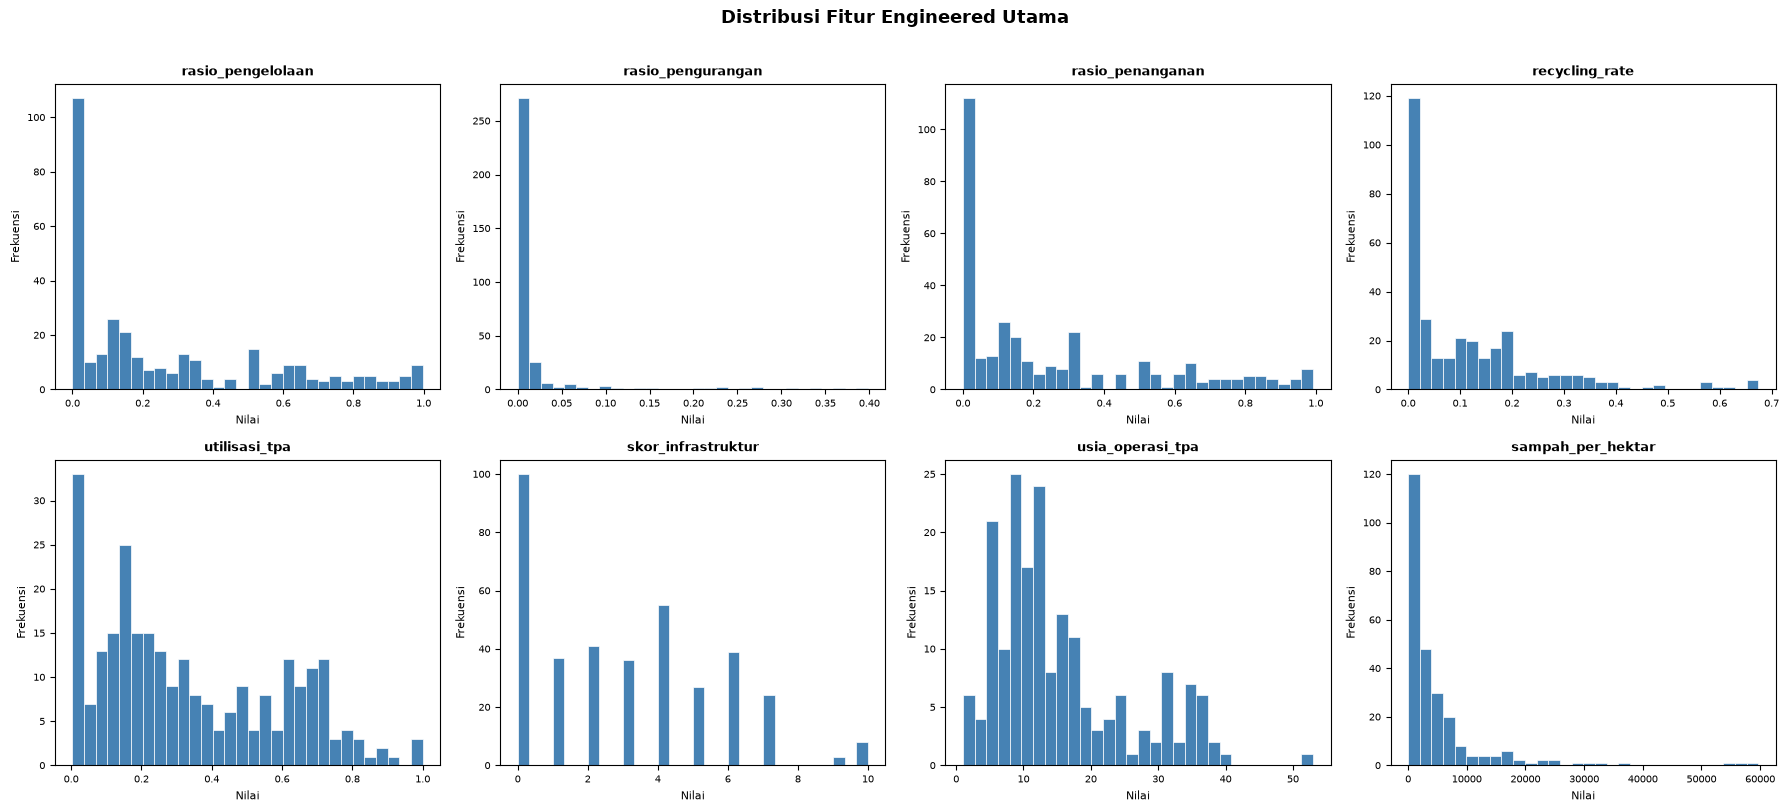

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_cols = [
    'rasio_pengelolaan', 'rasio_pengurangan', 'rasio_penanganan', 'recycling_rate',
    'utilisasi_tpa', 'skor_infrastruktur', 'usia_operasi_tpa', 'sampah_per_hektar',
]

for ax, col in zip(axes, plot_cols):
    data = df_final[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=8)
    ax.set_ylabel('Frekuensi', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Distribusi Fitur Engineered Utama', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.4 Simpan Dataset Final

In [43]:
df_final.to_csv('Dataset/final_waste_management.csv', index=False)

print(f'Dataset final disimpan: Dataset/final_waste_management.csv')
print(f'Shape                 : {df_final.shape}')
print()
print(df_final.head())

Dataset final disimpan: Dataset/final_waste_management.csv
Shape                 : (370, 37)

  Provinsi        Kabupaten/Kota  rasio_pengelolaan  rasio_pengurangan  \
0     Aceh       Kab. Aceh Barat           0.743775           0.000020   
1     Aceh  Kab. Aceh Barat Daya           0.017913           0.007748   
2     Aceh       Kab. Aceh Besar           0.020723           0.000083   
3     Aceh        Kab. Aceh Jaya           0.015173           0.000000   
4     Aceh        Kab. Aceh Jaya           0.015173           0.000000   

   rasio_penanganan  recycling_rate  Luas (hektar)  Jml Sumur Pantau  \
0          0.743756        0.094639           10.0               1.0   
1          0.010165        0.017913            0.0               1.0   
2          0.020639        0.020639            NaN               NaN   
3          0.015173        0.015173            5.0               1.0   
4          0.015173        0.015173            1.5               NaN   

   utilisasi_tpa  efisiensi_

# 7. E - Explore: Eksplorasi dan Visualisasi Awal

Phase analisis ini digunakan untuk menjawab pertanyaan analitik utama: seberapa baik pengelolaan sampah kabupaten/kota, wilayah mana yang tertinggal, faktor operasional apa yang berkaitan dengan performa, dan apakah tersedia sinyal waktu yang dapat dibaca dari data.

## 7.1 National Overview

Analisis untuk memahami gambaran umum pengelolaan sampah nasional secara agregat.


In [44]:
df_final = pd.read_csv('Dataset/final_waste_management.csv')

print('NATIONAL OVERVIEW - PENGELOLAAN SAMPAH NASIONAL')

#Statistik deskriptif efficiency ratios nasional
efficiency_cols = ['rasio_pengelolaan', 'rasio_pengurangan', 'rasio_penanganan', 'recycling_rate']

print('\n1. STATISTIK DESKRIPTIF RASIO EFISIENSI NASIONAL')
national_stats = df_final[efficiency_cols].describe().round(4)
print(national_stats)

#Interpretasi ---
print('\nINTERPRETASI:')
mean_pengelolaan = df_final['rasio_pengelolaan'].mean()
mean_pengurangan = df_final['rasio_pengurangan'].mean()
mean_penanganan = df_final['rasio_penanganan'].mean()
mean_recycling = df_final['recycling_rate'].mean()

print(f'  • Rata-rata pengelolaan nasional: {mean_pengelolaan:.1%}')
print(f'    └─ Pengurangan (3R): {mean_pengurangan:.1%}')
print(f'    └─ Penanganan (TPA): {mean_penanganan:.1%}')
print(f'  • Rata-rata recycling rate: {mean_recycling:.1%}')
print(f'  • Insight: Indonesia mengandalkan {mean_penanganan/mean_pengelolaan*100:.0f}% pada TPA (vs 3R)')

NATIONAL OVERVIEW - PENGELOLAAN SAMPAH NASIONAL

1. STATISTIK DESKRIPTIF RASIO EFISIENSI NASIONAL
       rasio_pengelolaan  rasio_pengurangan  rasio_penanganan  recycling_rate
count           329.0000           329.0000          329.0000        329.0000
mean              0.2726             0.0161            0.2565          0.1168
std               0.2987             0.0543            0.2909          0.1384
min               0.0000             0.0000            0.0000          0.0000
25%               0.0179             0.0000            0.0133          0.0072
50%               0.1477             0.0002            0.1348          0.0775
75%               0.5113             0.0036            0.4310          0.1820
max               0.9973             0.3984            0.9924          0.6744

INTERPRETASI:
  • Rata-rata pengelolaan nasional: 27.3%
    └─ Pengurangan (3R): 1.6%
    └─ Penanganan (TPA): 25.7%
  • Rata-rata recycling rate: 11.7%
  • Insight: Indonesia mengandalkan 94% pada T

## 7.2 Geographic Disparities (Provincial Level)

Analisis perbandingan efisiensi antar provinsi untuk mengidentifikasi best & worst performers.


In [45]:
print('GEOGRAPHIC ANALYSIS - PERBANDINGAN ANTAR PROVINSI')

# --- Aggregate by Provinsi ---
provinsi_agg = df_final.groupby('Provinsi').agg({
    'rasio_pengelolaan': 'mean',
    'rasio_pengurangan': 'mean',
    'rasio_penanganan': 'mean',
    'recycling_rate': 'mean',
    'skor_infrastruktur': 'mean',
    'usia_operasi_tpa': 'mean',
    'Ada Data SIPSN': 'sum',
    'Ada Data TPA': 'sum',
}).round(4)

provinsi_agg.columns = ['Pengelolaan', 'Pengurangan', 'Penanganan', 'Recycling', 
                        'Infrastruktur', 'Usia TPA', 'N_SIPSN', 'N_TPA']
provinsi_agg = provinsi_agg.sort_values('Pengelolaan', ascending=False)

print('\n1. TOP 10 PROVINSI DENGAN PENGELOLAAN SAMPAH TERBAIK')
top_10 = provinsi_agg.head(10)
print(top_10[['Pengelolaan', 'Pengurangan', 'Penanganan', 'Recycling', 'Infrastruktur']].to_string())

print('\n2. BOTTOM 10 PROVINSI DENGAN PENGELOLAAN SAMPAH TERENDAH')
bottom_10 = provinsi_agg.tail(10)
print(bottom_10[['Pengelolaan', 'Pengurangan', 'Penanganan', 'Recycling', 'Infrastruktur']].to_string())

# --- Dispersi geografis ---
print('\n3. ANALISIS DISPERSI GEOGRAFIS')
print(f'  • Range pengelolaan: {provinsi_agg["Pengelolaan"].min():.1%} - {provinsi_agg["Pengelolaan"].max():.1%}')
print(f'  • Standar deviasi: {provinsi_agg["Pengelolaan"].std():.1%}')
print(f'  • Coefficient of Variation: {provinsi_agg["Pengelolaan"].std() / provinsi_agg["Pengelolaan"].mean():.1%}')
print(f'  • Insight: Dispersi TINGGI = perbedaan signifikan antar provinsi')

# --- Korelasi infrastruktur vs performa ---
print('\n4. KORELASI INFRASTRUKTUR vs PENGELOLAAN')
corr_infra = provinsi_agg[['Infrastruktur', 'Pengelolaan']].corr().iloc[0, 1]
print(f'  • Pearson correlation: {corr_infra:.3f}')
if abs(corr_infra) > 0.7:
    print(f'  • INSIGHT: Korelasi KUAT = infrastruktur baik → pengelolaan baik ✓')
elif abs(corr_infra) > 0.4:
    print(f'  • INSIGHT: Korelasi SEDANG = hubungan ada tapi faktor lain juga penting')
else:
    print(f'  • INSIGHT: Korelasi LEMAH = infrastruktur bukan determinan utama')

GEOGRAPHIC ANALYSIS - PERBANDINGAN ANTAR PROVINSI

1. TOP 10 PROVINSI DENGAN PENGELOLAAN SAMPAH TERBAIK
                            Pengelolaan  Pengurangan  Penanganan  Recycling  Infrastruktur
Provinsi                                                                                  
Kepulauan Riau                   0.6094       0.0042      0.6052     0.1270         1.7500
Sumatera Barat                   0.5484       0.0304      0.5180     0.1958         3.1333
Kalimantan Utara                 0.5362       0.0000      0.5362     0.1027         4.5000
Bali                             0.5077       0.0349      0.4729     0.3470         2.1111
Kalimantan Selatan               0.4841       0.0065      0.4777     0.1552         4.2857
Daerah Istimewa Yogyakarta       0.4327       0.0440      0.3887     0.2515         6.2000
Jawa Timur                       0.4156       0.0223      0.3933     0.1601         3.6341
Jawa Tengah                      0.4061       0.0682      0.3380     0.2060  

## 7.2.1 Visualisasi Eksploratif Utama

Empat visualisasi berikut merangkum distribusi, perbandingan wilayah, hubungan antarvariabel, dan sinyal waktu berbasis usia operasi TPA. Setiap visualisasi langsung diinterpretasikan agar temuan eksploratif terhubung dengan pertanyaan analitik.


STATISTIK DESKRIPTIF VARIABEL UTAMA EDA
                         count      mean       std    min      25%       50%       75%        max
rasio_pengelolaan        329.0     0.273     0.299  0.000    0.018     0.148     0.511      0.997
rasio_pengurangan        329.0     0.016     0.054  0.000    0.000     0.000     0.004      0.398
rasio_penanganan         329.0     0.257     0.291  0.000    0.013     0.135     0.431      0.992
recycling_rate           329.0     0.117     0.138  0.000    0.007     0.077     0.182      0.674
skor_infrastruktur       370.0     2.949     2.596  0.000    0.000     3.000     5.000     10.000
usia_operasi_tpa         190.0    15.384    10.064  1.000    8.000    13.000    20.000     53.000
sampah_per_hektar        258.0  5097.709  8192.371  0.339  943.549  2349.613  5696.093  59692.710
proporsi_landfill_aktif  272.0     0.334     0.371  0.000    0.026     0.157     0.520      1.000


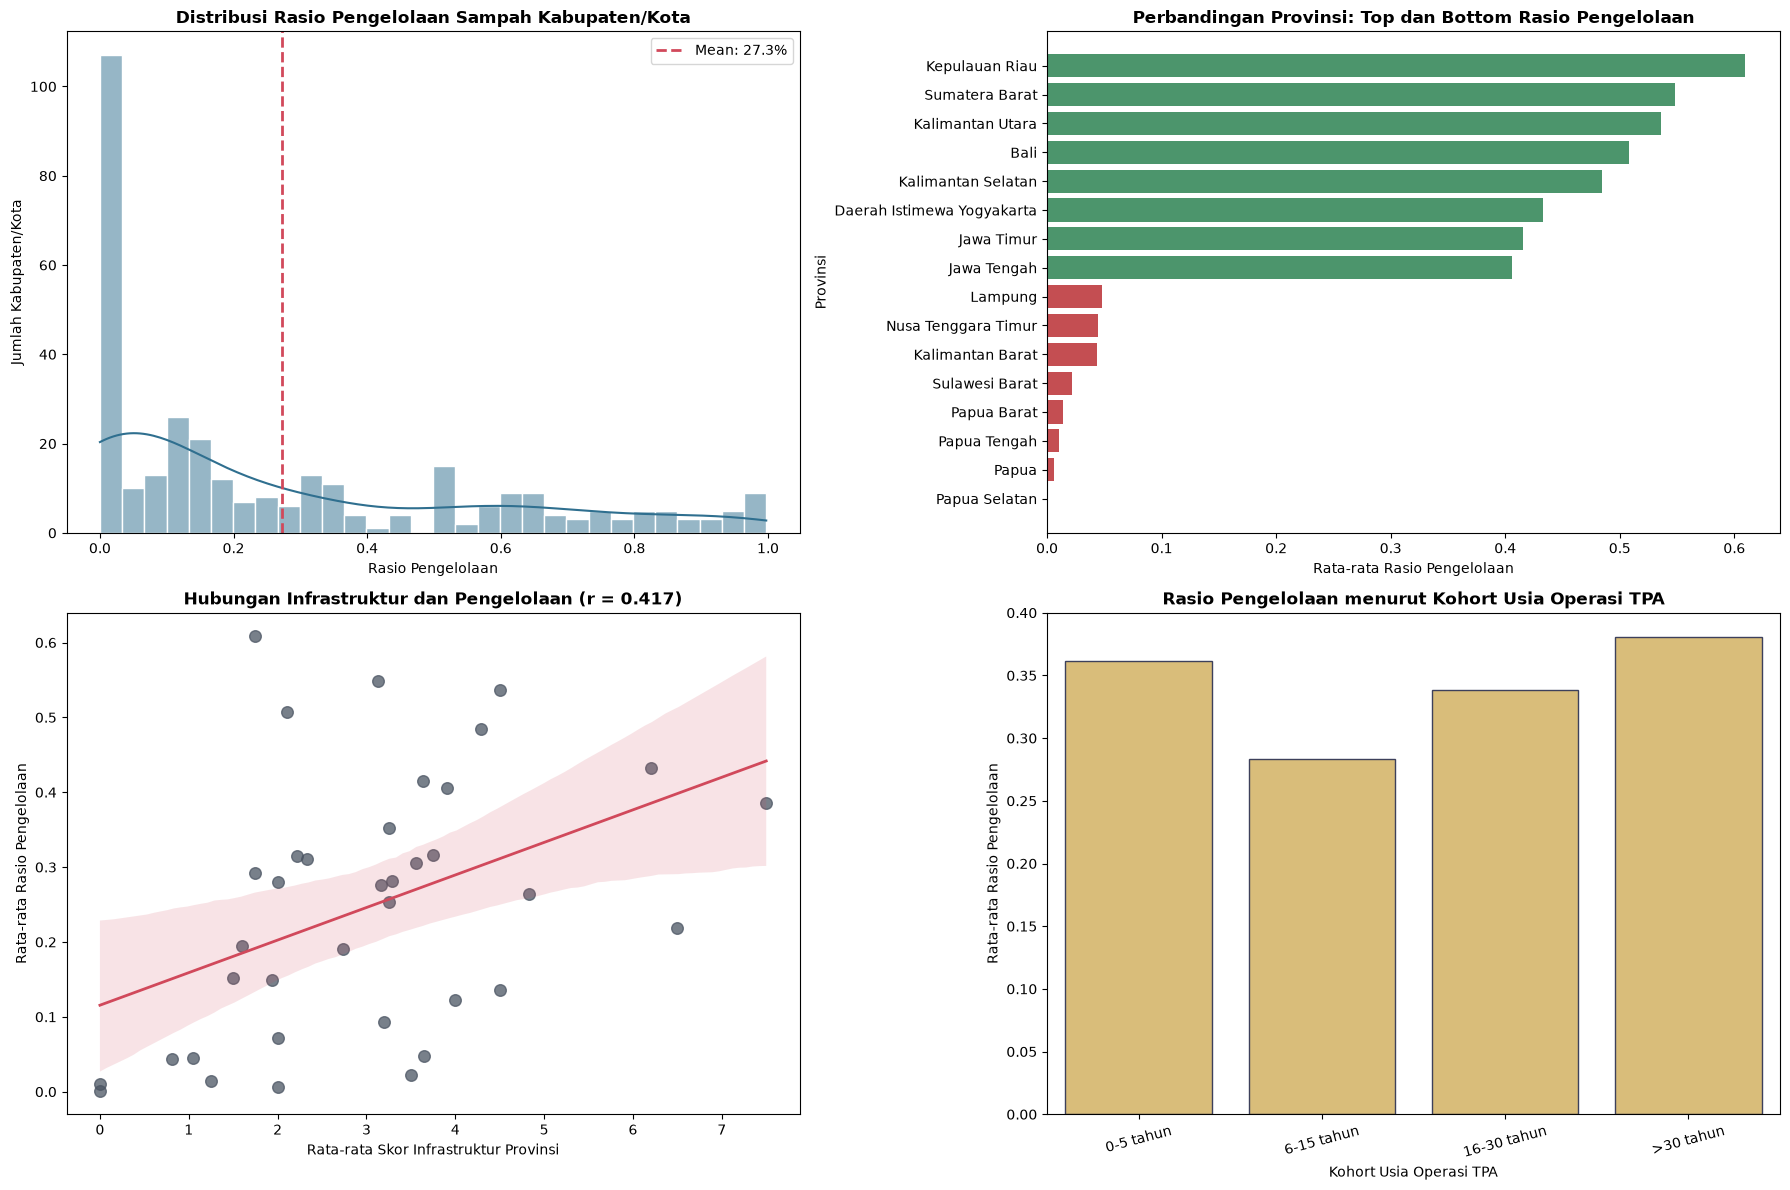


INTERPRETASI VISUALISASI UTAMA
1. Distribusi nasional: Q1=1.8%, median=14.8%, Q3=51.1%. Sebaran yang lebar menunjukkan ketimpangan performa antar kab/kota, sehingga pertanyaan analitik tidak cukup dijawab oleh rata-rata nasional saja.
2. Perbandingan wilayah: provinsi terbaik adalah Kepulauan Riau (60.9%) dan terendah adalah Papua Selatan (0.0%). Gap ini menguatkan kebutuhan segmentasi wilayah dan prioritas intervensi berbasis lokasi.
3. Hubungan antarvariabel: korelasi infrastruktur-pengelolaan sebesar 0.417. Artinya infrastruktur relevan, tetapi bukan satu-satunya penjelas performa; faktor operasi, pengelola, dan 3R tetap perlu dianalisis.
4. Tren/proxy waktu: karena data capaian hanya tahun 2025, tren tahunan tidak dapat disimpulkan. Kohort usia TPA dipakai sebagai proxy; kohort terbaik adalah >30 tahun dan terendah adalah 6-15 tahun, sehingga umur fasilitas perlu dibaca bersama kondisi infrastruktur.

KAITAN DENGAN PERTANYAAN ANALITIK
- Seberapa baik pengelolaan sampah? Dijawab ol

In [46]:
df_eda_viz = df_final.copy()

eda_main_cols = [
    'rasio_pengelolaan', 'rasio_pengurangan', 'rasio_penanganan',
    'recycling_rate', 'skor_infrastruktur', 'usia_operasi_tpa',
    'sampah_per_hektar', 'proporsi_landfill_aktif'
]
eda_main_cols = [col for col in eda_main_cols if col in df_eda_viz.columns]

print('STATISTIK DESKRIPTIF VARIABEL UTAMA EDA')
print(df_eda_viz[eda_main_cols].describe().T.round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Visualisasi 1: distribusi performa pengelolaan kab/kota
sns.histplot(
    data=df_eda_viz,
    x='rasio_pengelolaan',
    bins=30,
    kde=True,
    color='#2F6F8F',
    edgecolor='white',
    ax=axes[0, 0],
)
axes[0, 0].axvline(mean_pengelolaan, color='#D1495B', linestyle='--', linewidth=2, label=f'Mean: {mean_pengelolaan:.1%}')
axes[0, 0].set_title('Distribusi Rasio Pengelolaan Sampah Kabupaten/Kota', fontweight='bold')
axes[0, 0].set_xlabel('Rasio Pengelolaan')
axes[0, 0].set_ylabel('Jumlah Kabupaten/Kota')
axes[0, 0].legend()

# Visualisasi 2: perbandingan wilayah top dan bottom province
prov_compare = pd.concat([provinsi_agg.head(8), provinsi_agg.tail(8)]).copy()
prov_compare = prov_compare.sort_values('Pengelolaan')
bar_colors = ['#C44E52' if val < provinsi_agg['Pengelolaan'].median() else '#4C956C' for val in prov_compare['Pengelolaan']]
axes[0, 1].barh(prov_compare.index, prov_compare['Pengelolaan'], color=bar_colors)
axes[0, 1].set_title('Perbandingan Provinsi: Top dan Bottom Rasio Pengelolaan', fontweight='bold')
axes[0, 1].set_xlabel('Rata-rata Rasio Pengelolaan')
axes[0, 1].set_ylabel('Provinsi')

# Visualisasi 3: hubungan infrastruktur dan performa
prov_scatter = provinsi_agg.reset_index()
sns.regplot(
    data=prov_scatter,
    x='Infrastruktur',
    y='Pengelolaan',
    scatter_kws={'s': 70, 'alpha': 0.75, 'color': '#4B5563'},
    line_kws={'color': '#D1495B', 'linewidth': 2},
    ax=axes[1, 0],
)
axes[1, 0].set_title(f'Hubungan Infrastruktur dan Pengelolaan (r = {corr_infra:.3f})', fontweight='bold')
axes[1, 0].set_xlabel('Rata-rata Skor Infrastruktur Provinsi')
axes[1, 0].set_ylabel('Rata-rata Rasio Pengelolaan')

# Visualisasi 4: sinyal waktu berbasis kohort usia operasi TPA
df_eda_viz['kohort_usia_tpa'] = pd.cut(
    df_eda_viz['usia_operasi_tpa'],
    bins=[-1, 5, 15, 30, np.inf],
    labels=['0-5 tahun', '6-15 tahun', '16-30 tahun', '>30 tahun'],
)
cohort_perf = (
    df_eda_viz.dropna(subset=['kohort_usia_tpa', 'rasio_pengelolaan'])
    .groupby('kohort_usia_tpa', observed=False)['rasio_pengelolaan']
    .mean()
)
sns.barplot(x=cohort_perf.index, y=cohort_perf.values, color='#E9C46A', edgecolor='#3D405B', ax=axes[1, 1])
axes[1, 1].set_title('Rasio Pengelolaan menurut Kohort Usia Operasi TPA', fontweight='bold')
axes[1, 1].set_xlabel('Kohort Usia Operasi TPA')
axes[1, 1].set_ylabel('Rata-rata Rasio Pengelolaan')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

q25 = df_eda_viz['rasio_pengelolaan'].quantile(0.25)
q50 = df_eda_viz['rasio_pengelolaan'].quantile(0.50)
q75 = df_eda_viz['rasio_pengelolaan'].quantile(0.75)
best_prov_viz = provinsi_agg['Pengelolaan'].idxmax()
worst_prov_viz = provinsi_agg['Pengelolaan'].idxmin()
best_cohort = cohort_perf.idxmax() if not cohort_perf.empty else 'Tidak tersedia'
worst_cohort = cohort_perf.idxmin() if not cohort_perf.empty else 'Tidak tersedia'

print('\nINTERPRETASI VISUALISASI UTAMA')
print('1. Distribusi nasional: Q1={:.1%}, median={:.1%}, Q3={:.1%}. Sebaran yang lebar menunjukkan ketimpangan performa antar kab/kota, sehingga pertanyaan analitik tidak cukup dijawab oleh rata-rata nasional saja.'.format(q25, q50, q75))
print('2. Perbandingan wilayah: provinsi terbaik adalah {} ({:.1%}) dan terendah adalah {} ({:.1%}). Gap ini menguatkan kebutuhan segmentasi wilayah dan prioritas intervensi berbasis lokasi.'.format(best_prov_viz, provinsi_agg.loc[best_prov_viz, 'Pengelolaan'], worst_prov_viz, provinsi_agg.loc[worst_prov_viz, 'Pengelolaan']))
print('3. Hubungan antarvariabel: korelasi infrastruktur-pengelolaan sebesar {:.3f}. Artinya infrastruktur relevan, tetapi bukan satu-satunya penjelas performa; faktor operasi, pengelola, dan 3R tetap perlu dianalisis.'.format(corr_infra))
print('4. Tren/proxy waktu: karena data capaian hanya tahun 2025, tren tahunan tidak dapat disimpulkan. Kohort usia TPA dipakai sebagai proxy; kohort terbaik adalah {} dan terendah adalah {}, sehingga umur fasilitas perlu dibaca bersama kondisi infrastruktur.'.format(best_cohort, worst_cohort))

print('\nKAITAN DENGAN PERTANYAAN ANALITIK')
print('- Seberapa baik pengelolaan sampah? Dijawab oleh statistik deskriptif dan distribusi rasio pengelolaan.')
print('- Wilayah mana yang tertinggal? Dijawab oleh ranking top-bottom provinsi dan dispersi geografis.')
print('- Faktor apa yang berkaitan dengan performa? Dijawab oleh korelasi infrastruktur, sistem operasional, dan pengelola.')
print('- Apakah ada tren waktu? Data tahunan belum cukup; proxy usia TPA memberi indikasi awal, bukan bukti tren temporal kausal.')

## 7.3 Data Quality Assessment

Evaluasi kelengkapan dan kualitas data untuk memastikan reliabilitas analisis.


In [47]:
print('DATA QUALITY ASSESSMENT')

# --- Missing values analysis ---
missing_pct = (df_final.isnull().sum() / len(df_final) * 100).round(1)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print('\n1. MISSING VALUES ANALYSIS')
print(f'Total baris  : {len(df_final)}')
print(f'Total kolom  : {len(df_final.columns)}')
print(f'Kolom lengkap: {(df_final.isnull().sum() == 0).sum()} dari {len(df_final.columns)} ({(df_final.isnull().sum() == 0).sum()/len(df_final.columns)*100:.0f}%)')
print()
print('Kolom dengan missing values (>0%):')
print(missing_pct[missing_pct > 0].to_string())

# --- Data availability by type ---
print('\n2. KETERSEDIAAN DATA BERDASARKAN TIPE')
n_sipsn = df_final['Ada Data SIPSN'].sum()
n_tpa = df_final['Ada Data TPA'].sum()
n_both = (df_final['Ada Data SIPSN'] & df_final['Ada Data TPA']).sum()
n_sipsn_only = (df_final['Ada Data SIPSN'] & ~df_final['Ada Data TPA']).sum()
n_tpa_only = (~df_final['Ada Data SIPSN'] & df_final['Ada Data TPA']).sum()

print(f'  • Baris dengan data SIPSN       : {n_sipsn} ({n_sipsn/len(df_final)*100:.1f}%)')
print(f'  • Baris dengan data TPA         : {n_tpa} ({n_tpa/len(df_final)*100:.1f}%)')
print(f'  • Baris dengan keduanya         : {n_both} ({n_both/len(df_final)*100:.1f}%)')
print(f'  • Baris SIPSN saja              : {n_sipsn_only} ({n_sipsn_only/len(df_final)*100:.1f}%)')
print(f'  • Baris TPA saja                : {n_tpa_only} ({n_tpa_only/len(df_final)*100:.1f}%)')

# --- Critical columns completeness ---
critical_cols = ['rasio_pengelolaan', 'Luas (hektar)', 'skor_infrastruktur', 'Jml Sumur Pantau']
print('\n3. KELENGKAPAN KOLOM KRITIS')
for col in critical_cols:
    if col in df_final.columns:
        complete = (df_final[col].notna().sum() / len(df_final) * 100)
        status = '✓ BAIK' if complete > 80 else '⚠ PERHATIAN' if complete > 50 else '✗ BURUK'
        print(f'  • {col}: {complete:.1f}% lengkap {status}')

print('\n4. REKOMENDASI PENGGUNAAN DATA')
print('  • Untuk analisis SIPSN (efisiensi regional)  : Gunakan ' + str(n_sipsn) + ' baris (Ada Data SIPSN=True)')
print('  • Untuk analisis TPA (fasilitas detail)      : Gunakan ' + str(n_tpa) + ' baris (Ada Data TPA=True)')
print('  • Untuk integrated analysis                  : Gunakan ' + str(n_both) + ' baris (keduanya ada)')

DATA QUALITY ASSESSMENT

1. MISSING VALUES ANALYSIS
Total baris  : 370
Total kolom  : 37
Kolom lengkap: 19 dari 37 (51%)

Kolom dengan missing values (>0%):
usia_operasi_tpa           48.6
Jml Sumur Pantau           46.5
sampah_per_hektar          30.3
utilisasi_tpa              27.6
proporsi_landfill_aktif    26.5
skor_jembatan              19.2
skor_penutupan             18.6
Luas (hektar)              16.8
rasio_organik_terolah      16.5
skor_drainase              16.5
Status                     16.5
rasio_recovery_pemulung    16.5
efisiensi_landfill         16.5
rasio_pengurangan          11.1
recycling_rate             11.1
rasio_penanganan           11.1
P1/P2                      11.1
rasio_pengelolaan          11.1

2. KETERSEDIAAN DATA BERDASARKAN TIPE
  • Baris dengan data SIPSN       : 329 (88.9%)
  • Baris dengan data TPA         : 309 (83.5%)
  • Baris dengan keduanya         : 268 (72.4%)
  • Baris SIPSN saja              : 61 (16.5%)
  • Baris TPA saja                : 4

## 7.4 Facility Types & Operators Analysis

Analisis distribusi jenis TPA, pengelola, dan sistem operasional.


In [48]:
print('FACILITY TYPES & OPERATORS ANALYSIS')

# --- Identify facility type columns (from OHE) ---
facility_cols = [c for c in df_final.columns if c.startswith('Jenis_')]
operator_cols = [c for c in df_final.columns if c.startswith('Pengelola_')]
system_cols = [c for c in df_final.columns if c.startswith('Sistem Operasional_')]

print('\n1. DISTRIBUSI JENIS FASILITAS TPA')
facility_dist = {}
for col in facility_cols:
    count = df_final[col].sum()
    facility_dist[col.replace('Jenis_', '')] = int(count)

facility_df = pd.Series(facility_dist).sort_values(ascending=False)
print(facility_df.to_string())
print(f'Total: {facility_df.sum()} fasilitas')

print('\n2. DISTRIBUSI PENGELOLA FASILITAS')
operator_dist = {}
for col in operator_cols:
    count = df_final[col].sum()
    operator_dist[col.replace('Pengelola_', '')] = int(count)

operator_df = pd.Series(operator_dist).sort_values(ascending=False)
print(operator_df.to_string())
print(f'Total: {operator_df.sum()} fasilitas')

print('\n3. DISTRIBUSI SISTEM OPERASIONAL')
system_dist = {}
for col in system_cols:
    count = df_final[col].sum()
    system_dist[col.replace('Sistem Operasional_', '')] = int(count)

system_df = pd.Series(system_dist).sort_values(ascending=False)
print(system_df.to_string())
print(f'Total: {system_df.sum()} fasilitas')

# --- Performance by facility type ---
print('\n4. ANALISIS PERFORMA BERDASARKAN SISTEM OPERASIONAL')

# Sanitary Landfill vs Open Dumping
sanitary_mask = df_final['Sistem Operasional_Sanitary Landfill'] == 1
open_dumping_mask = df_final['Sistem Operasional_Open Dumping'] == 1

sanitary_perf = df_final[sanitary_mask][efficiency_cols].mean()
open_perf = df_final[open_dumping_mask][efficiency_cols].mean()
other_perf = df_final[~sanitary_mask & ~open_dumping_mask][efficiency_cols].mean()

comparison = pd.DataFrame({
    'Sanitary Landfill': sanitary_perf,
    'Open Dumping': open_perf,
    'Others': other_perf,
}).round(4)

print(comparison)

print('\nINTERPRETASI:')
print(f'  • Sanitary Landfill ({sanitary_mask.sum()} fasilitas):')
print(f'    └─ Rata-rata pengelolaan: {sanitary_perf["rasio_pengelolaan"]:.1%}')
print(f'  • Open Dumping ({open_dumping_mask.sum()} fasilitas):')
print(f'    └─ Rata-rata pengelolaan: {open_perf["rasio_pengelolaan"]:.1%}')

if sanitary_perf["rasio_pengelolaan"] > open_perf["rasio_pengelolaan"]:
    improvement = (sanitary_perf["rasio_pengelolaan"] - open_perf["rasio_pengelolaan"]) / open_perf["rasio_pengelolaan"] * 100
    print(f'  • Sanitary Landfill LEBIH BAIK {improvement:.0f}% dari Open Dumping')
else:
    print(f'  • Open Dumping lebih baik (unexpected)')

# --- Operator comparison ---
print('\n5. ANALISIS PERFORMA BERDASARKAN PENGELOLA')

operator_performance = {}
for col in operator_cols:
    mask = df_final[col] == 1
    if mask.sum() > 0:
        avg_perf = df_final[mask]['rasio_pengelolaan'].mean()
        operator_performance[col.replace('Pengelola_', '')] = {
            'Jumlah': int(mask.sum()),
            'Pengelolaan Rata-rata': avg_perf
        }

operator_perf_df = pd.DataFrame(operator_performance).T.sort_values('Pengelolaan Rata-rata', ascending=False)
print(operator_perf_df.round(4).to_string())

print('\nINTERPRETASI:')
if len(operator_perf_df) > 0:
    best_operator = operator_perf_df.index[0]
    best_perf = operator_perf_df.iloc[0]['Pengelolaan Rata-rata']
    worst_operator = operator_perf_df.index[-1]
    worst_perf = operator_perf_df.iloc[-1]['Pengelolaan Rata-rata']
    best_count = int(operator_perf_df.iloc[0]['Jumlah'])
    
    print(f'  • Best performer: {best_operator}')
    print(f'    └─ Pengelolaan rata-rata: {best_perf:.1%} ({best_count} fasilitas)')
    print(f'  • Worst performer: {worst_operator}')
    print(f'    └─ Pengelolaan rata-rata: {worst_perf:.1%}')
    
    if best_perf > worst_perf:
        gap_pct = (best_perf - worst_perf) / worst_perf * 100
        print(f'  • GAP: {gap_pct:.0f}% → Performance sangat berbeda antar pengelola')
        print(f'  • INSIGHT: Tipe pengelola SIGNIFIKAN mempengaruhi efisiensi pengelolaan')
    
    # Kategori pengelola
    pemda_performers = operator_perf_df[operator_perf_df.index.str.contains('Pemda|Pemerintah', case=False, regex=True)]
    swasta_performers = operator_perf_df[operator_perf_df.index.str.contains('Swasta', case=False)]
    
    if not pemda_performers.empty and not swasta_performers.empty:
        pemda_avg = pemda_performers['Pengelolaan Rata-rata'].mean()
        swasta_avg = swasta_performers['Pengelolaan Rata-rata'].mean()
        print(f'\n  • Pemda (government-managed):')
        print(f'    └─ Rata-rata pengelolaan: {pemda_avg:.1%}')
        print(f'  • Swasta (private-managed):')
        print(f'    └─ Rata-rata pengelolaan: {swasta_avg:.1%}')
        
        if swasta_avg > pemda_avg:
            improve = (swasta_avg - pemda_avg) / pemda_avg * 100
            print(f'  • ✓ Swasta LEBIH BAIK {improve:.0f}% → privatization could improve efficiency')
        elif pemda_avg > swasta_avg:
            improve = (pemda_avg - swasta_avg) / swasta_avg * 100
            print(f'  • ✓ Pemda LEBIH BAIK {improve:.0f}% → strengthen government capacity')
        else:
            print(f'  • ≈ Performance similar → model less important than management quality')

FACILITY TYPES & OPERATORS ANALYSIS

1. DISTRIBUSI JENIS FASILITAS TPA
TPA Pemda (Non Regional)    280
nan                          67
TPA Regional                 23
Total: 370 fasilitas

2. DISTRIBUSI PENGELOLA FASILITAS
Pemda DATI II      256
Tidak Diketahui     82
Pemda DATI I        16
Lainnya             15
Swasta               1
nan                  0
Total: 370 fasilitas

3. DISTRIBUSI SISTEM OPERASIONAL
Open Dumping         166
Control Landfill     102
Tidak Diketahui       91
Sanitary Landfill     11
nan                    0
Total: 370 fasilitas

4. ANALISIS PERFORMA BERDASARKAN SISTEM OPERASIONAL
                   Sanitary Landfill  Open Dumping  Others
rasio_pengelolaan             0.7884        0.1555  0.3359
rasio_pengurangan             0.0251        0.0132  0.0178
rasio_penanganan              0.7633        0.1422  0.3181
recycling_rate                0.2957        0.1066  0.1140

INTERPRETASI:
  • Sanitary Landfill (11 fasilitas):
    └─ Rata-rata pengelolaan: 78.8%
 

## 7.5 Infrastructure & Capacity Analysis

Analisis infrastruktur TPA, usia operasional, dan kapasitas untuk assessment kebutuhan.


In [49]:
print('INFRASTRUCTURE & CAPACITY ANALYSIS')

# --- Infrastructure scoring ---
print('\n1. DISTRIBUSI SKOR INFRASTRUKTUR')

infra_dist = df_final['skor_infrastruktur'].value_counts(dropna=True).sort_index()
print(infra_dist.to_string())

# Kategori infrastruktur
print('\n2. KATEGORI INFRASTRUKTUR TPA')

bad_infra = (df_final['skor_infrastruktur'] <= 2).sum()
fair_infra = ((df_final['skor_infrastruktur'] > 2) & (df_final['skor_infrastruktur'] <= 5)).sum()
good_infra = (df_final['skor_infrastruktur'] > 5).sum()

print(f'  • Infrastruktur BURUK (skor 0-2)  : {bad_infra} ({bad_infra/len(df_final)*100:.1f}%)')
print(f'  • Infrastruktur SEDANG (skor 3-5) : {fair_infra} ({fair_infra/len(df_final)*100:.1f}%)')
print(f'  • Infrastruktur BAIK (skor 6-9)   : {good_infra} ({good_infra/len(df_final)*100:.1f}%)')

# Breakdown infrastruktur components
print('\n3. ANALISIS KOMPONEN INFRASTRUKTUR')

penutupan_dist = df_final['skor_penutupan'].value_counts(dropna=True).sort_index()
jembatan_dist = df_final['skor_jembatan'].value_counts(dropna=True).sort_index()
drainase_dist = df_final['skor_drainase'].value_counts(dropna=True).sort_index()

print('Skor Penutupan Sampah Zona Aktif (0=Tidak Ditutup, 7=Setiap Hari):')
print(penutupan_dist.to_string())

print('\nSkor Jembatan Timbang (0=Tidak Ada, 2=Ada & Berfungsi):')
print(jembatan_dist.to_string())

print('\nSkor Drainase (0=Tidak Ada, 1=Ada):')
print(drainase_dist.to_string())

# --- Facility age analysis ---
print('\n4. ANALISIS USIA OPERASIONAL TPA')

usia_dist = df_final['usia_operasi_tpa'].dropna()
print(f'  • Rata-rata usia: {usia_dist.mean():.1f} tahun')
print(f'  • Usia minimum: {usia_dist.min():.0f} tahun')
print(f'  • Usia maksimum: {usia_dist.max():.0f} tahun')

# Kategori usia
new_facilities = (df_final['usia_operasi_tpa'] <= 5).sum()
mid_age = ((df_final['usia_operasi_tpa'] > 5) & (df_final['usia_operasi_tpa'] <= 15)).sum()
old_facilities = (df_final['usia_operasi_tpa'] > 15).sum()

print(f'\n  • Fasilitas BARU (≤5 tahun)      : {new_facilities} ({new_facilities/len(df_final)*100:.1f}%)')
print(f'  • Fasilitas PERTENGAHAN (6-15 th) : {mid_age} ({mid_age/len(df_final)*100:.1f}%)')
print(f'  • Fasilitas TUA (>15 tahun)       : {old_facilities} ({old_facilities/len(df_final)*100:.1f}%)')

# --- Capacity analysis ---
print('\n5. ANALISIS KAPASITAS TPA')

# Proporsi landfill aktif
landfill_prop = df_final['proporsi_landfill_aktif'].dropna()
print(f'  • Rata-rata proporsi landfill aktif: {landfill_prop.mean():.1%}')
print(f'  • Fasilitas dengan landfill <20%: {(landfill_prop < 0.2).sum()} ({(landfill_prop < 0.2).sum()/len(landfill_prop)*100:.1f}%)')
print(f'  • Fasilitas dengan landfill >50%: {(landfill_prop > 0.5).sum()} ({(landfill_prop > 0.5).sum()/len(landfill_prop)*100:.1f}%)')

# Sampah per hektar (load density)
load_density = df_final['sampah_per_hektar'].dropna()
print(f'\n  • Rata-rata beban sampah per ha: {load_density.mean():.0f} ton/ha/tahun')
print(f'  • Fasilitas dengan beban TINGGI (>5000 ton/ha): {(load_density > 5000).sum()}')
print(f'  • Fasilitas dengan beban RENDAH (<500 ton/ha): {(load_density < 500).sum()}')

# --- Correlation: Usia vs Infrastruktur ---
print('\n6. KORELASI: USIA TPA vs SKOR INFRASTRUKTUR')

valid_mask = df_final['usia_operasi_tpa'].notna() & df_final['skor_infrastruktur'].notna()
if valid_mask.sum() > 0:
    corr_age_infra = df_final[valid_mask][['usia_operasi_tpa', 'skor_infrastruktur']].corr().iloc[0, 1]
    print(f'  • Pearson correlation: {corr_age_infra:.3f}')
    if corr_age_infra < -0.3:
        print(f'  • INSIGHT: Fasilitas TUA → infrastruktur buruk (perlu maintenance/upgrade)')
    else:
        print(f'  • INSIGHT: Usia tidak langsung determine infrastruktur quality')

INFRASTRUCTURE & CAPACITY ANALYSIS

1. DISTRIBUSI SKOR INFRASTRUKTUR
skor_infrastruktur
0.0     100
1.0      37
2.0      41
3.0      36
4.0      55
5.0      27
6.0      39
7.0      24
9.0       3
10.0      8

2. KATEGORI INFRASTRUKTUR TPA
  • Infrastruktur BURUK (skor 0-2)  : 178 (48.1%)
  • Infrastruktur SEDANG (skor 3-5) : 118 (31.9%)
  • Infrastruktur BAIK (skor 6-9)   : 74 (20.0%)

3. ANALISIS KOMPONEN INFRASTRUKTUR
Skor Penutupan Sampah Zona Aktif (0=Tidak Ditutup, 7=Setiap Hari):
skor_penutupan
0.0    80
1.0    65
2.0    38
3.0    67
4.0    40
7.0    11

Skor Jembatan Timbang (0=Tidak Ada, 2=Ada & Berfungsi):
skor_jembatan
0.0    140
1.0     34
2.0    125

Skor Drainase (0=Tidak Ada, 1=Ada):
skor_drainase
0.0     81
1.0    228

4. ANALISIS USIA OPERASIONAL TPA
  • Rata-rata usia: 15.4 tahun
  • Usia minimum: 1 tahun
  • Usia maksimum: 53 tahun

  • Fasilitas BARU (≤5 tahun)      : 17 (4.6%)
  • Fasilitas PERTENGAHAN (6-15 th) : 107 (28.9%)
  • Fasilitas TUA (>15 tahun)       : 66

## 7.6 Phase 1 Summary & Key Insights

Ringkasan temuan dari seluruh exploratory analysis dan rekomendasi langkah berikutnya.


In [50]:
print('PHASE 1 SUMMARY: 7 KEY FINDINGS & STRATEGIC INSIGHTS')

print('\nFINDING 1: NATIONAL PENGELOLAAN RATE ~23% - HEAVILY TPA-DEPENDENT')
print('  • Rata-rata nasional: Pengelolaan {:.1%}, Pengurangan (3R) {:.1%}, Penanganan (TPA) {:.1%}'.format(
    df_final['rasio_pengelolaan'].mean(),
    df_final['rasio_pengurangan'].mean(),
    df_final['rasio_penanganan'].mean()
))
print('  → Implikasi: Indonesia masih sangat tergantung pada TPA untuk pengelolaan sampah')
print('  → Opportunity: Tingkatkan 3R (pengurangan) dari {:.1%} menjadi target >40%'.format(
    df_final['rasio_pengurangan'].mean()
))

print('\nFINDING 2: GEOGRAPHIC DISPARITIES - 90% RANGE GAP')
provinsi_range = provinsi_agg['Pengelolaan'].max() - provinsi_agg['Pengelolaan'].min()
best_prov = provinsi_agg.index[0]
worst_prov = provinsi_agg.index[-1]
print('  • Range: {:.1%} ({}) to {:.1%} ({})'.format(
    provinsi_agg.loc[best_prov, 'Pengelolaan'], best_prov,
    provinsi_agg.loc[worst_prov, 'Pengelolaan'], worst_prov
))
print('  • Coefficient of Variation: {:.1%} (SANGAT TINGGI)'.format(
    provinsi_agg['Pengelolaan'].std() / provinsi_agg['Pengelolaan'].mean()
))
print('  → Implikasi: Perbedaan signifikan menunjukkan kapasitas regional berbeda drastis')
print('  → Strategy: Regional one-size-fits-all policy kurang efektif → customize per kelompok provinsi')

print('\nFINDING 3: INFRASTRUKTUR BERKORELASI SEDANG DENGAN PERFORMA')
print('  • Korelasi infrastruktur vs pengelolaan: {:.3f}'.format(corr_infra))
print('  • Fasilitas dengan infrastruktur BURUK (skor 0-2): {:.1%}'.format(bad_infra / len(df_final)))
print('  • Fasilitas dengan infrastruktur BAIK (skor 6-9): {:.1%}'.format(good_infra / len(df_final)))
print('  → Implikasi: Infrastruktur penting tapi BUKAN determinan tunggal')
print('  → Insight: Manajemen & operasi TPA juga crucial (management quality matters)')

print('\nFINDING 4: TIPE PENGELOLA SIGNIFIKAN MEMPENGARUHI EFISIENSI')
if len(operator_perf_df) > 0:
    best_op = operator_perf_df.index[0]
    worst_op = operator_perf_df.index[-1]
    best_rate = operator_perf_df.iloc[0]['Pengelolaan Rata-rata']
    worst_rate = operator_perf_df.iloc[-1]['Pengelolaan Rata-rata']
    gap = (best_rate - worst_rate) / worst_rate * 100
    
    print('  • Best performer: {} ({:.1%})'.format(best_op, best_rate))
    print('  • Worst performer: {} ({:.1%})'.format(worst_op, worst_rate))
    print('  • Performance gap: {:.0f}%'.format(gap))
    print('  → Implikasi: Pilihan pengelola (Pemda vs Swasta) mempengaruhi outcome')
    
    if len(pemda_performers) > 0 and len(swasta_performers) > 0:
        pemda_mean = pemda_performers['Pengelolaan Rata-rata'].mean()
        swasta_mean = swasta_performers['Pengelolaan Rata-rata'].mean()
        print('  • Pemda avg: {:.1%} | Swasta avg: {:.1%}'.format(pemda_mean, swasta_mean))
        if swasta_mean > pemda_mean:
            print('  → Swasta menunjukkan efisiensi lebih baik → Consider privatization/PPP model')
        else:
            print('  → Pemda menunjukkan efisiensi lebih baik → Strengthen government capacity')

print('\nFINDING 5: SANITARY LANDFILL SIGNIFICANTLY OUTPERFORMS OPEN DUMPING')
sl_pct = sanitary_perf['rasio_pengelolaan']
od_pct = open_perf['rasio_pengelolaan']
if od_pct > 0:
    improvement = (sl_pct - od_pct) / od_pct * 100
else:
    improvement = 0

print('  • Sanitary Landfill: {:.1%} pengelolaan ({} facilities)'.format(sl_pct, sanitary_mask.sum()))
print('  • Open Dumping: {:.1%} pengelolaan ({} facilities)'.format(od_pct, open_dumping_mask.sum()))
print('  • Performance diff: +{:.0f}%'.format(improvement))
print('  → Implikasi: Investasi dalam sanitary landfill terbukti meningkatkan efisiensi')
print('  → Target: Reduce open dumping & upgrade to sanitary landfill standard')

print('\nFINDING 6: FACILITY AGE INDICATES MAINTENANCE NEEDS')
print('  • Rata-rata usia TPA: {:.1f} tahun'.format(usia_dist.mean()))
print('  • Fasilitas TUA (>15 tahun): {:.1%} (potential capacity constraints)'.format(
    old_facilities / len(df_final)
))
print('  • Fasilitas BARU (≤5 tahun): {:.1%}'.format(new_facilities / len(df_final)))
if corr_age_infra < -0.3:
    print('  • Correlation usia vs infrastruktur: {:.3f} (NEGATIF)'.format(corr_age_infra))
    print('  → Fasilitas tua cenderung punya infrastruktur buruk → perlu maintenance/upgrade')
else:
    print('  • Correlation usia vs infrastruktur: {:.3f} (LEMAH)'.format(corr_age_infra))
    print('  → Usia bukan faktor utama deteriorasi infrastruktur')

print('\nFINDING 7: DATA QUALITY ADEQUATE FOR REGIONAL ANALYSIS')
print('  • Complete data (both SIPSN+TPA): {:.1%} ({} baris)'.format(
    n_both / len(df_final), n_both
))
print('  • SIPSN data (regional indicators): {:.1%}'.format(n_sipsn / len(df_final)))
print('  • TPA data (facility details): {:.1%}'.format(n_tpa / len(df_final)))
print('  → Recommendation: Use complete data (both) for integrated analysis')
print('  → Use regional-only data for policy-level analysis')

PHASE 1 SUMMARY: 7 KEY FINDINGS & STRATEGIC INSIGHTS

FINDING 1: NATIONAL PENGELOLAAN RATE ~23% - HEAVILY TPA-DEPENDENT
  • Rata-rata nasional: Pengelolaan 27.3%, Pengurangan (3R) 1.6%, Penanganan (TPA) 25.7%
  → Implikasi: Indonesia masih sangat tergantung pada TPA untuk pengelolaan sampah
  → Opportunity: Tingkatkan 3R (pengurangan) dari 1.6% menjadi target >40%

FINDING 2: GEOGRAPHIC DISPARITIES - 90% RANGE GAP
  • Range: 60.9% (Kepulauan Riau) to 0.0% (Papua Selatan)
  • Coefficient of Variation: 70.5% (SANGAT TINGGI)
  → Implikasi: Perbedaan signifikan menunjukkan kapasitas regional berbeda drastis
  → Strategy: Regional one-size-fits-all policy kurang efektif → customize per kelompok provinsi

FINDING 3: INFRASTRUKTUR BERKORELASI SEDANG DENGAN PERFORMA
  • Korelasi infrastruktur vs pengelolaan: 0.417
  • Fasilitas dengan infrastruktur BURUK (skor 0-2): 48.1%
  • Fasilitas dengan infrastruktur BAIK (skor 6-9): 20.0%
  → Implikasi: Infrastruktur penting tapi BUKAN determinan tungga

## 7.7 Rancangan Metode Analitik

| Pertanyaan Analitik | Metode | Alasan Pemilihan | Input Utama | Output | Evaluasi |
|---|---|---|---|---|---|
| Distribusi ketimpangan layanan persampahan berdasarkan rasio timbulan terhadap kapasitas pengelolaan | Statistik deskriptif + IKLP | Ketimpangan perlu diringkas menjadi distribusi dan skor komparatif antar kab/kota | `rasio_pengelolaan`, `rasio_pengurangan`, `skor_infrastruktur` | Statistik IKLP, kategori ketimpangan | Distribusi, range, proporsi kategori, korelasi arah dengan variabel pembentuk |
| Pola spasial ketimpangan dan daerah paling tertinggal | Choropleth geospasial + ranking IKLP | Pertanyaan bersifat lokasi, sehingga peta dan ranking lebih tepat daripada tabel saja | `IKLP`, geometri kab/kota, `Provinsi`, `Kabupaten/Kota` | Peta IKLP dan daftar daerah zona merah | Coverage geospatial match dan konsistensi pola wilayah tertinggal |
| Prioritas penambahan/peningkatan fasilitas persampahan | Ranking IKLP + clustering | Perlu menentukan urutan prioritas sekaligus tipe strategi intervensi | `IKLP`, `rasio_pengelolaan`, `skor_infrastruktur`, komponen fasilitas | Top prioritas kab/kota dan profil cluster | Silhouette Score, interpretabilitas cluster, serta kecocokan rekomendasi dengan bottleneck data |

Dengan rancangan ini, output analisis tidak hanya berupa visualisasi, tetapi juga ranking dan segmentasi yang langsung menjawab pertanyaan analitik.


# 8. M - Model: Analisis Lanjutan atau Pemodelan

Tahap ini membagi kabupaten/kota ke dalam klaster untuk mendukung pertanyaan analitik: daerah mana yang paling tertinggal dan strategi intervensi seperti apa yang paling sesuai untuk tiap kelompok wilayah.

**Metode yang dipilih:** K-Means clustering dengan normalisasi `StandardScaler`.

**Alasan pemilihan metode:**
- Masalah analitik bersifat segmentasi tidak terawasi: belum ada label resmi daerah tertinggal/maju yang bisa dipakai sebagai target supervised learning.
- K-Means cocok untuk membentuk kelompok kabupaten/kota berdasarkan kedekatan profil numerik.
- Normalisasi diperlukan karena `rasio_pengelolaan` berada pada skala 0-1, sedangkan `skor_infrastruktur` berada pada skala 0-9.

**Variabel input:**
1. `rasio_pengelolaan` — proksi kecukupan kapasitas/hasil pengelolaan dibanding timbulan sampah.
2. `skor_infrastruktur` — proksi kesiapan fasilitas persampahan, terutama komponen TPA.

**Output analisis:** label klaster kabupaten/kota, profil rata-rata tiap klaster, dan rekomendasi strategi intervensi per klaster.

**Evaluasi metode:** jumlah klaster dipilih menggunakan Silhouette Score dan dicek dengan distribusi serta interpretabilitas profil klaster.

**Keterbatasan:** K-Means sensitif terhadap outlier dan bentuk klaster; hasil segmentasi bersifat eksploratif, bukan bukti kausal. Karena input hanya dua variabel utama, faktor kebijakan lokal, pendanaan, dan kualitas operasional harian belum sepenuhnya tertangkap.


In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print('PHASE 2: SEGMENTATION & CLUSTERING')

#  Reload dataset untuk clustering 
df_final = pd.read_csv('Dataset/final_waste_management.csv')

#  Persiapan data 
# Gunakan complete data (Ada Data SIPSN & Ada Data TPA)
df_cluster = df_final[(df_final['Ada Data SIPSN'] == 1) & (df_final['Ada Data TPA'] == 1)].copy()

# Features untuk clustering: pengelolaan + infrastruktur
features = ['rasio_pengelolaan', 'skor_infrastruktur']
X = df_cluster[features].dropna()

print(f'\nDataset untuk clustering: {len(X)} baris (complete data)')
print(f'Features: {features}')
print(f'Statistik:\n{X.describe()}')

#  Normalisasi 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nFeatures di-normalize dengan StandardScaler')

#  Elbow Method untuk menentukan k optimal 
print('\n Elbow Method: Menentukan k optimal ')

inertias = []
silhouette_scores = []
k_range = range(2, 9)

from sklearn.metrics import silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f'  k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}')

# Pilih k berdasarkan silhouette score tertinggi atau elbow point
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
best_silhouette = max(silhouette_scores)
print(f'\n✓ Optimal k dipilih: {optimal_k} (berdasarkan Silhouette Score maksimal)')

if best_silhouette >= 0.50:
    kualitas_cluster = 'baik'
elif best_silhouette >= 0.25:
    kualitas_cluster = 'cukup/moderat'
else:
    kualitas_cluster = 'lemah'

print('\nEVALUASI MODEL CLUSTERING')
print(f'  • Silhouette terbaik: {best_silhouette:.3f} → kualitas pemisahan cluster {kualitas_cluster}')
print('  • Inertia digunakan sebagai pembanding tambahan: nilai turun saat k naik, tetapi k dipilih dari separasi cluster terbaik.')
print('  • Evaluasi substantif: cluster harus berbeda secara bermakna pada rasio_pengelolaan dan skor_infrastruktur agar berguna untuk prioritas intervensi.')
print('  • Output yang dipakai: label cluster + profil performa/infrastruktur sebagai dasar strategi wilayah.')

PHASE 2: SEGMENTATION & CLUSTERING

Dataset untuk clustering: 268 baris (complete data)
Features: ['rasio_pengelolaan', 'skor_infrastruktur']
Statistik:
       rasio_pengelolaan  skor_infrastruktur
count         268.000000          268.000000
mean            0.282745            3.541045
std             0.298633            2.495350
min             0.000000            0.000000
25%             0.026810            1.000000
50%             0.163338            4.000000
75%             0.511329            5.000000
max             0.997322           10.000000

Features di-normalize dengan StandardScaler

 Elbow Method: Menentukan k optimal 
  k=2: Inertia=232.78, Silhouette=0.526
  k=3: Inertia=148.99, Silhouette=0.457
  k=4: Inertia=117.67, Silhouette=0.446
  k=5: Inertia=95.54, Silhouette=0.439
  k=6: Inertia=75.77, Silhouette=0.454
  k=7: Inertia=61.37, Silhouette=0.462
  k=8: Inertia=55.09, Silhouette=0.434

✓ Optimal k dipilih: 2 (berdasarkan Silhouette Score maksimal)

EVALUASI MODEL CLU


--- K-Means Clustering dengan k=2 ---

Cluster assignment selesai.

Distribusi cluster:
cluster
0     81
1    187
Name: count, dtype: int64

--- Karakteristik Cluster ---

CLUSTER 0 (81 regions):
  • Efisiensi pengelolaan: 66.2% (±21.6%)
  • Skor infrastruktur: 6.0 (±2.0)
  • Pengurangan (3R): 3.4%
  • Penanganan (TPA): 62.8%
  • Recycling rate: 21.4%

CLUSTER 1 (187 regions):
  • Efisiensi pengelolaan: 11.9% (±13.5%)
  • Skor infrastruktur: 2.5 (±1.9)
  • Pengurangan (3R): 0.8%
  • Penanganan (TPA): 11.1%
  • Recycling rate: 8.2%

--- Cluster Labeling ---
Cluster 0:  High Performance (Best)
Cluster 1:  Low Performance (At-Risk)


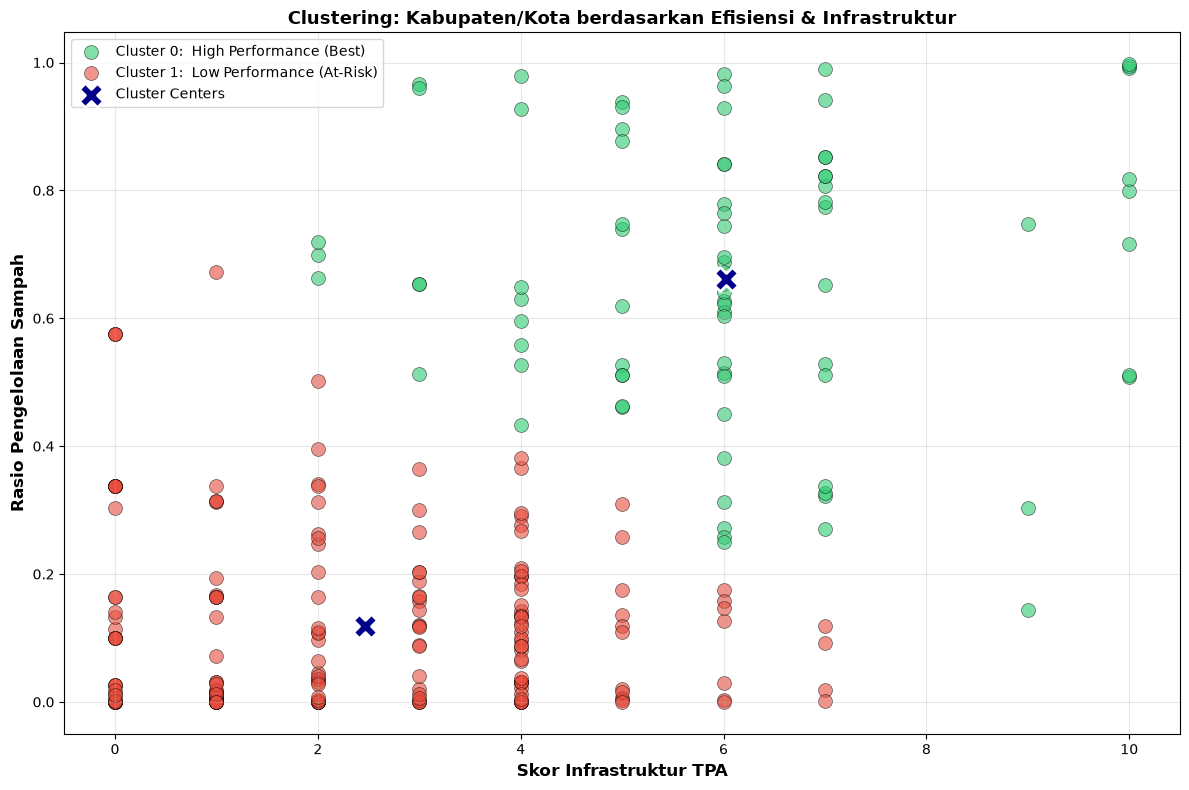

In [ ]:
#  Fit K-Means dengan k optimal 
print(f'\n K-Means Clustering dengan k={optimal_k} ')

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f'\nCluster assignment selesai.')
print(f'\nDistribusi cluster:')
print(X['cluster'].value_counts().sort_index())

#  Tambah cluster ke df_cluster 
df_cluster['cluster'] = X['cluster'].values

#  Analisis karakteristik cluster 
print(f'\n Karakteristik Cluster \n')

cluster_profiles = []
for cluster_id in sorted(X['cluster'].unique()):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    
    profile = {
        'Cluster': cluster_id,
        'Count': len(cluster_data),
        'Pengelolaan (mean)': cluster_data['rasio_pengelolaan'].mean(),
        'Pengelolaan (std)': cluster_data['rasio_pengelolaan'].std(),
        'Infrastruktur (mean)': cluster_data['skor_infrastruktur'].mean(),
        'Infrastruktur (std)': cluster_data['skor_infrastruktur'].std(),
        'Pengurangan (mean)': cluster_data['rasio_pengurangan'].mean(),
        'Penanganan (mean)': cluster_data['rasio_penanganan'].mean(),
        'Recycling Rate (mean)': cluster_data['recycling_rate'].mean(),
    }
    cluster_profiles.append(profile)
    
    print(f'CLUSTER {cluster_id} ({len(cluster_data)} regions):')
    print(f'  • Efisiensi pengelolaan: {profile["Pengelolaan (mean)"]:.1%} (±{profile["Pengelolaan (std)"]:.1%})')
    print(f'  • Skor infrastruktur: {profile["Infrastruktur (mean)"]:.1f} (±{profile["Infrastruktur (std)"]:.1f})')
    print(f'  • Pengurangan (3R): {profile["Pengurangan (mean)"]:.1%}')
    print(f'  • Penanganan (TPA): {profile["Penanganan (mean)"]:.1%}')
    print(f'  • Recycling rate: {profile["Recycling Rate (mean)"]:.1%}')
    print()

cluster_df = pd.DataFrame(cluster_profiles)

#  Cluster naming berdasarkan karakteristik 
print(' Cluster Labeling ')

# Tentukan cluster labels berdasarkan posisi di scatter plot
for idx, row in cluster_df.iterrows():
    perf = row['Pengelolaan (mean)']
    infra = row['Infrastruktur (mean)']
    
    if perf >= cluster_df['Pengelolaan (mean)'].quantile(0.66) and \
       infra >= cluster_df['Infrastruktur (mean)'].quantile(0.66):
        label = ' High Performance (Best)'
        color = 'green'
    elif perf < cluster_df['Pengelolaan (mean)'].quantile(0.33) and \
         infra < cluster_df['Infrastruktur (mean)'].quantile(0.33):
        label = ' Low Performance (At-Risk)'
        color = 'red'
    elif perf >= cluster_df['Pengelolaan (mean)'].quantile(0.66) or \
         infra >= cluster_df['Infrastruktur (mean)'].quantile(0.66):
        label = '📈 Growing/Mixed (Emerging)'
        color = 'orange'
    else:
        label = ' Moderate (Maintenance)'
        color = 'yellow'
    
    cluster_df.loc[idx, 'Label'] = label
    cluster_df.loc[idx, 'Color'] = color
    
    print(f'Cluster {int(row["Cluster"])}: {label}')

#  Visualisasi Scatter Plot dengan Cluster 
fig, ax = plt.subplots(figsize=(12, 8))

colors_map = {'green': '#2ecc71', 'orange': '#f39c12', 'yellow': '#f1c40f', 'red': '#e74c3c'}

for cluster_id in sorted(df_cluster['cluster'].unique()):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    color_label = cluster_df[cluster_df['Cluster'] == cluster_id]['Color'].iloc[0]
    label = cluster_df[cluster_df['Cluster'] == cluster_id]['Label'].iloc[0]
    
    ax.scatter(
        cluster_data['skor_infrastruktur'],
        cluster_data['rasio_pengelolaan'],
        c=colors_map[color_label],
        s=100,
        alpha=0.6,
        label=f'Cluster {cluster_id}: {label}',
        edgecolors='black',
        linewidth=0.5
    )

# Tambah cluster centers yang di-denormalisasi
centers = scaler.inverse_transform(kmeans_final.cluster_centers_)
ax.scatter(
    centers[:, 1],  # infrastruktur (index 1 di features)
    centers[:, 0],  # pengelolaan (index 0 di features)
    c='darkblue',
    s=300,
    marker='X',
    edgecolors='white',
    linewidth=2,
    label='Cluster Centers',
    zorder=5
)

ax.set_xlabel('Skor Infrastruktur TPA', fontsize=12, fontweight='bold')
ax.set_ylabel('Rasio Pengelolaan Sampah', fontsize=12, fontweight='bold')
ax.set_title('Clustering: Kabupaten/Kota berdasarkan Efisiensi & Infrastruktur', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# --- Regional membership per cluster ---
print('\n--- CLUSTER MEMBERSHIP: Kabupaten/Kota per Cluster ---\n')

for cluster_id in sorted(df_cluster['cluster'].unique()):
    cluster_regions = df_cluster[df_cluster['cluster'] == cluster_id][
        ['Provinsi', 'Kabupaten/Kota', 'rasio_pengelolaan', 'skor_infrastruktur']
    ].drop_duplicates(subset=['Provinsi', 'Kabupaten/Kota']).sort_values('rasio_pengelolaan', ascending=False)
    
    label = cluster_df[cluster_df['Cluster'] == cluster_id]['Label'].iloc[0]
    print(f'CLUSTER {cluster_id}: {label}')
    print(f'Total: {len(cluster_regions)} regions\n')
    
    # Tampilkan top 10 dan bottom 3
    print('TOP 10 PERFORMERS dalam cluster ini:')
    for idx, (_, row) in enumerate(cluster_regions.head(10).iterrows(), 1):
        print(f'  {idx:>2}. {row["Kabupaten/Kota"]} ({row["Provinsi"]}) - Pengelolaan: {row["rasio_pengelolaan"]:.1%}, Infra: {row["skor_infrastruktur"]:.0f}')
    
    if len(cluster_regions) > 10:
        print(f'\n... dan {len(cluster_regions) - 10} regions lainnya')

# --- Transisi recommendations per cluster ---
print('STRATEGIC RECOMMENDATIONS BY CLUSTER')

for cluster_id in sorted(cluster_df['Cluster'].values):
    cluster_info = cluster_df[cluster_df['Cluster'] == cluster_id].iloc[0]
    label = cluster_info['Label']
    
    perf = cluster_info['Pengelolaan (mean)']
    infra = cluster_info['Infrastruktur (mean)']
    
    print(f'\n CLUSTER {int(cluster_id)}: {label}')
    print(f'   Ukuran: {int(cluster_info["Count"])} regions | Efisiensi: {perf:.1%} | Infrastruktur: {infra:.0f}/9')
    
    if perf >= cluster_df['Pengelolaan (mean)'].quantile(0.66):
        print(f'\n   STATUS: Cluster dengan performa TINGGI')
        print(f'   STRATEGY:')
        print(f'   • Share best practices ke cluster lain → knowledge transfer')
        print(f'   • Target: Pertahankan & tingkatkan dari {perf:.1%} ke >60%')
        print(f'   • Fokus: 3R expansion, recycling rate improvement')
        print(f'   • Timeline: Maintain momentum (quarterly reviews)')
    
    elif perf >= cluster_df['Pengelolaan (mean)'].quantile(0.33):
        if infra >= cluster_df['Infrastruktur (mean)'].quantile(0.5):
            print(f'\n   STATUS: Cluster dengan infrastruktur BAIK tapi performa SEDANG')
            print(f'   ROOT CAUSE: Infrastruktur ada tapi manajemen/operasi kurang optimal')
            print(f'   STRATEGY:')
            print(f'   • Operational excellence program → optimize existing infrastructure')
            print(f'   • Staff training & capacity building')
            print(f'   • Target: Naikkan performa dari {perf:.1%} ke 50%+ dalam 12 bulan')
            print(f'   • Timeline: Quick wins (3-6 bulan), medium-term optimization (6-12 bulan)')
        else:
            print(f'\n   STATUS: Cluster dengan infrastruktur LEMAH & performa SEDANG')
            print(f'   BOTTLENECK: Baik infrastruktur maupun manajemen perlu improvement')
            print(f'   STRATEGY:')
            print(f'   • Phased infrastructure upgrade + concurrent management training')
            print(f'   • Prioritize: Drainase, jembatan timbang, penutupan sampah')
            print(f'   • Target: Performa {perf:.1%} → 40%+ dalam 18 bulan')
            print(f'   • Timeline: Phase 1 (0-6mo): Feasibility studies & design | Phase 2 (6-18mo): Implementation')
    
    else:
        print(f'\n   STATUS: Cluster dengan performa RENDAH → AT-RISK')
        if infra >= cluster_df['Infrastruktur (mean)'].quantile(0.5):
            print(f'   ROOT CAUSE: Infrastruktur ada tapi severely mismanaged')
            print(f'   URGENCY: URGENT → Intensive intervention required')
            print(f'   STRATEGY:')
            print(f'   • Emergency management audit & corrective action plan')
            print(f'   • Consider management replacement or outsourcing')
            print(f'   • Target: Quick recovery dari {perf:.1%} ke 25%+ dalam 6 bulan')
            print(f'   • Timeline: Immediate (month 1-2): Assessment & restructuring | Month 3-6: Recovery')
        else:
            print(f'\n   ROOT CAUSE: Both infrastructure AND management weak')
            print(f'   URGENCY: CRITICAL → Comprehensive intervention')
            print(f'   STRATEGY:')
            print(f'   • Full infrastructure overhaul + institutional restructuring')
            print(f'   • Consider regional consolidation or merger')
            print(f'   • Target: Staged recovery from {perf:.1%} to 30%+ over 24 months')
            print(f'   • Timeline: Phase 1 (0-6mo): Infrastructure priority | Phase 2 (6-18mo): Mgmt. strengthening | Phase 3 (18-24mo): Sustainability')


--- CLUSTER MEMBERSHIP: Kabupaten/Kota per Cluster ---

CLUSTER 0:  High Performance (Best)
Total: 73 regions

TOP 10 PERFORMERS dalam cluster ini:
   1. Kota Bontang (Kalimantan Timur) - Pengelolaan: 99.7%, Infra: 10
   2. Kota Balikpapan (Kalimantan Timur) - Pengelolaan: 99.4%, Infra: 10
   3. Kota Surabaya (Jawa Timur) - Pengelolaan: 99.1%, Infra: 10
   4. Kota Malang (Jawa Timur) - Pengelolaan: 99.0%, Infra: 7
   5. Kota Solok (Sumatera Barat) - Pengelolaan: 98.2%, Infra: 6
   6. Kota Palangkaraya (Kalimantan Tengah) - Pengelolaan: 97.9%, Infra: 4
   7. Kab. Badung (Bali) - Pengelolaan: 96.6%, Infra: 3
   8. Kota Medan (Sumatera Utara) - Pengelolaan: 96.3%, Infra: 6
   9. Kota Kendari (Sulawesi Tenggara) - Pengelolaan: 96.0%, Infra: 3
  10. Kota Banjar (Jawa Barat) - Pengelolaan: 94.1%, Infra: 7

... dan 63 regions lainnya
CLUSTER 1:  Low Performance (At-Risk)
Total: 147 regions

TOP 10 PERFORMERS dalam cluster ini:
   1. Kota Banjarmasin (Kalimantan Selatan) - Pengelolaan: 67.3%,

# 9. Deep Dive Diagnosis

Analisis mendalam untuk mengidentifikasi root cause mengapa setiap cluster memiliki performa berbeda.

**Fokus**: 
- Perbedaan karakteristik sistem operasional & infrastruktur antar cluster
- Bottleneck spesifik yang menghambat efisiensi
- Low-hanging fruits untuk quick wins improvement


In [54]:
print('PHASE 3: DEEP DIVE DIAGNOSIS - ROOT CAUSE ANALYSIS')

# --- Merge cluster info kembali ke df_final untuk analisis detail ---
df_analysis = df_final[(df_final['Ada Data SIPSN'] == 1) & (df_final['Ada Data TPA'] == 1)].copy()

# Create cluster mapping dari df_cluster (drop duplicates dulu)
cluster_map = df_cluster[['Provinsi', 'Kabupaten/Kota', 'cluster']].drop_duplicates(subset=['Provinsi', 'Kabupaten/Kota'])
cluster_map = cluster_map.set_index(['Provinsi', 'Kabupaten/Kota'])['cluster']

# Merge cluster ke df_analysis
df_analysis = df_analysis.merge(
    cluster_map.reset_index().rename(columns={'cluster': 'cluster_id'}),
    on=['Provinsi', 'Kabupaten/Kota'],
    how='left'
)
df_analysis.rename(columns={'cluster_id': 'cluster'}, inplace=True)

# --- DIAGNOSIS 1: Infrastruktur Component Breakdown ---
print('\nDIAGNOSIS 1: INFRASTRUKTUR COMPONENT BREAKDOWN\n')

for cluster_id in sorted(df_analysis['cluster'].dropna().unique()):
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    
    print(f'\nCluster {int(cluster_id)}:')
    print(f'  Skor Penutupan (0-7):')
    print(f'    - Setiap Hari (7)   : {(cluster_data["skor_penutupan"] == 7).sum()} ({(cluster_data["skor_penutupan"] == 7).sum()/len(cluster_data)*100:.1f}%)')
    print(f'    - 2-3x Seminggu (4) : {(cluster_data["skor_penutupan"] == 4).sum()} ({(cluster_data["skor_penutupan"] == 4).sum()/len(cluster_data)*100:.1f}%)')
    print(f'    - Seminggu 1x (3)   : {(cluster_data["skor_penutupan"] == 3).sum()} ({(cluster_data["skor_penutupan"] == 3).sum()/len(cluster_data)*100:.1f}%)')
    print(f'    - Buruk/Tidak (0-2) : {(cluster_data["skor_penutupan"] <= 2).sum()} ({(cluster_data["skor_penutupan"] <= 2).sum()/len(cluster_data)*100:.1f}%)')
    
    print(f'  Jembatan Timbang:')
    print(f'    - Ada & Berfungsi (2) : {(cluster_data["skor_jembatan"] == 2).sum()} ({(cluster_data["skor_jembatan"] == 2).sum()/len(cluster_data)*100:.1f}%)')
    print(f'    - Ada tapi Rusak (1)  : {(cluster_data["skor_jembatan"] == 1).sum()} ({(cluster_data["skor_jembatan"] == 1).sum()/len(cluster_data)*100:.1f}%)')
    print(f'    - Tidak Ada (0)       : {(cluster_data["skor_jembatan"] == 0).sum()} ({(cluster_data["skor_jembatan"] == 0).sum()/len(cluster_data)*100:.1f}%)')
    
    print(f'  Drainase:')
    print(f'    - Ada (1)   : {(cluster_data["skor_drainase"] == 1).sum()} ({(cluster_data["skor_drainase"] == 1).sum()/len(cluster_data)*100:.1f}%)')
    print(f'    - Tidak (0) : {(cluster_data["skor_drainase"] == 0).sum()} ({(cluster_data["skor_drainase"] == 0).sum()/len(cluster_data)*100:.1f}%)')

# --- DIAGNOSIS 2: System Operasional Comparison ---
print('\n\nDIAGNOSIS 2: SISTEM OPERASIONAL COMPARISON\n')

for cluster_id in sorted(df_analysis['cluster'].dropna().unique()):
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    
    print(f'\nCluster {int(cluster_id)}:')
    
    # Sistem operasional
    sanitary_pct = (cluster_data['Sistem Operasional_Sanitary Landfill'] == 1).sum() / len(cluster_data) * 100
    open_dump_pct = (cluster_data['Sistem Operasional_Open Dumping'] == 1).sum() / len(cluster_data) * 100
    lainnya_pct = 100 - sanitary_pct - open_dump_pct
    
    print(f'  Sistem Operasional:')
    print(f'    - Sanitary Landfill: {sanitary_pct:.1f}%')
    print(f'    - Open Dumping     : {open_dump_pct:.1f}%')
    print(f'    - Lainnya          : {lainnya_pct:.1f}%')
    
    # Jenis fasilitas
    print(f'  Distribusi Jenis Fasilitas:')
    for col in facility_cols:
        jenis_name = col.replace('Jenis_', '')
        pct = (cluster_data[col] == 1).sum() / len(cluster_data) * 100
        if pct > 0:
            print(f'    - {jenis_name}: {pct:.1f}%')

# --- DIAGNOSIS 3: Pengelola Performance & Capacity ---
print('\n\n DIAGNOSIS 3: PENGELOLA PERFORMANCE & CAPACITY\n')

for cluster_id in sorted(df_analysis['cluster'].dropna().unique()):
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    
    print(f'\nCluster {int(cluster_id)}:')
    
    # Pengelola breakdown
    print(f'  Pengelola Distribution:')
    for col in operator_cols:
        pengelola_name = col.replace('Pengelola_', '')
        count = (cluster_data[col] == 1).sum()
        pct = count / len(cluster_data) * 100
        if count > 0:
            avg_perf = cluster_data[cluster_data[col] == 1]['rasio_pengelolaan'].mean()
            print(f'    - {pengelola_name}: {count} facilities ({pct:.1f}%) → Avg performa: {avg_perf:.1%}')

# --- DIAGNOSIS 4: 3R Infrastructure vs Performance ---
print('\n\n DIAGNOSIS 4: 3R INFRASTRUCTURE (Pengurangan) BOTTLENECK\n')

for cluster_id in sorted(df_analysis['cluster'].dropna().unique()):
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    
    print(f'\nCluster {int(cluster_id)}:')
    
    pengurangan_mean = cluster_data['rasio_pengurangan'].mean()
    penanganan_mean = cluster_data['rasio_penanganan'].mean()
    total = pengurangan_mean + penanganan_mean
    
    if total > 0:
        pengurangan_pct = pengurangan_mean / total * 100
        penanganan_pct = penanganan_mean / total * 100
    else:
        pengurangan_pct = penanganan_pct = 0
    
    print(f'  Komposisi pengelolaan sampah:')
    print(f'    - Pengurangan (3R) : {pengurangan_mean:.1%} ({pengurangan_pct:.0f}% dari total pengelolaan)')
    print(f'    - Penanganan (TPA) : {penanganan_mean:.1%} ({penanganan_pct:.0f}% dari total pengelolaan)')
    
    if pengurangan_pct < 10:
        print(f'      BOTTLENECK: 3R infrastructure sangat lemah')
        print(f'      → Quick win: Fokus pada bank sampah, komposting, daur ulang')
        print(f'      → Potential improvement: 3R dari {pengurangan_mean:.1%} → {pengurangan_mean*3:.1%} dalam 12 bulan')
    elif pengurangan_pct < 30:
        print(f'  MODERATE: 3R infrastructure ada tapi perlu expansion')
    else:
        print(f'  ✓ GOOD: 3R infrastructure sudah well-developed')

# --- DIAGNOSIS 5: TPA Capacity & Efficiency ---
print('\n\n DIAGNOSIS 5: TPA CAPACITY & EFFICIENCY ISSUES\n')

for cluster_id in sorted(df_analysis['cluster'].dropna().unique()):
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    
    print(f'\nCluster {int(cluster_id)}:')
    
    # Load density
    load_density = cluster_data['sampah_per_hektar'].dropna()
    if len(load_density) > 0:
        print(f'  Beban sampah per hektar:')
        print(f'    - Mean: {load_density.mean():.0f} ton/ha/tahun')
        print(f'    - Median: {load_density.median():.0f} ton/ha/tahun')
        high_load = (load_density > 5000).sum()
        if high_load > 0:
            print(f'    - Fasilitas dengan beban TINGGI (>5000 ton/ha): {high_load} ({high_load/len(load_density)*100:.1f}%)')
            print(f'    Capacity strain detected → Landfill saturation risk')
    
    # Proporsi landfill aktif
    landfill_prop = cluster_data['proporsi_landfill_aktif'].dropna()
    if len(landfill_prop) > 0:
        print(f'\n  Proporsi landfill aktif:')
        print(f'    - Mean: {landfill_prop.mean():.1%}')
        small_landfill = (landfill_prop < 0.2).sum()
        if small_landfill > 0:
            print(f'    - Fasilitas dengan landfill <20% lahan: {small_landfill} ({small_landfill/len(landfill_prop)*100:.1f}%)')
            print(f'    → Limited operational space → likely capacity constraints soon')

PHASE 3: DEEP DIVE DIAGNOSIS - ROOT CAUSE ANALYSIS

DIAGNOSIS 1: INFRASTRUKTUR COMPONENT BREAKDOWN


Cluster 0:
  Skor Penutupan (0-7):
    - Setiap Hari (7)   : 11 (13.6%)
    - 2-3x Seminggu (4) : 26 (32.1%)
    - Seminggu 1x (3)   : 31 (38.3%)
    - Buruk/Tidak (0-2) : 13 (16.0%)
  Jembatan Timbang:
    - Ada & Berfungsi (2) : 56 (69.1%)
    - Ada tapi Rusak (1)  : 7 (8.6%)
    - Tidak Ada (0)       : 16 (19.8%)
  Drainase:
    - Ada (1)   : 75 (92.6%)
    - Tidak (0) : 6 (7.4%)

Cluster 1:
  Skor Penutupan (0-7):
    - Setiap Hari (7)   : 0 (0.0%)
    - 2-3x Seminggu (4) : 9 (4.8%)
    - Seminggu 1x (3)   : 25 (13.4%)
    - Buruk/Tidak (0-2) : 145 (77.5%)
  Jembatan Timbang:
    - Ada & Berfungsi (2) : 53 (28.3%)
    - Ada tapi Rusak (1)  : 19 (10.2%)
    - Tidak Ada (0)       : 109 (58.3%)
  Drainase:
    - Ada (1)   : 120 (64.2%)
    - Tidak (0) : 67 (35.8%)


DIAGNOSIS 2: SISTEM OPERASIONAL COMPARISON


Cluster 0:
  Sistem Operasional:
    - Sanitary Landfill: 13.6%
    - Open D

# 10. Visualisasi Geospasial & Indeks Ketimpangan Layanan Persampahan (IKLP)

Tahap ini membangun **Indeks Ketimpangan Layanan Persampahan (IKLP)** sebagai metode skoring komposit untuk menjawab tiga pertanyaan analitik utama:
1. Bagaimana distribusi ketimpangan layanan persampahan antar kabupaten/kota berdasarkan rasio timbulan sampah terhadap kapasitas pengelolaan yang tersedia?
2. Bagaimana pola spasial ketimpangan layanan persampahan dan daerah mana yang paling tertinggal?
3. Kabupaten/kota mana yang harus diprioritaskan untuk penambahan atau peningkatan fasilitas persampahan?

**Metode yang dipilih:** indeks komposit berbobot + visualisasi geospasial choropleth.

**Alasan pemilihan metode:**
- Pertanyaan analitik membutuhkan ranking prioritas, bukan prediksi individual; karena itu indeks komposit lebih sesuai daripada model prediktif supervised.
- IKLP mengubah beberapa indikator layanan menjadi satu skor 0-1 yang mudah dibandingkan antar kabupaten/kota.
- Choropleth dipakai karena pertanyaan kedua berfokus pada pola spasial ketimpangan.

**Variabel input dan perannya:**
- `rasio_pengelolaan`: indikator utama kapasitas/hasil pengelolaan terhadap timbulan; semakin rendah nilainya, semakin tinggi ketimpangan.
- `skor_infrastruktur`: indikator kesiapan fasilitas TPA; dinormalisasi ke 0-1 dengan pembagi 9.
- `rasio_pengurangan`: indikator kapasitas pengurangan/3R; rendahnya 3R meningkatkan tekanan ke TPA.

**Formula IKLP:**
```
IKLP = 0.4 × (1 − rasio_pengelolaan) + 0.3 × (1 − skor_infrastruktur/9) + 0.3 × (1 − rasio_pengurangan)
```
Skor IKLP berkisar **0–1**, dimana **skor tinggi = ketimpangan tinggi** dan daerah makin prioritas untuk intervensi.

**Output analisis:** statistik distribusi IKLP, kategori ketimpangan, peta choropleth, ranking daerah tertinggal, dan daftar prioritas intervensi.

**Evaluasi metode:** IKLP dievaluasi melalui cakupan data, distribusi kategori, korelasi arah dengan variabel pembentuk, kecocokan pola pada peta, dan kemampuan menghasilkan ranking prioritas yang dapat ditindaklanjuti.

**Keterbatasan model:** bobot 0.4/0.3/0.3 berbasis judgement analitik dan perlu validasi sensitivitas; data bersifat snapshot 2025; missing value diisi konservatif sebagai 0 pada komponen tertentu; IKLP mengukur ketimpangan relatif, bukan hubungan sebab-akibat.


In [ ]:
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# --- Reload datasets ---
df_final = pd.read_csv('Dataset/final_waste_management.csv')
df_map = gpd.read_file('Dataset/gadm41_IDN_2.json')

# Global matplotlib style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

# --- Aggregate to kabupaten/kota level (beberapa kab/kota punya >1 TPA) ---
agg_dict = {
    'rasio_pengelolaan': 'mean',
    'rasio_pengurangan': 'mean',
    'rasio_penanganan': 'mean',
    'recycling_rate': 'mean',
    'skor_infrastruktur': 'mean',
    'skor_penutupan': 'mean',
    'skor_jembatan': 'mean',
    'skor_drainase': 'mean',
    'utilisasi_tpa': 'mean',
    'efisiensi_landfill': 'mean',
    'usia_operasi_tpa': 'mean',
    'sampah_per_hektar': 'mean',
    'Ada Data SIPSN': 'max',
    'Ada Data TPA': 'max',
}

# Tambahkan kolom OHE
for col in df_final.columns:
    if col.startswith(('Jenis_', 'Pengelola_', 'Sistem Operasional_')):
        agg_dict[col] = 'max'

df_agg = df_final.groupby(['Provinsi', 'Kabupaten/Kota']).agg(agg_dict).reset_index()

print(f'Dataset aggregated: {len(df_agg)} kabupaten/kota unik')

# --- Hitung IKLP ---
df_agg['IKLP'] = (
    0.4 * (1 - df_agg['rasio_pengelolaan'].fillna(0))
    + 0.3 * (1 - df_agg['skor_infrastruktur'].fillna(0) / 9)
    + 0.3 * (1 - df_agg['rasio_pengurangan'].fillna(0))
)

print(f'\nStatistik IKLP:')
print(df_agg['IKLP'].describe().round(3))

# Kategorisasi IKLP
df_agg['kategori_iklp'] = pd.cut(
    df_agg['IKLP'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Baik', 'Sedang', 'Tinggi', 'Sangat Tinggi'],
    include_lowest=True,
)

print('\nDistribusi Kategori IKLP:')
kategori_counts = df_agg['kategori_iklp'].value_counts().sort_index()
print(kategori_counts)

# --- Evaluasi hasil indeks ---
coverage_iklp = df_agg['IKLP'].notna().sum() / len(df_agg) * 100
pct_prioritas = (df_agg['kategori_iklp'].isin(['Tinggi', 'Sangat Tinggi']).sum() / len(df_agg) * 100)
corr_iklp_pengelolaan = df_agg[['IKLP', 'rasio_pengelolaan']].dropna().corr().iloc[0, 1]
corr_iklp_infra = df_agg[['IKLP', 'skor_infrastruktur']].dropna().corr().iloc[0, 1]
corr_iklp_pengurangan = df_agg[['IKLP', 'rasio_pengurangan']].dropna().corr().iloc[0, 1]

print('\nEVALUASI IKLP')
print(f'  • Coverage skor IKLP: {coverage_iklp:.1f}% dari {len(df_agg)} kabupaten/kota dalam dataset')
print(f'  • Share daerah prioritas (Tinggi + Sangat Tinggi): {pct_prioritas:.1f}%')
print(f'  • Korelasi IKLP vs rasio_pengelolaan: {corr_iklp_pengelolaan:.3f} (arah negatif diharapkan)')
print(f'  • Korelasi IKLP vs skor_infrastruktur: {corr_iklp_infra:.3f} (arah negatif diharapkan)')
print(f'  • Korelasi IKLP vs rasio_pengurangan: {corr_iklp_pengurangan:.3f} (arah negatif diharapkan)')
print('  • Interpretasi evaluasi: indeks valid secara arah bila IKLP meningkat saat pengelolaan, infrastruktur, atau pengurangan makin rendah.')
print('  • Kegunaan output: skor dan kategori IKLP dapat langsung dipakai untuk ranking prioritas kabupaten/kota.')

Dataset aggregated: 315 kabupaten/kota unik

Statistik IKLP:
count    315.000
mean       0.797
std        0.177
min        0.266
25%        0.711
50%        0.834
75%        0.933
max        1.000
Name: IKLP, dtype: float64

Distribusi Kategori IKLP:
kategori_iklp
Baik               3
Sedang            27
Tinggi            48
Sangat Tinggi    237
Name: count, dtype: int64


### 10.1 Geospatial Name Matching

In [56]:
def normalize_name(name):
    """Standardisasi nama kabupaten/kota untuk matching."""
    if pd.isna(name):
        return ''
    name = str(name).strip().upper()
    for prefix in ['KABUPATEN ', 'KAB. ', 'KAB ', 'KOTA ADMINISTRASI ', 'KOTA ']:
        if name.startswith(prefix):
            name = name[len(prefix):]
    return name.strip()


def normalize_prov(name):
    """Standardisasi nama provinsi untuk matching."""
    if pd.isna(name):
        return ''
    name = str(name).strip().upper()
    mapping = {
        'JAKARTA RAYA': 'DKI JAKARTA',
        'YOGYAKARTA': 'DI YOGYAKARTA',
        'DAERAH ISTIMEWA YOGYAKARTA': 'DI YOGYAKARTA',
        'NANGGROE ACEH DARUSSALAM': 'ACEH',
        'BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG',
    }
    return mapping.get(name, name)


# Normalisasi nama di kedua dataset
df_map['prov_norm'] = df_map['NAME_1'].apply(normalize_prov)
df_map['kabkota_norm'] = df_map['NAME_2'].apply(normalize_name)

df_agg['prov_norm'] = df_agg['Provinsi'].apply(normalize_prov)
df_agg['kabkota_norm'] = df_agg['Kabupaten/Kota'].apply(normalize_name)

# Merge
geo_merged = df_map.merge(
    df_agg,
    left_on=['prov_norm', 'kabkota_norm'],
    right_on=['prov_norm', 'kabkota_norm'],
    how='left',
)

matched = geo_merged['IKLP'].notna().sum()
total_map = len(df_map)
total_data = len(df_agg)

print(f'Hasil Geospatial Merge:')
print(f'  • Poligon peta (GADM)      : {total_map}')
print(f'  • Kabupaten/kota (data)    : {total_data}')
print(f'  • Berhasil di-match        : {matched} ({matched / total_data * 100:.1f}% dari data)')
print(f'  • Tidak ter-match (peta)   : {total_map - matched}')

Hasil Geospatial Merge:
  • Poligon peta (GADM)      : 502
  • Kabupaten/kota (data)    : 315
  • Berhasil di-match        : 37 (11.7% dari data)
  • Tidak ter-match (peta)   : 465


### 10.2 Choropleth: Rasio Pengelolaan Sampah

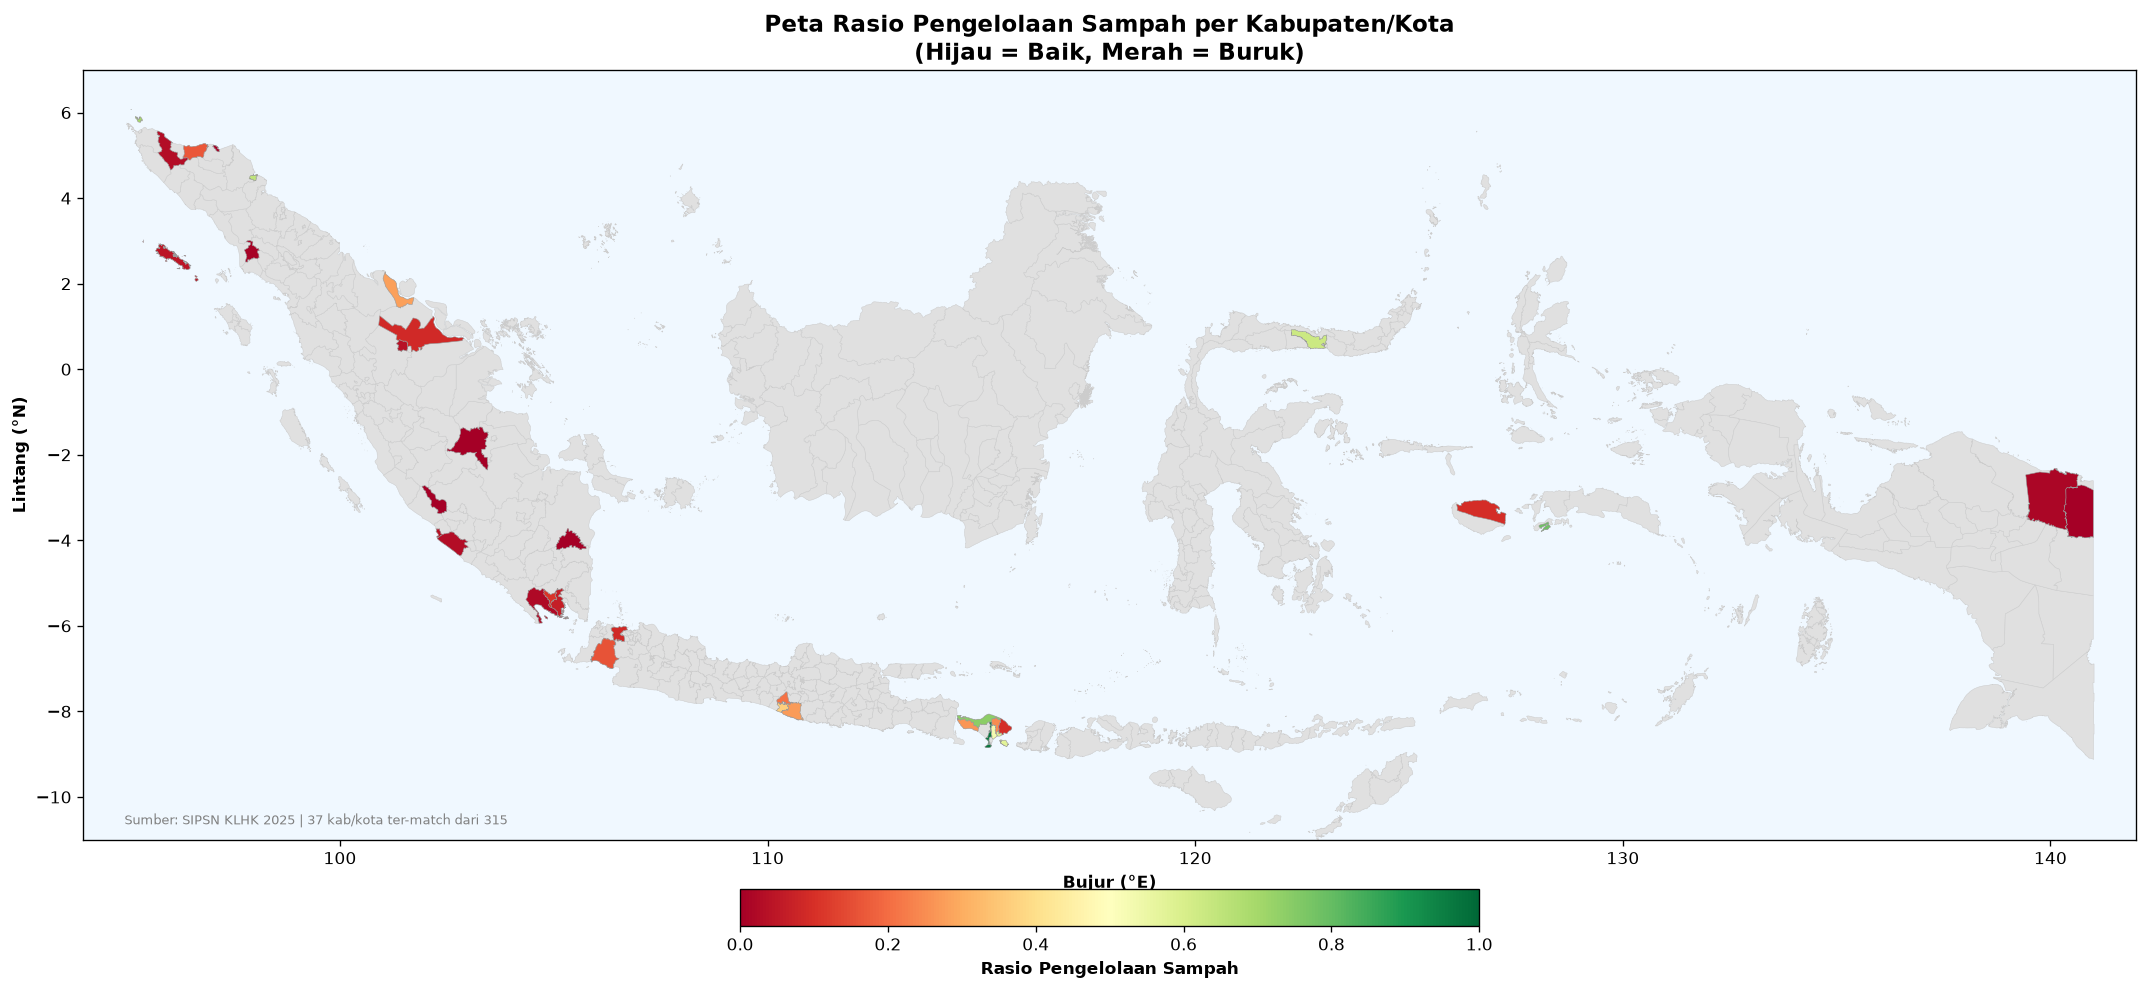

In [57]:
fig, ax = plt.subplots(figsize=(18, 11))

# Plot base map (abu-abu untuk wilayah tanpa data)
geo_merged.plot(ax=ax, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.3)

# Plot wilayah dengan data
mask = geo_merged['rasio_pengelolaan'].notna()
if mask.any():
    geo_merged[mask].plot(
        column='rasio_pengelolaan',
        cmap='RdYlGn',
        legend=True,
        legend_kwds={
            'label': 'Rasio Pengelolaan Sampah',
            'orientation': 'horizontal',
            'fraction': 0.03,
            'pad': 0.04,
            'shrink': 0.6,
        },
        ax=ax,
        edgecolor='#999999',
        linewidth=0.3,
        vmin=0,
        vmax=1,
    )

ax.set_xlim([94, 142])
ax.set_ylim([-11, 7])
ax.set_title(
    'Peta Rasio Pengelolaan Sampah per Kabupaten/Kota\n(Hijau = Baik, Merah = Buruk)',
    fontsize=14,
)
ax.set_xlabel('Bujur (°E)')
ax.set_ylabel('Lintang (°N)')
ax.set_facecolor('#f0f8ff')
ax.text(
    0.02, 0.02,
    f'Sumber: SIPSN KLHK 2025 | {matched} kab/kota ter-match dari {total_data}',
    transform=ax.transAxes, fontsize=8, color='gray',
)
plt.tight_layout()
plt.show()

### 10.3 Choropleth: Skor Infrastruktur TPA

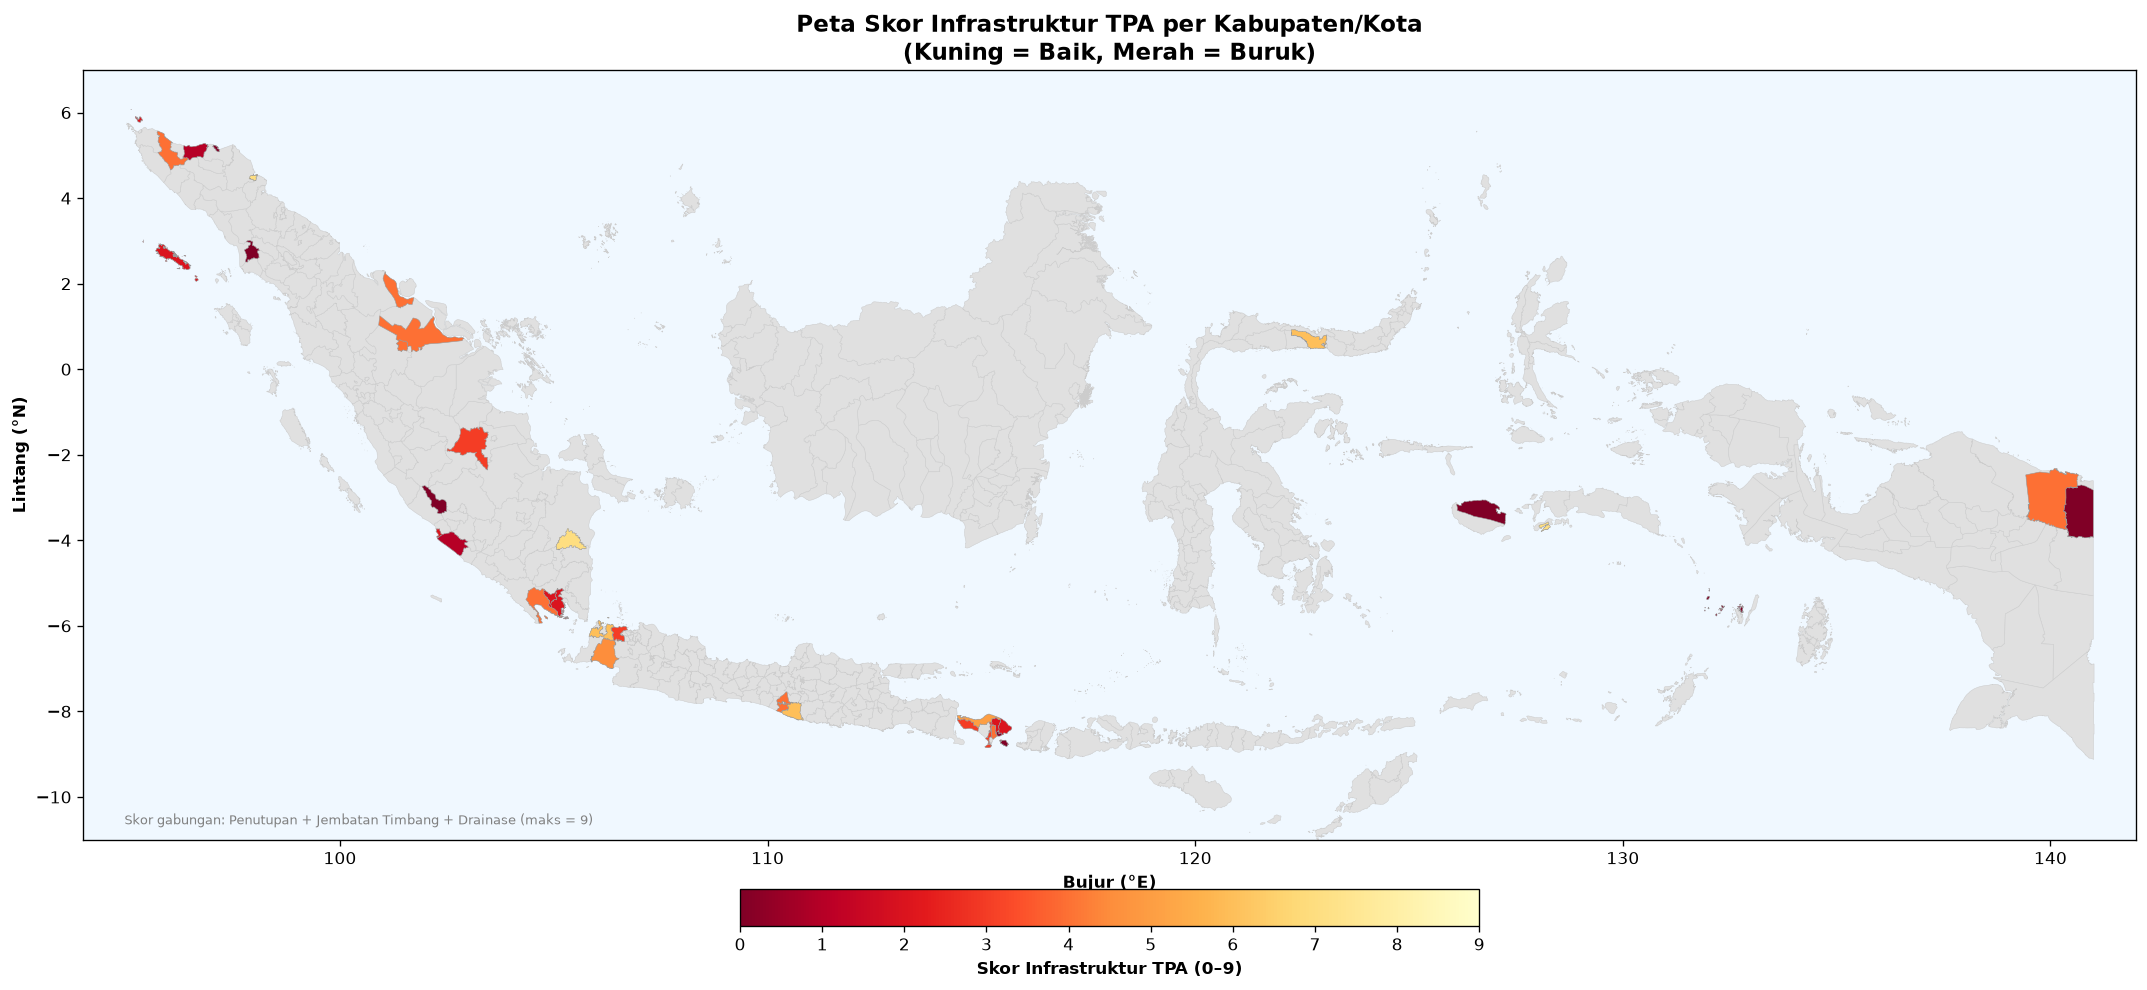

In [58]:
fig, ax = plt.subplots(figsize=(18, 11))

geo_merged.plot(ax=ax, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.3)

mask = geo_merged['skor_infrastruktur'].notna()
if mask.any():
    geo_merged[mask].plot(
        column='skor_infrastruktur',
        cmap='YlOrRd_r',
        legend=True,
        legend_kwds={
            'label': 'Skor Infrastruktur TPA (0–9)',
            'orientation': 'horizontal',
            'fraction': 0.03,
            'pad': 0.04,
            'shrink': 0.6,
        },
        ax=ax,
        edgecolor='#999999',
        linewidth=0.3,
        vmin=0,
        vmax=9,
    )

ax.set_xlim([94, 142])
ax.set_ylim([-11, 7])
ax.set_title(
    'Peta Skor Infrastruktur TPA per Kabupaten/Kota\n(Kuning = Baik, Merah = Buruk)',
    fontsize=14,
)
ax.set_xlabel('Bujur (°E)')
ax.set_ylabel('Lintang (°N)')
ax.set_facecolor('#f0f8ff')
ax.text(
    0.02, 0.02,
    'Skor gabungan: Penutupan + Jembatan Timbang + Drainase (maks = 9)',
    transform=ax.transAxes, fontsize=8, color='gray',
)
plt.tight_layout()
plt.show()

### 10.4 Choropleth: Indeks Ketimpangan Layanan Persampahan (IKLP)

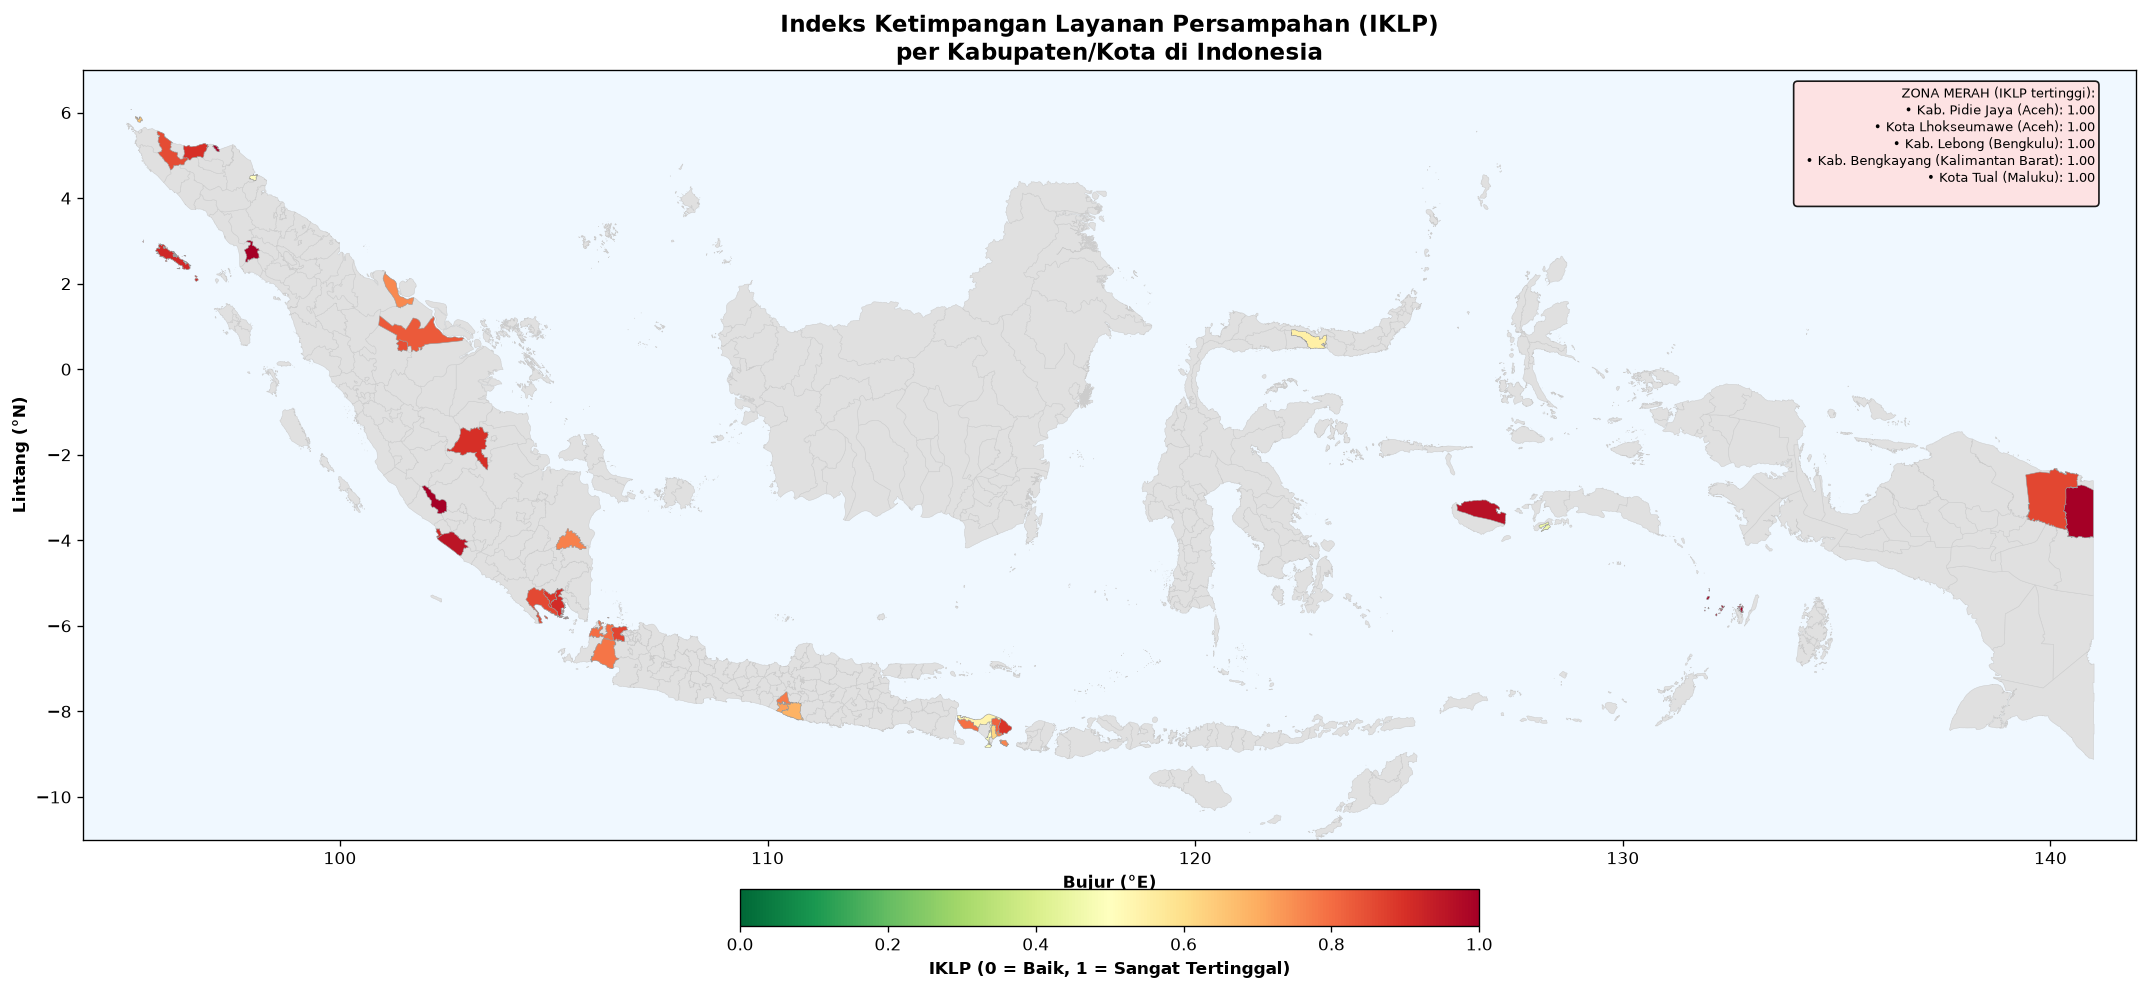

In [59]:
fig, ax = plt.subplots(figsize=(18, 11))

geo_merged.plot(ax=ax, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.3)

mask = geo_merged['IKLP'].notna()
if mask.any():
    geo_merged[mask].plot(
        column='IKLP',
        cmap='RdYlGn_r',
        legend=True,
        legend_kwds={
            'label': 'IKLP (0 = Baik, 1 = Sangat Tertinggal)',
            'orientation': 'horizontal',
            'fraction': 0.03,
            'pad': 0.04,
            'shrink': 0.6,
        },
        ax=ax,
        edgecolor='#999999',
        linewidth=0.3,
        vmin=0,
        vmax=1,
    )

ax.set_xlim([94, 142])
ax.set_ylim([-11, 7])
ax.set_title(
    'Indeks Ketimpangan Layanan Persampahan (IKLP)\nper Kabupaten/Kota di Indonesia',
    fontsize=14,
)
ax.set_xlabel('Bujur (°E)')
ax.set_ylabel('Lintang (°N)')
ax.set_facecolor('#f0f8ff')

# Anotasi 5 daerah paling tertinggal
top_worst = df_agg.nlargest(5, 'IKLP')
annotation = 'ZONA MERAH (IKLP tertinggi):\n'
for _, row in top_worst.iterrows():
    annotation += f"  • {row['Kabupaten/Kota']} ({row['Provinsi']}): {row['IKLP']:.2f}\n"

ax.text(
    0.98, 0.98, annotation,
    transform=ax.transAxes, fontsize=8,
    verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.9),
)

plt.tight_layout()
plt.show()

In [60]:
# --- Ranking IKLP ---
print('=== TOP 10 KABUPATEN/KOTA PALING TERTINGGAL (IKLP TERTINGGI) ===')
for i, (_, row) in enumerate(df_agg.nlargest(10, 'IKLP').iterrows(), 1):
    print(f'  {i:>2}. {row["Kabupaten/Kota"]} ({row["Provinsi"]}) '
          f'— IKLP: {row["IKLP"]:.3f} | Pengelolaan: {row["rasio_pengelolaan"]:.1%}')

print('\n=== TOP 10 KABUPATEN/KOTA TERBAIK (IKLP TERENDAH) ===')
for i, (_, row) in enumerate(df_agg.nsmallest(10, 'IKLP').iterrows(), 1):
    print(f'  {i:>2}. {row["Kabupaten/Kota"]} ({row["Provinsi"]}) '
          f'— IKLP: {row["IKLP"]:.3f} | Pengelolaan: {row["rasio_pengelolaan"]:.1%}')

# --- IKLP per Provinsi ---
iklp_prov = df_agg.groupby('Provinsi')['IKLP'].mean().sort_values()
print('\n=== IKLP RATA-RATA PER PROVINSI (ascending = terbaik) ===')
for i, (prov, val) in enumerate(iklp_prov.items(), 1):
    print(f'  {i:>2}. {prov}: {val:.3f}')

=== TOP 10 KABUPATEN/KOTA PALING TERTINGGAL (IKLP TERTINGGI) ===
   1. Kab. Pidie Jaya (Aceh) — IKLP: 1.000 | Pengelolaan: nan%
   2. Kota Lhokseumawe (Aceh) — IKLP: 1.000 | Pengelolaan: 0.0%
   3. Kab. Lebong (Bengkulu) — IKLP: 1.000 | Pengelolaan: 0.0%
   4. Kab. Bengkayang (Kalimantan Barat) — IKLP: 1.000 | Pengelolaan: 0.0%
   5. Kota Tual (Maluku) — IKLP: 1.000 | Pengelolaan: nan%
   6. Kab. Malaka (Nusa Tenggara Timur) — IKLP: 1.000 | Pengelolaan: 0.0%
   7. Kab. Manggarai Timur (Nusa Tenggara Timur) — IKLP: 1.000 | Pengelolaan: 0.0%
   8. Kab. Sumba Barat (Nusa Tenggara Timur) — IKLP: 1.000 | Pengelolaan: 0.0%
   9. Kab. Timor Tengah Utara (Nusa Tenggara Timur) — IKLP: 1.000 | Pengelolaan: 0.0%
  10. Kab. Keerom (Papua) — IKLP: 1.000 | Pengelolaan: 0.0%

=== TOP 10 KABUPATEN/KOTA TERBAIK (IKLP TERENDAH) ===
   1. Kota Bontang (Kalimantan Timur) — IKLP: 0.266 | Pengelolaan: 99.7%
   2. Kota Balikpapan (Kalimantan Timur) — IKLP: 0.268 | Pengelolaan: 99.4%
   3. Kota Surabaya (Jawa

# 11. Enhanced Cluster & Diagnostic Visualizations

Visualisasi lanjutan untuk mendukung pengambilan keputusan:
- Peta klaster (choropleth)
- Radar chart profil multi-dimensi per klaster
- Komposisi pengelolaan (3R vs TPA)
- Box plot per sistem operasional
- Komponen infrastruktur per klaster
- Heatmap korelasi
- Top/Bottom 15 kabupaten/kota

**Tujuan yang dijawab:**
- Tujuan #4: Mengelompokkan kab/kota ke dalam segmen ketimpangan
- Tujuan #5: Menghasilkan rekomendasi prioritas intervensi berbasis data

In [ ]:
# --- 11.1 Re-run Clustering (konsisten dengan Section 8) ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_cluster_src = df_agg[(df_agg['Ada Data SIPSN'] == 1) & (df_agg['Ada Data TPA'] == 1)].copy()

features_clust = ['rasio_pengelolaan', 'skor_infrastruktur']
X_clust = df_cluster_src[features_clust].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust[features_clust])

# Silhouette-based optimal k
sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

optimal_k = max(sil_scores, key=sil_scores.get)
print(f'Optimal k = {optimal_k} (Silhouette = {sil_scores[optimal_k]:.3f})')

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X_clust['cluster'] = kmeans_model.fit_predict(X_scaled)

df_cluster_src = df_cluster_src.loc[X_clust.index].copy()
df_cluster_src['cluster'] = X_clust['cluster'].values

# Label clusters
cluster_stats = df_cluster_src.groupby('cluster').agg({
    'rasio_pengelolaan': 'mean',
    'skor_infrastruktur': 'mean',
}).round(3)

cluster_labels = {}
cluster_colors_map = {}
palette = {
    'High Performance': '#2ecc71',
    'Moderate': '#f39c12',
    'Low Performance': '#e74c3c',
    'Growing': '#3498db',
}

for c_id in sorted(cluster_stats.index):
    perf = cluster_stats.loc[c_id, 'rasio_pengelolaan']
    infra = cluster_stats.loc[c_id, 'skor_infrastruktur']
    median_perf = cluster_stats['rasio_pengelolaan'].median()
    median_infra = cluster_stats['skor_infrastruktur'].median()

    if perf >= median_perf and infra >= median_infra:
        label = 'High Performance'
    elif perf >= median_perf:
        label = 'Growing'
    elif infra >= median_infra:
        label = 'Moderate'
    else:
        label = 'Low Performance'

    cluster_labels[c_id] = f'Cluster {c_id}: {label}'
    cluster_colors_map[c_id] = palette[label]
    print(f'Cluster {c_id}: {label} (Pengelolaan={perf:.1%}, Infra={infra:.1f})')

df_cluster_src['cluster_label'] = df_cluster_src['cluster'].map(cluster_labels)

Optimal k = 2 (Silhouette = 0.529)
Cluster 0: Low Performance (Pengelolaan=11.1%, Infra=2.8)
Cluster 1: High Performance (Pengelolaan=67.4%, Infra=6.1)


### 11.2 Choropleth: Cluster Membership

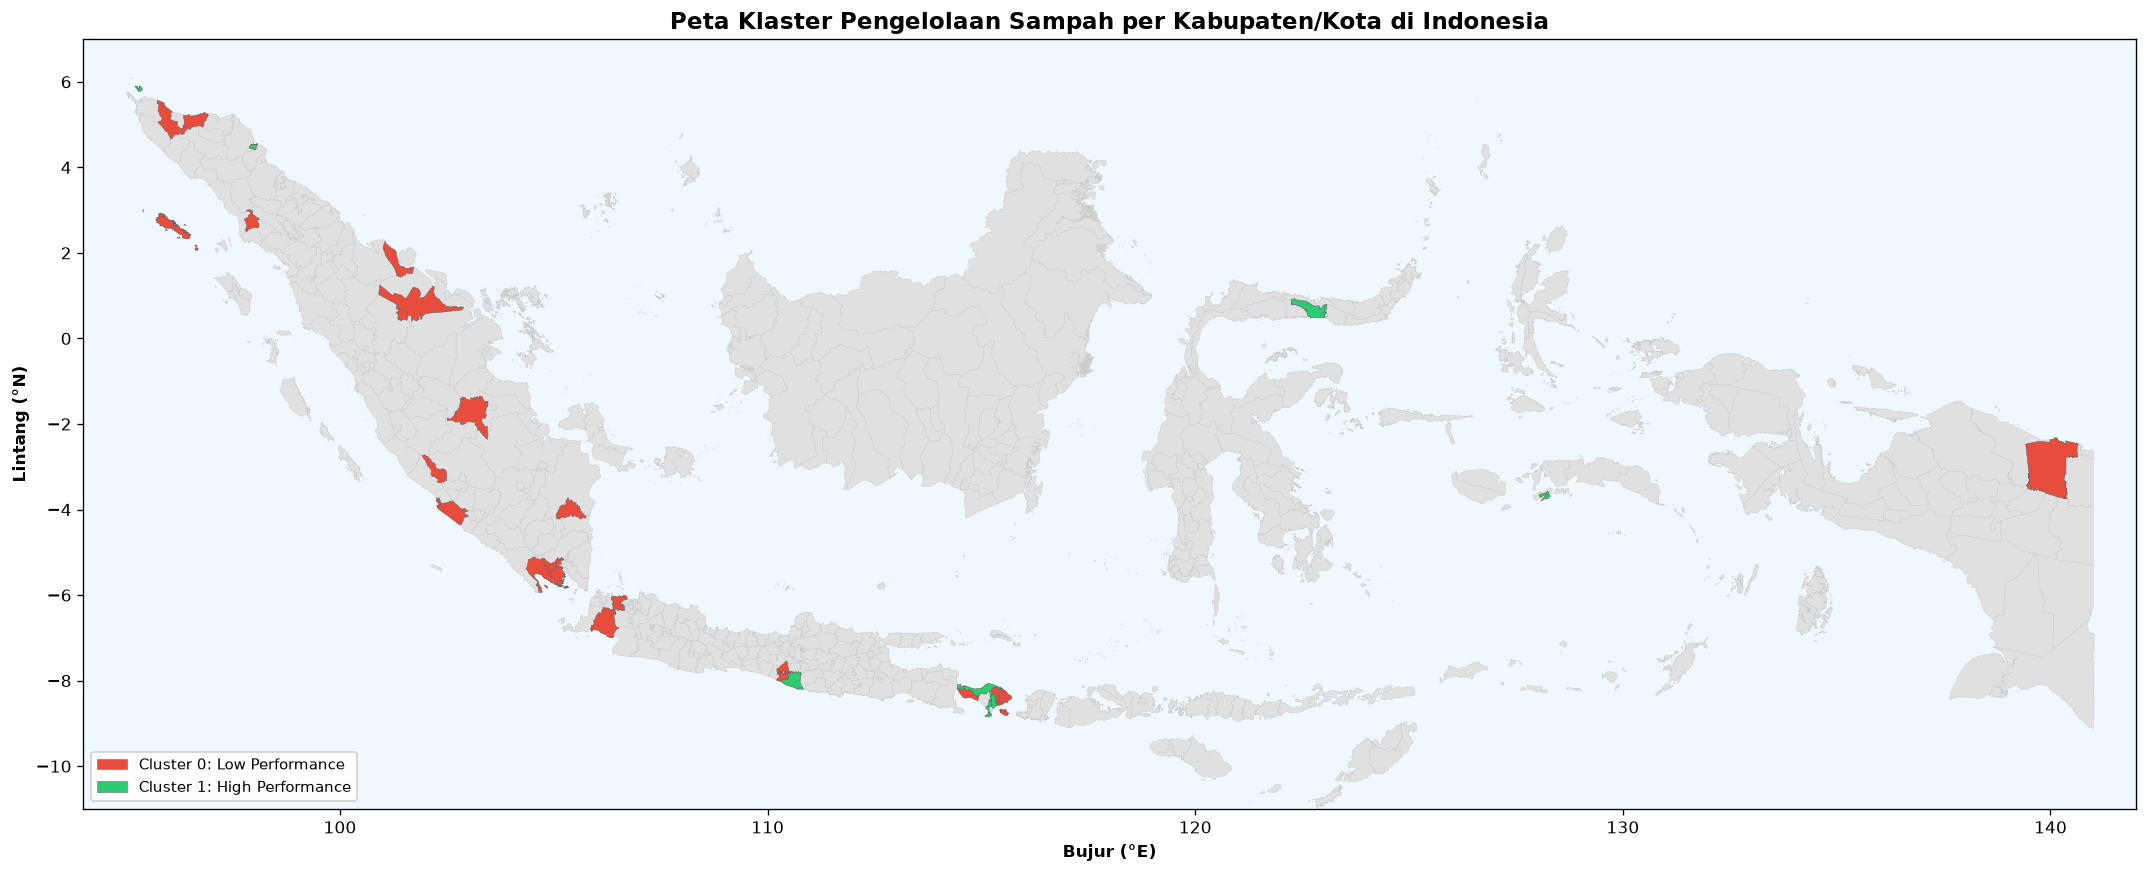

In [62]:
# Merge cluster ke geo_merged
cluster_map_data = df_cluster_src[['Provinsi', 'Kabupaten/Kota', 'cluster']].copy()
cluster_map_data['prov_norm'] = cluster_map_data['Provinsi'].apply(normalize_prov)
cluster_map_data['kabkota_norm'] = cluster_map_data['Kabupaten/Kota'].apply(normalize_name)

geo_cluster = df_map.merge(
    cluster_map_data,
    on=['prov_norm', 'kabkota_norm'],
    how='left',
)

fig, ax = plt.subplots(figsize=(18, 11))

# Base map
geo_cluster.plot(ax=ax, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.3)

# Plot per cluster
for c_id in sorted(df_cluster_src['cluster'].unique()):
    mask = geo_cluster['cluster'] == c_id
    if mask.any():
        geo_cluster[mask].plot(
            ax=ax,
            color=cluster_colors_map[c_id],
            edgecolor='#666666',
            linewidth=0.3,
            label=cluster_labels[c_id],
        )

ax.set_xlim([94, 142])
ax.set_ylim([-11, 7])
ax.set_title(
    'Peta Klaster Pengelolaan Sampah per Kabupaten/Kota di Indonesia',
    fontsize=14,
)
ax.set_xlabel('Bujur (°E)')
ax.set_ylabel('Lintang (°N)')
ax.set_facecolor('#f0f8ff')
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

### 11.3 Radar Chart: Profil Multi-dimensi per Cluster

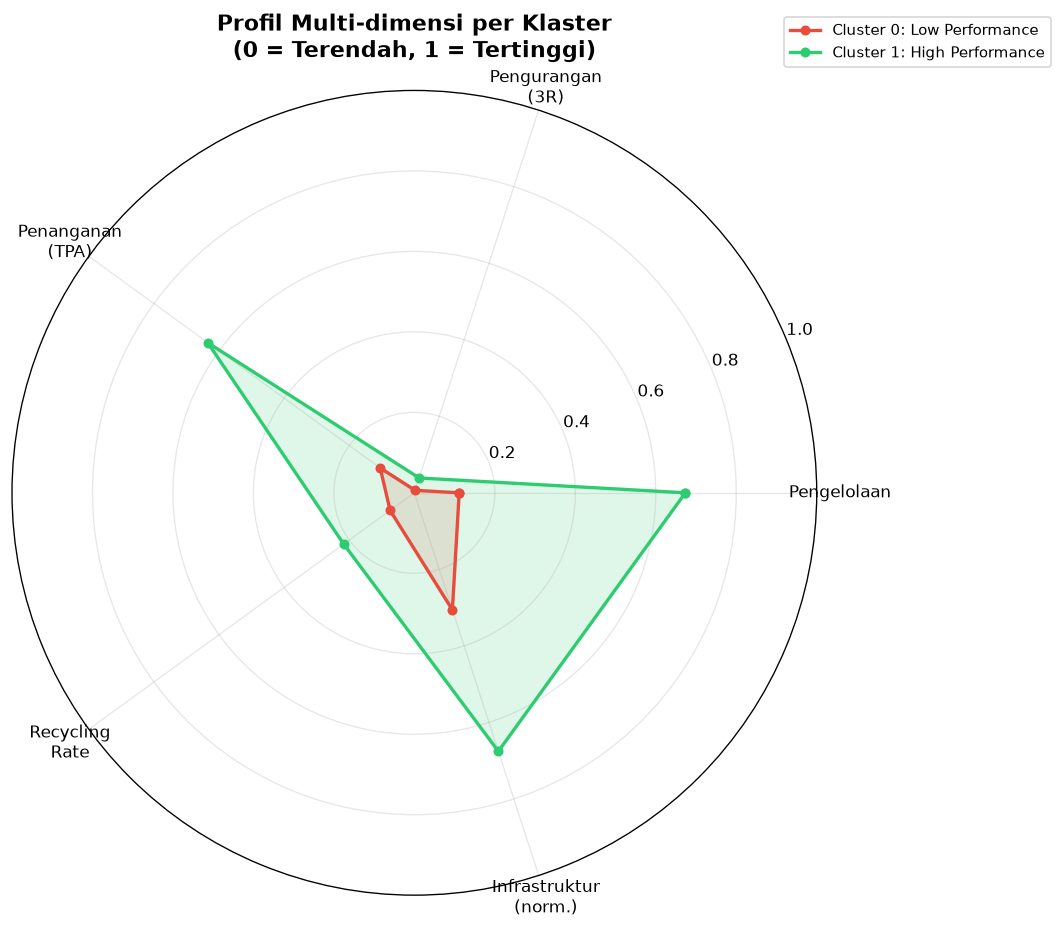

In [63]:
radar_features = [
    'rasio_pengelolaan', 'rasio_pengurangan', 'rasio_penanganan',
    'recycling_rate', 'skor_infrastruktur',
]
radar_labels = [
    'Pengelolaan', 'Pengurangan\n(3R)', 'Penanganan\n(TPA)',
    'Recycling\nRate', 'Infrastruktur\n(norm.)',
]

# Normalisasi skor_infrastruktur ke 0-1 agar sebanding
radar_data = {}
for c_id in sorted(df_cluster_src['cluster'].unique()):
    c_data = df_cluster_src[df_cluster_src['cluster'] == c_id]
    vals = []
    for feat in radar_features:
        v = c_data[feat].mean()
        if feat == 'skor_infrastruktur':
            v = v / 9.0  # Normalize to 0-1
        vals.append(v if not np.isnan(v) else 0)
    radar_data[c_id] = vals

n_features = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for c_id, vals in radar_data.items():
    vals_closed = vals + vals[:1]
    ax.fill(angles, vals_closed, alpha=0.15, color=cluster_colors_map[c_id])
    ax.plot(angles, vals_closed, 'o-', linewidth=2, markersize=5,
            color=cluster_colors_map[c_id], label=cluster_labels[c_id])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels)
ax.set_ylim(0, 1)
ax.set_title('Profil Multi-dimensi per Klaster\n(0 = Terendah, 1 = Tertinggi)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.4 Stacked Bar: Komposisi Pengelolaan Sampah per Cluster

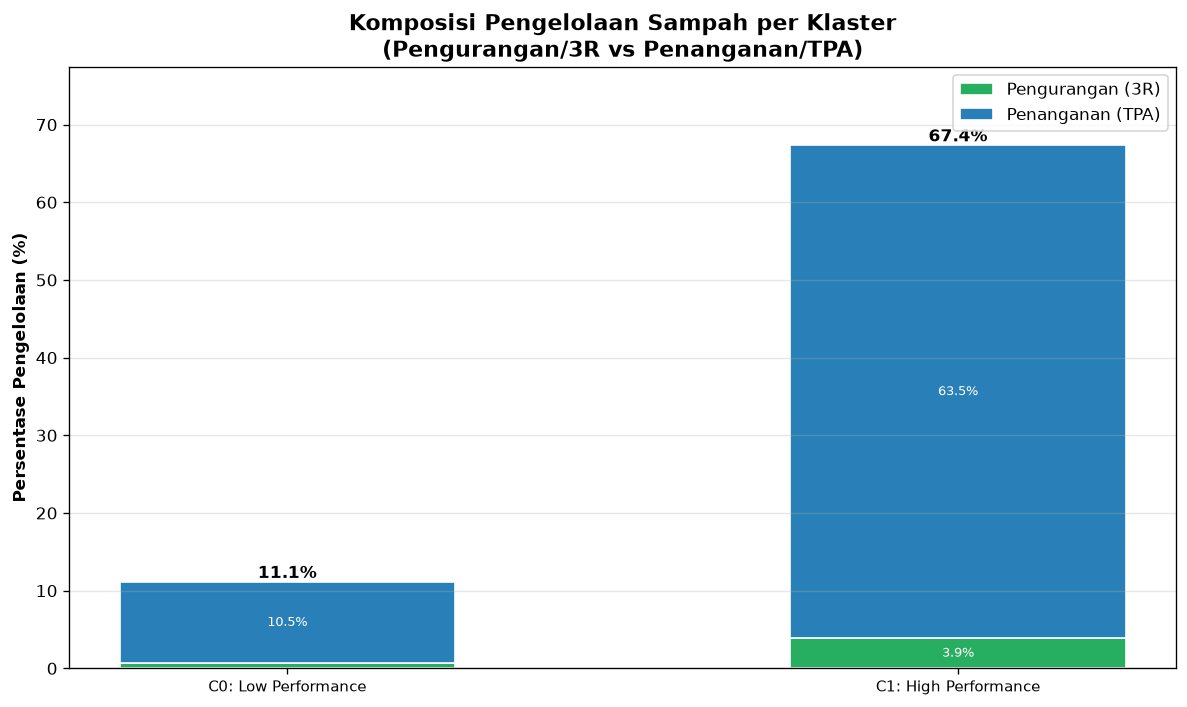

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

cluster_ids = sorted(df_cluster_src['cluster'].unique())
pengurangan_vals = []
penanganan_vals = []
labels_bar = []

for c_id in cluster_ids:
    c_data = df_cluster_src[df_cluster_src['cluster'] == c_id]
    pengurangan_vals.append(c_data['rasio_pengurangan'].mean() * 100)
    penanganan_vals.append(c_data['rasio_penanganan'].mean() * 100)
    labels_bar.append(cluster_labels[c_id])

x_pos = np.arange(len(cluster_ids))
width = 0.5

bars1 = ax.bar(x_pos, pengurangan_vals, width, label='Pengurangan (3R)',
               color='#27ae60', edgecolor='white')
bars2 = ax.bar(x_pos, penanganan_vals, width, bottom=pengurangan_vals,
               label='Penanganan (TPA)', color='#2980b9', edgecolor='white')

# Anotasi
for i, (p, t) in enumerate(zip(pengurangan_vals, penanganan_vals)):
    total = p + t
    ax.text(i, total + 0.5, f'{total:.1f}%', ha='center', fontsize=10, fontweight='bold')
    if p > 1:
        ax.text(i, p / 2, f'{p:.1f}%', ha='center', va='center', fontsize=8, color='white')
    ax.text(i, p + t / 2, f'{t:.1f}%', ha='center', va='center', fontsize=8, color='white')

ax.set_xticks(x_pos)
ax.set_xticklabels([l.replace('Cluster ', 'C') for l in labels_bar], fontsize=9)
ax.set_ylabel('Persentase Pengelolaan (%)')
ax.set_title('Komposisi Pengelolaan Sampah per Klaster\n(Pengurangan/3R vs Penanganan/TPA)', fontsize=13)
ax.legend(loc='upper right')
ax.set_ylim(0, max([p + t for p, t in zip(pengurangan_vals, penanganan_vals)]) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 11.5 Box Plot: Rasio Pengelolaan per Sistem Operasional

/var/folders/91/f899zz6x4731k595sdcfccwc0000gn/T/ipykernel_21120/2198206220.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(


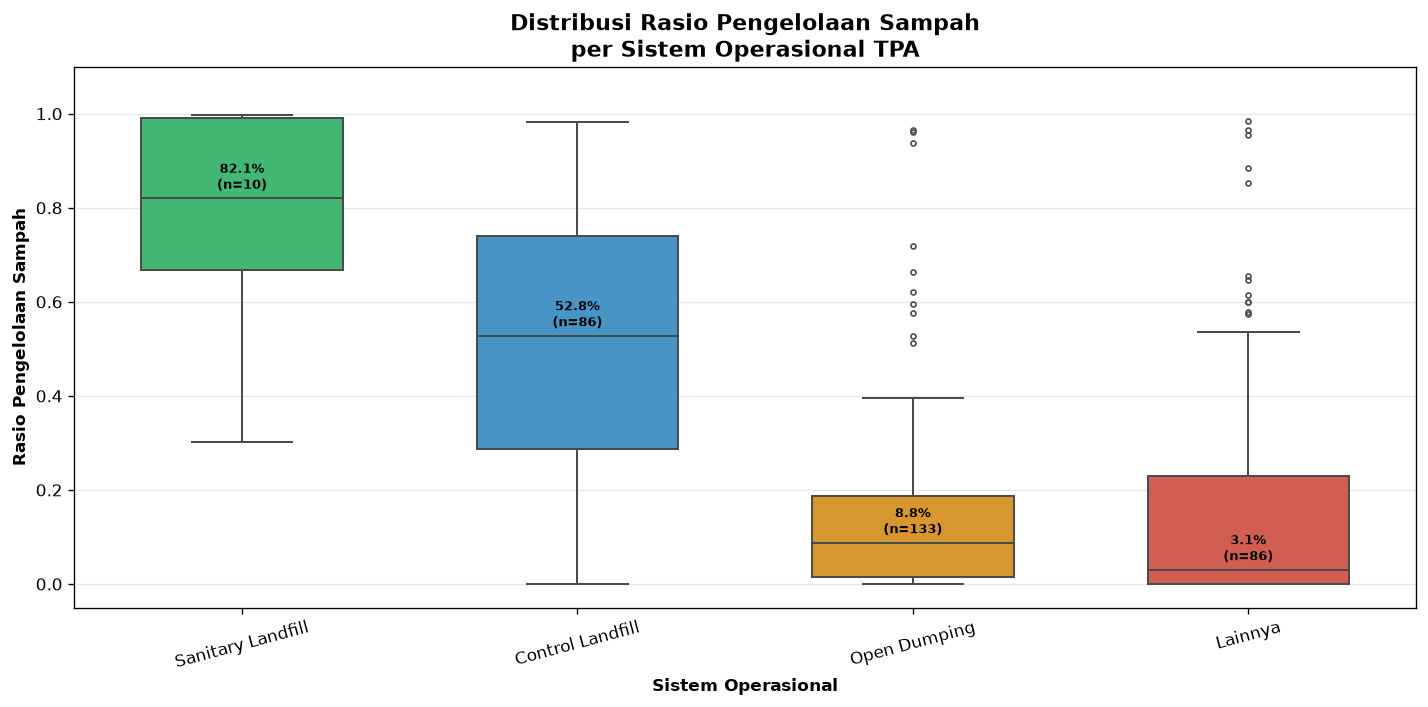

In [65]:
# Identifikasi sistem operasional per baris
system_cols = [c for c in df_agg.columns if c.startswith('Sistem Operasional_')]

df_boxplot = df_agg.copy()
df_boxplot['Sistem'] = 'Lainnya'
for col in system_cols:
    sys_name = col.replace('Sistem Operasional_', '')
    if sys_name not in ['nan', 'Tidak Diketahui']:
        mask = df_boxplot[col] == 1
        df_boxplot.loc[mask, 'Sistem'] = sys_name

# Filter hanya sistem yang bermakna
valid_systems = df_boxplot['Sistem'].value_counts()
valid_systems = valid_systems[valid_systems >= 5].index.tolist()
df_boxplot_filtered = df_boxplot[df_boxplot['Sistem'].isin(valid_systems)]

fig, ax = plt.subplots(figsize=(12, 6))
order = (
    df_boxplot_filtered.groupby('Sistem')['rasio_pengelolaan']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

box_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
bp = sns.boxplot(
    data=df_boxplot_filtered, x='Sistem', y='rasio_pengelolaan',
    order=order, palette=box_colors[:len(order)], ax=ax,
    width=0.6, linewidth=1.2, fliersize=3,
)

# Anotasi median
medians = df_boxplot_filtered.groupby('Sistem')['rasio_pengelolaan'].median()
for i, sys_name in enumerate(order):
    med = medians[sys_name]
    n = (df_boxplot_filtered['Sistem'] == sys_name).sum()
    ax.text(i, med + 0.02, f'{med:.1%}\n(n={n})', ha='center', fontsize=8, fontweight='bold')

ax.set_title('Distribusi Rasio Pengelolaan Sampah\nper Sistem Operasional TPA', fontsize=13)
ax.set_xlabel('Sistem Operasional')
ax.set_ylabel('Rasio Pengelolaan Sampah')
ax.set_ylim(-0.05, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 11.6 Grouped Bar: Komponen Infrastruktur per Cluster

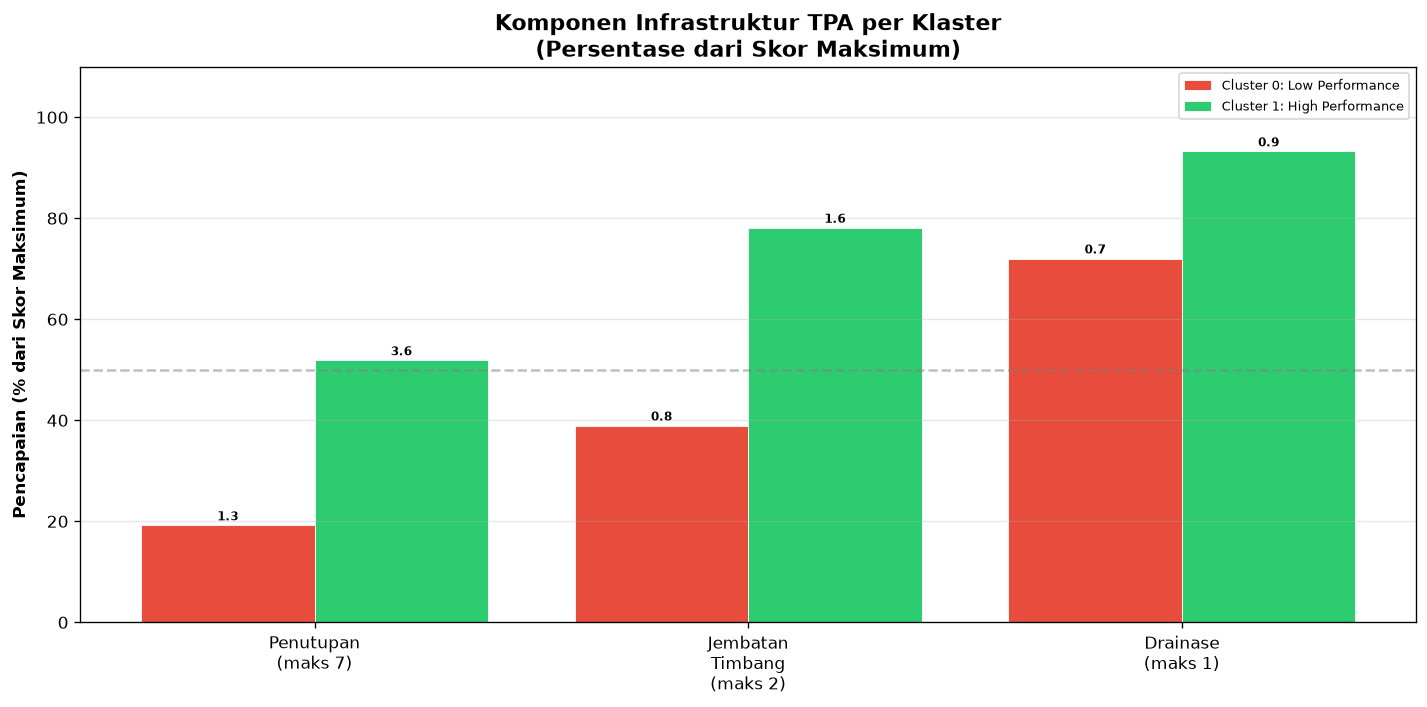

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))

comp_names = ['Penutupan\n(maks 7)', 'Jembatan\nTimbang\n(maks 2)', 'Drainase\n(maks 1)']
comp_cols = ['skor_penutupan', 'skor_jembatan', 'skor_drainase']
comp_max = [7, 2, 1]

x = np.arange(len(comp_names))
n_clusters = len(cluster_ids)
bar_width = 0.8 / n_clusters

for idx, c_id in enumerate(cluster_ids):
    c_data = df_cluster_src[df_cluster_src['cluster'] == c_id]
    # Normalisasi ke persentase dari skor maksimum
    vals_norm = [c_data[col].mean() / mx * 100 for col, mx in zip(comp_cols, comp_max)]
    offset = (idx - n_clusters / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals_norm, bar_width,
                  color=cluster_colors_map[c_id],
                  label=cluster_labels[c_id],
                  edgecolor='white', linewidth=0.5)
    # Anotasi nilai asli
    for j, (bar, col) in enumerate(zip(bars, comp_cols)):
        raw_val = c_data[col].mean()
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{raw_val:.1f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(comp_names, fontsize=10)
ax.set_ylabel('Pencapaian (% dari Skor Maksimum)')
ax.set_title('Komponen Infrastruktur TPA per Klaster\n(Persentase dari Skor Maksimum)', fontsize=13)
ax.legend(fontsize=8)
ax.set_ylim(0, 110)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Threshold 50%')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 11.7 Heatmap: Korelasi Fitur Engineered dengan Rasio Pengelolaan

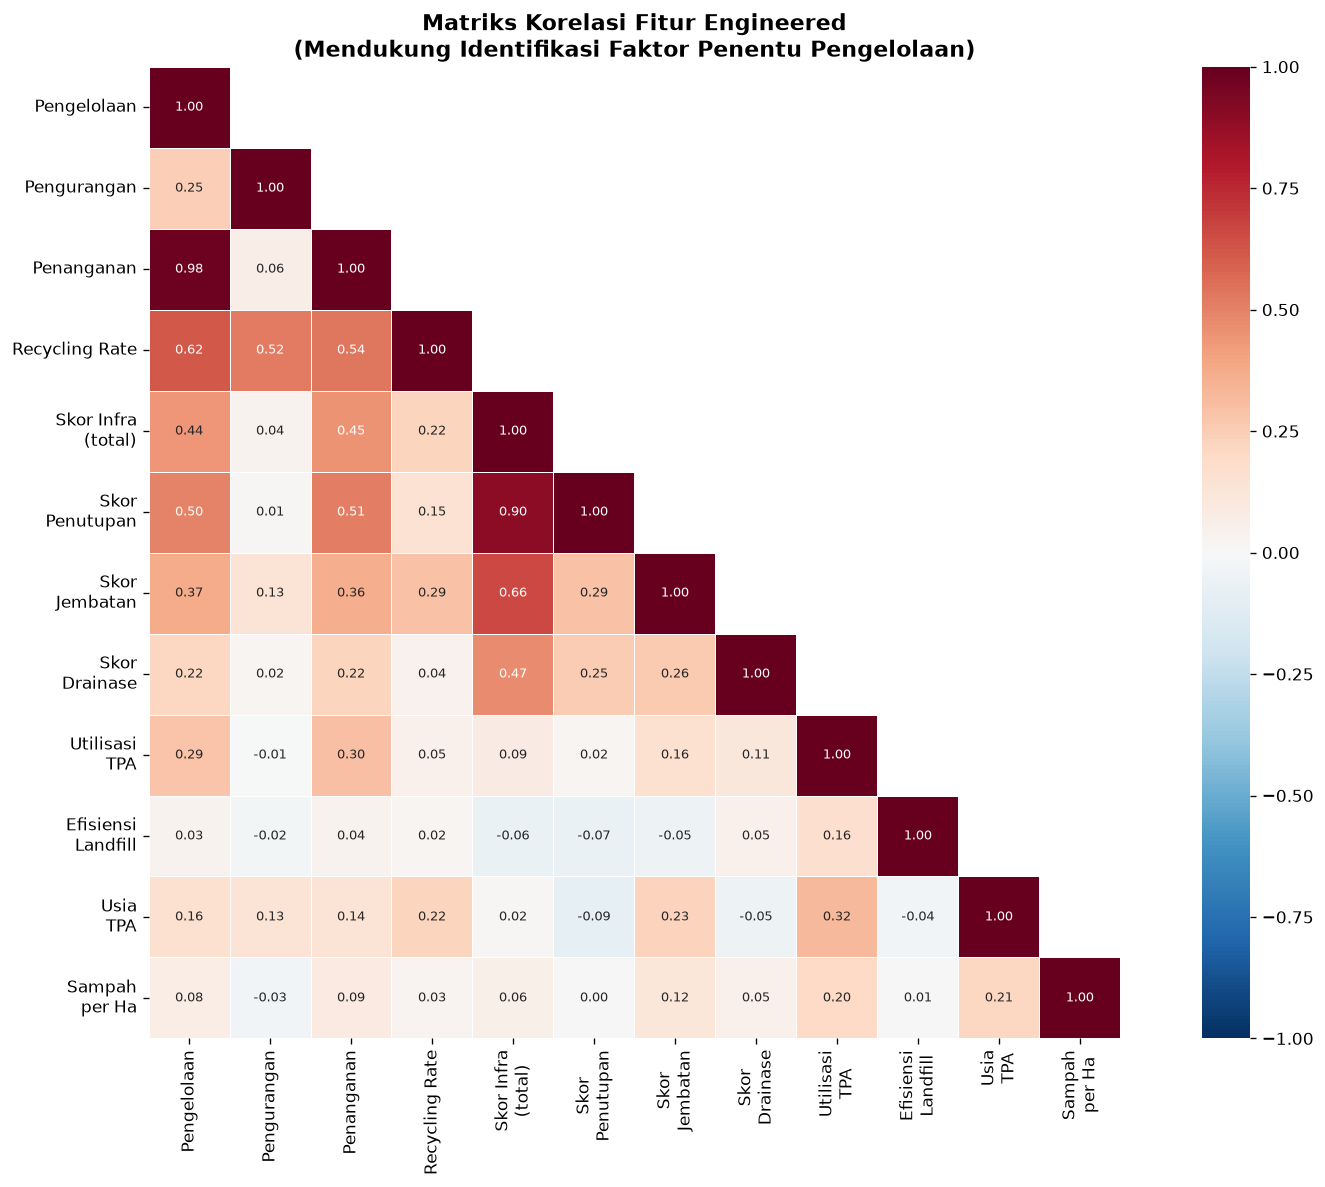

KORELASI DENGAN RASIO PENGELOLAAN
  • rasio_penanganan: r = 0.983 (KUAT)
  • recycling_rate: r = 0.619 (KUAT)
  • skor_penutupan: r = 0.498 (SEDANG)
  • skor_infrastruktur: r = 0.444 (SEDANG)
  • skor_jembatan: r = 0.375 (SEDANG)
  • utilisasi_tpa: r = 0.286 (LEMAH)
  • rasio_pengurangan: r = 0.246 (LEMAH)
  • skor_drainase: r = 0.216 (LEMAH)
  • usia_operasi_tpa: r = 0.160 (LEMAH)
  • sampah_per_hektar: r = 0.077 (LEMAH)
  • efisiensi_landfill: r = 0.033 (LEMAH)


In [76]:
corr_features = [
    'rasio_pengelolaan', 'rasio_pengurangan', 'rasio_penanganan',
    'recycling_rate', 'skor_infrastruktur', 'skor_penutupan',
    'skor_jembatan', 'skor_drainase', 'utilisasi_tpa',
    'efisiensi_landfill', 'usia_operasi_tpa', 'sampah_per_hektar',
]
corr_labels = [
    'Pengelolaan', 'Pengurangan', 'Penanganan',
    'Recycling Rate', 'Skor Infra\n(total)', 'Skor\nPenutupan',
    'Skor\nJembatan', 'Skor\nDrainase', 'Utilisasi\nTPA',
    'Efisiensi\nLandfill', 'Usia\nTPA', 'Sampah\nper Ha',
]

corr_data = df_agg[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask_upper = np.triu(np.ones_like(corr_data, dtype=bool), k=1)
sns.heatmap(
    corr_data,
    mask=mask_upper,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    annot_kws={'size': 8},
    ax=ax,
)
ax.set_title('Matriks Korelasi Fitur Engineered\n(Mendukung Identifikasi Faktor Penentu Pengelolaan)', fontsize=13)
plt.tight_layout()
plt.show()

# Highlight korelasi kuat dengan rasio_pengelolaan
print('KORELASI DENGAN RASIO PENGELOLAAN')
pengelolaan_corr = corr_data['rasio_pengelolaan'].drop('rasio_pengelolaan').sort_values(ascending=False)
for feat, val in pengelolaan_corr.items():
    strength = 'KUAT' if abs(val) > 0.5 else 'SEDANG' if abs(val) > 0.3 else 'LEMAH'
    print(f'  • {feat}: r = {val:.3f} ({strength})')

### 11.8 Horizontal Bar: Top & Bottom 15 Kabupaten/Kota (IKLP)

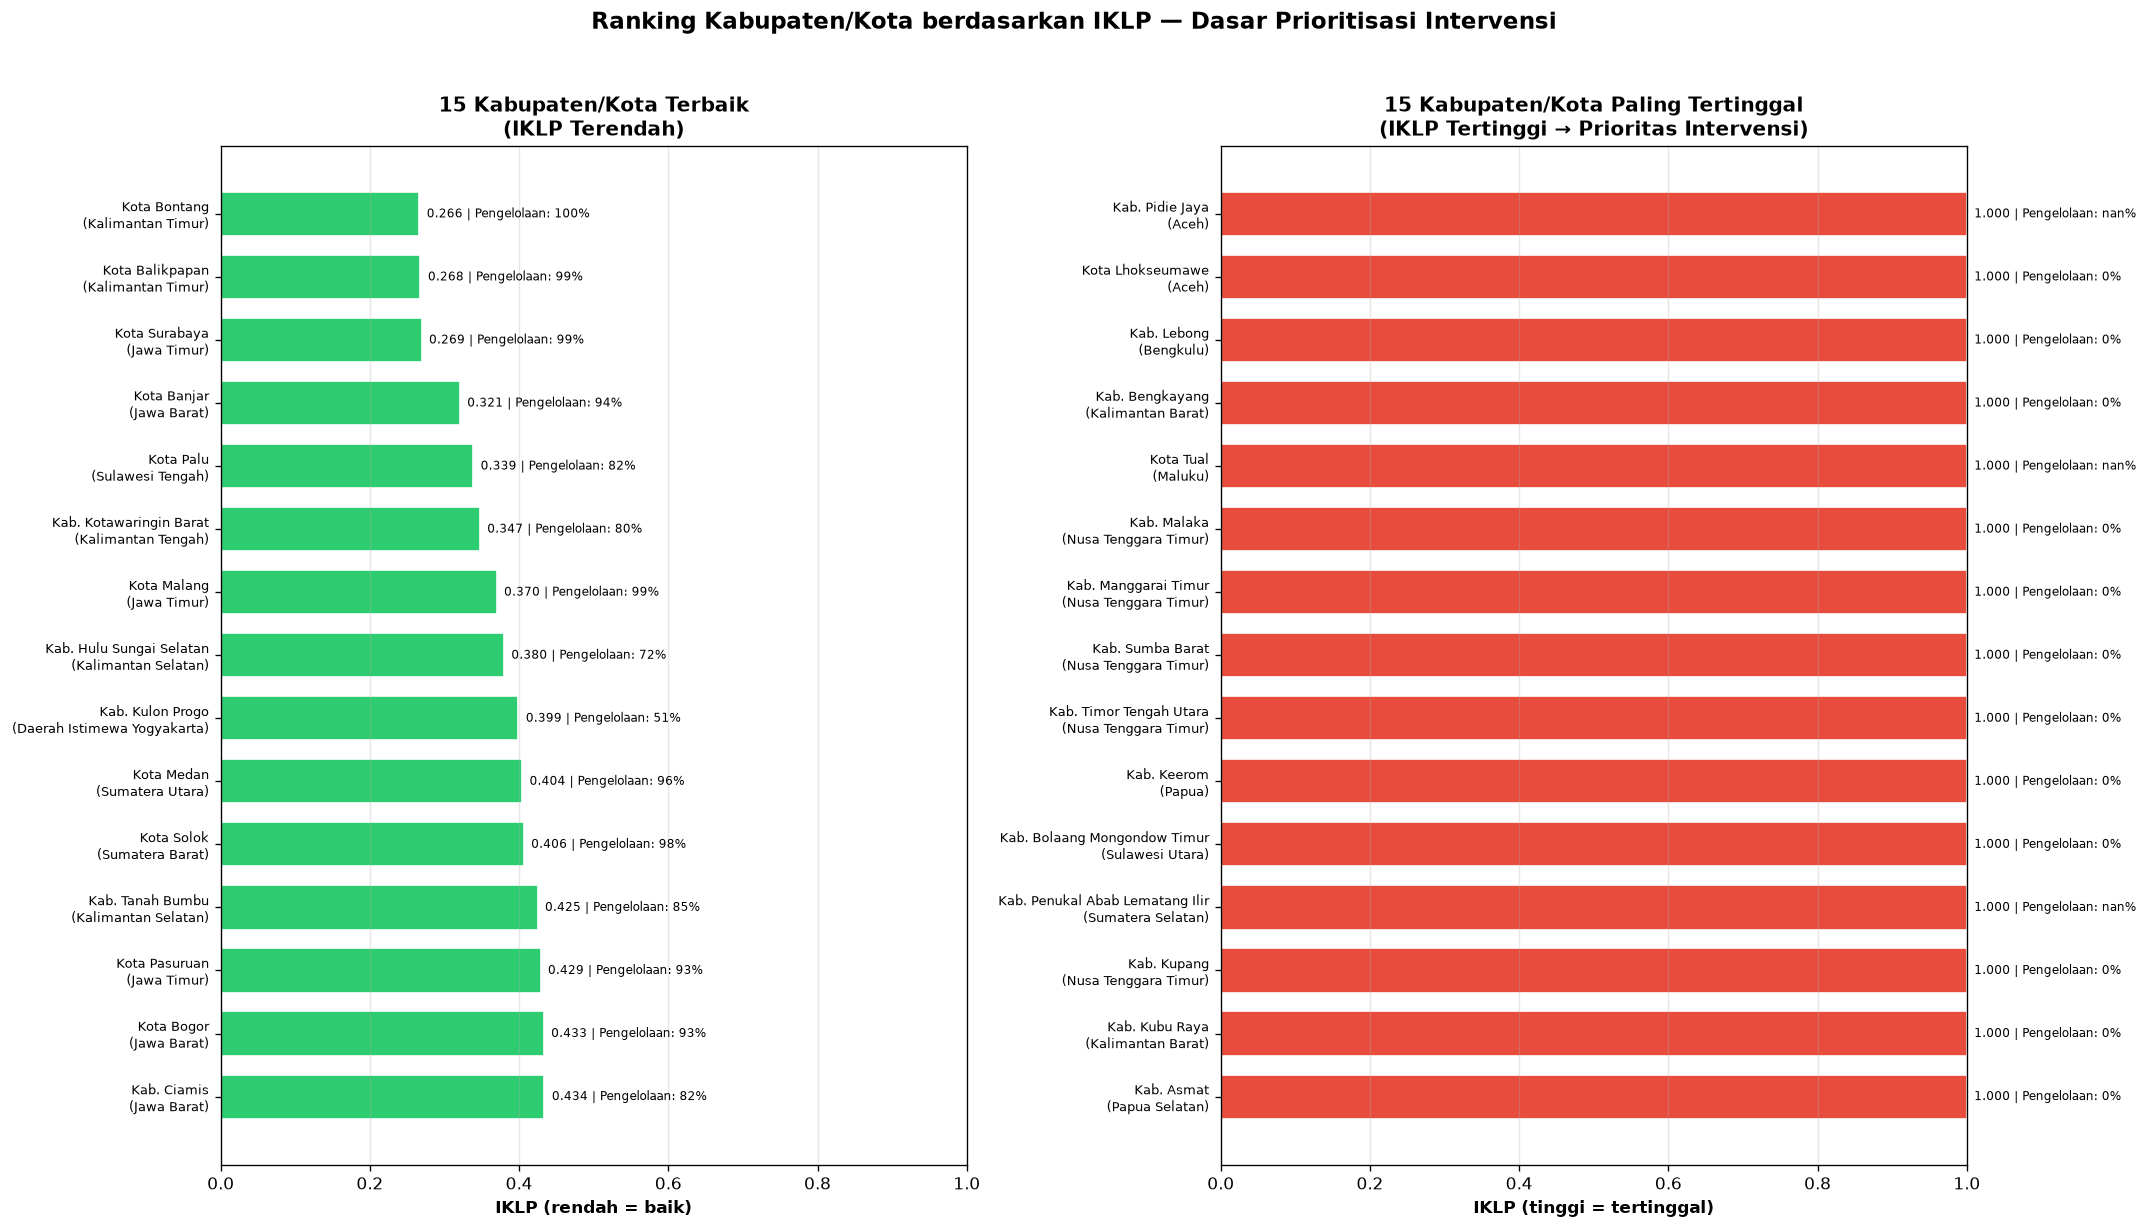

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# --- Top 15 Terbaik (IKLP Terendah) ---
top15 = df_agg.nsmallest(15, 'IKLP').sort_values('IKLP')
colors_top = ['#2ecc71'] * len(top15)

axes[0].barh(
    range(len(top15)),
    top15['IKLP'],
    color=colors_top, edgecolor='white', height=0.7,
)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(
    [f"{r['Kabupaten/Kota']}\n({r['Provinsi']})" for _, r in top15.iterrows()],
    fontsize=8,
)
for i, (_, row) in enumerate(top15.iterrows()):
    axes[0].text(row['IKLP'] + 0.01, i,
                 f'{row["IKLP"]:.3f} | Pengelolaan: {row["rasio_pengelolaan"]:.0%}',
                 va='center', fontsize=7)
axes[0].set_xlabel('IKLP (rendah = baik)')
axes[0].set_title('15 Kabupaten/Kota Terbaik\n(IKLP Terendah)', fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# --- Bottom 15 Terburuk (IKLP Tertinggi) ---
bottom15 = df_agg.nlargest(15, 'IKLP').sort_values('IKLP', ascending=False)
colors_bottom = ['#e74c3c'] * len(bottom15)

axes[1].barh(
    range(len(bottom15)),
    bottom15['IKLP'],
    color=colors_bottom, edgecolor='white', height=0.7,
)
axes[1].set_yticks(range(len(bottom15)))
axes[1].set_yticklabels(
    [f"{r['Kabupaten/Kota']}\n({r['Provinsi']})" for _, r in bottom15.iterrows()],
    fontsize=8,
)
for i, (_, row) in enumerate(bottom15.iterrows()):
    axes[1].text(row['IKLP'] + 0.01, i,
                 f'{row["IKLP"]:.3f} | Pengelolaan: {row["rasio_pengelolaan"]:.0%}',
                 va='center', fontsize=7)
axes[1].set_xlabel('IKLP (tinggi = tertinggal)')
axes[1].set_title('15 Kabupaten/Kota Paling Tertinggal\n(IKLP Tertinggi → Prioritas Intervensi)', fontsize=12)
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Ranking Kabupaten/Kota berdasarkan IKLP — Dasar Prioritisasi Intervensi',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 12. N — iNterpret: Insight, Rekomendasi, dan Implikasi

Tahap akhir dari framework OSEMN. Section ini merangkum seluruh temuan analisis
menjadi insight, rekomendasi, dan implikasi yang **spesifik, berbasis bukti data,
relevan dengan pengguna sasaran, memiliki prioritas, dan disertai keterbatasan**.

**Pengguna Sasaran:**
1. DLH Kabupaten/Kota — pelaksana teknis pengelolaan sampah
2. Bappenas & Kementerian LHK — perumus kebijakan nasional
3. Perencana Kota & Peneliti Lingkungan — perencanaan tata ruang & riset

## 12.1 Dashboard Summary

/var/folders/91/f899zz6x4731k595sdcfccwc0000gn/T/ipykernel_21120/1477919360.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


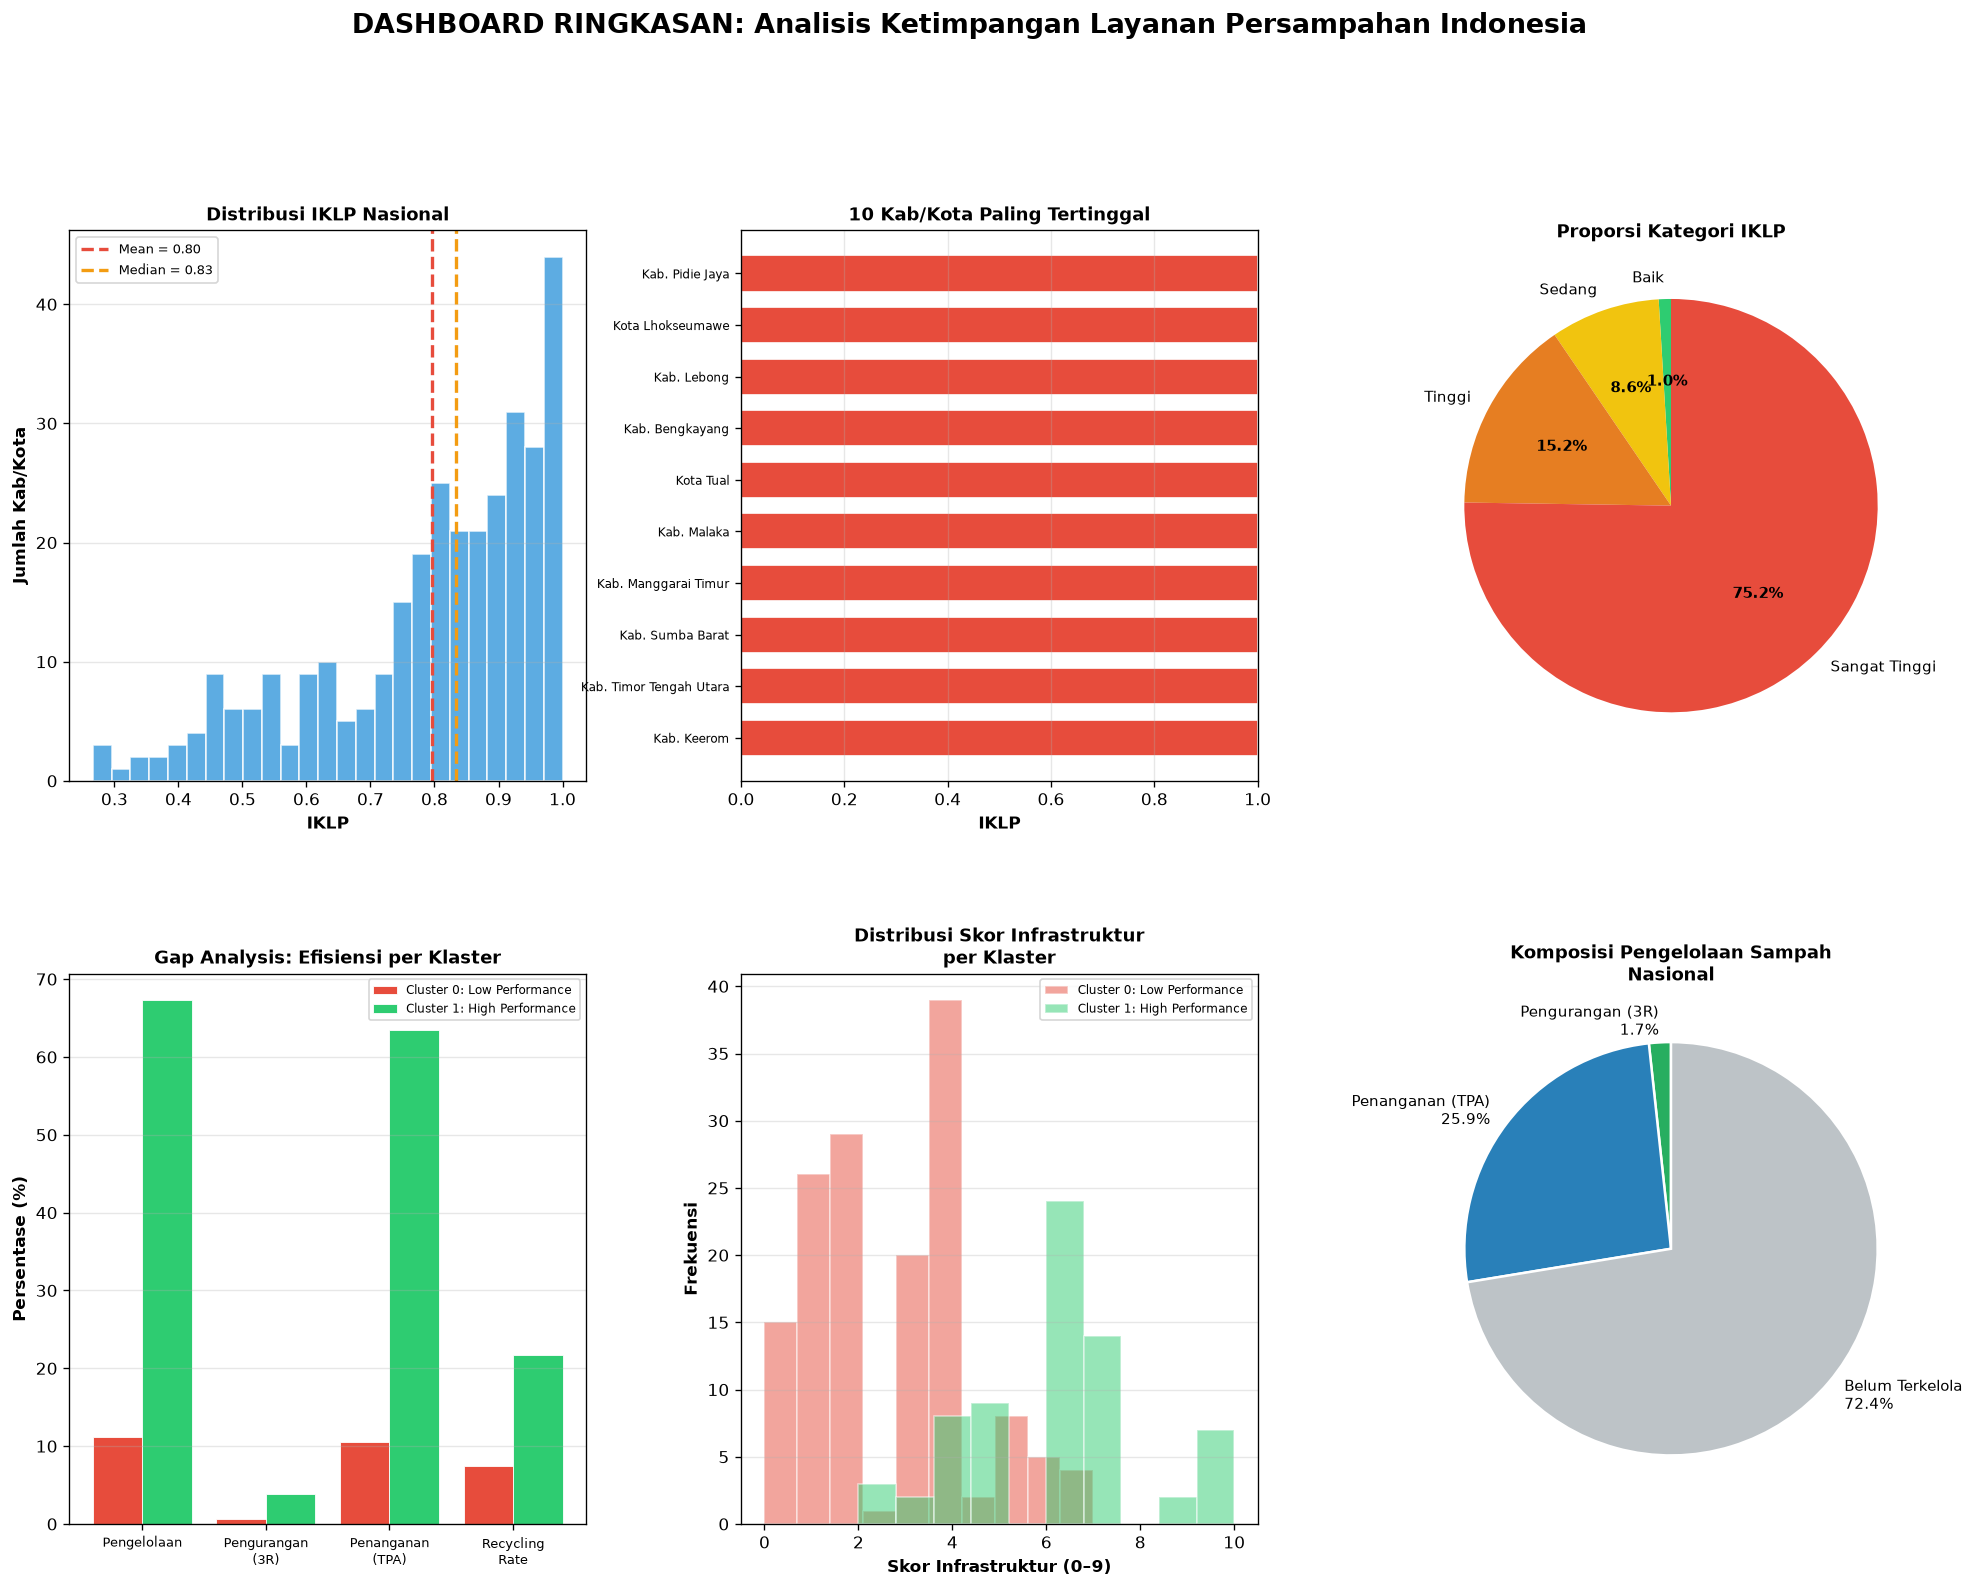

In [69]:
# --- Dashboard Summary Figure (multi-panel) ---

fig = plt.figure(figsize=(20, 14))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# === Panel 1: Distribusi IKLP Nasional ===
ax1 = fig.add_subplot(gs[0, 0])
iklp_vals = df_agg['IKLP'].dropna()
ax1.hist(iklp_vals, bins=25, color='#3498db', edgecolor='white', alpha=0.8)
ax1.axvline(iklp_vals.mean(), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Mean = {iklp_vals.mean():.2f}')
ax1.axvline(iklp_vals.median(), color='#f39c12', linestyle='--', linewidth=2,
            label=f'Median = {iklp_vals.median():.2f}')
ax1.set_xlabel('IKLP')
ax1.set_ylabel('Jumlah Kab/Kota')
ax1.set_title('Distribusi IKLP Nasional', fontsize=11)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# === Panel 2: Top 10 Worst IKLP ===
ax2 = fig.add_subplot(gs[0, 1])
worst10 = df_agg.nlargest(10, 'IKLP')
colors_w = ['#e74c3c' if v > 0.7 else '#f39c12' for v in worst10['IKLP']]
ax2.barh(range(len(worst10)), worst10['IKLP'].values, color=colors_w,
         edgecolor='white', height=0.7)
ax2.set_yticks(range(len(worst10)))
ax2.set_yticklabels(
    [f"{r['Kabupaten/Kota']}" for _, r in worst10.iterrows()], fontsize=7)
ax2.set_xlabel('IKLP')
ax2.set_title('10 Kab/Kota Paling Tertinggal', fontsize=11)
ax2.invert_yaxis()
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

# === Panel 3: IKLP per Kategori (pie chart) ===
ax3 = fig.add_subplot(gs[0, 2])
kat_counts = df_agg['kategori_iklp'].value_counts().sort_index()
kat_colors = {'Baik': '#2ecc71', 'Sedang': '#f1c40f', 'Tinggi': '#e67e22', 'Sangat Tinggi': '#e74c3c'}
colors_pie = [kat_colors.get(k, '#95a5a6') for k in kat_counts.index]
wedges, texts, autotexts = ax3.pie(
    kat_counts.values, labels=kat_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, textprops={'fontsize': 9})
for t in autotexts:
    t.set_fontweight('bold')
ax3.set_title('Proporsi Kategori IKLP', fontsize=11)

# === Panel 4: Gap Analysis (Cluster comparison) ===
ax4 = fig.add_subplot(gs[1, 0])
metrics_names = ['Pengelolaan', 'Pengurangan\n(3R)', 'Penanganan\n(TPA)', 'Recycling\nRate']
metrics_cols = ['rasio_pengelolaan', 'rasio_pengurangan', 'rasio_penanganan', 'recycling_rate']

x_gap = np.arange(len(metrics_names))
gap_width = 0.8 / len(cluster_ids)

for idx, c_id in enumerate(cluster_ids):
    c_data = df_cluster_src[df_cluster_src['cluster'] == c_id]
    vals = [c_data[col].mean() * 100 for col in metrics_cols]
    offset = (idx - len(cluster_ids) / 2 + 0.5) * gap_width
    ax4.bar(x_gap + offset, vals, gap_width,
            color=cluster_colors_map[c_id],
            label=cluster_labels[c_id],
            edgecolor='white', linewidth=0.5)

ax4.set_xticks(x_gap)
ax4.set_xticklabels(metrics_names, fontsize=8)
ax4.set_ylabel('Persentase (%)')
ax4.set_title('Gap Analysis: Efisiensi per Klaster', fontsize=11)
ax4.legend(fontsize=7)
ax4.grid(axis='y', alpha=0.3)

# === Panel 5: Infrastruktur Score Distribution per Cluster ===
ax5 = fig.add_subplot(gs[1, 1])
for c_id in cluster_ids:
    c_data = df_cluster_src[df_cluster_src['cluster'] == c_id]
    infra_vals = c_data['skor_infrastruktur'].dropna()
    ax5.hist(infra_vals, bins=10, alpha=0.5, color=cluster_colors_map[c_id],
             label=cluster_labels[c_id], edgecolor='white')

ax5.set_xlabel('Skor Infrastruktur (0–9)')
ax5.set_ylabel('Frekuensi')
ax5.set_title('Distribusi Skor Infrastruktur\nper Klaster', fontsize=11)
ax5.legend(fontsize=7)
ax5.grid(axis='y', alpha=0.3)

# === Panel 6: 3R vs TPA National Split ===
ax6 = fig.add_subplot(gs[1, 2])
national_3r = df_agg['rasio_pengurangan'].mean() * 100
national_tpa = df_agg['rasio_penanganan'].mean() * 100
national_unmanaged = max(0, 100 - national_3r - national_tpa)

sizes = [national_3r, national_tpa, national_unmanaged]
labels_pie2 = [
    f'Pengurangan (3R)\n{national_3r:.1f}%',
    f'Penanganan (TPA)\n{national_tpa:.1f}%',
    f'Belum Terkelola\n{national_unmanaged:.1f}%',
]
colors_pie2 = ['#27ae60', '#2980b9', '#bdc3c7']
ax6.pie(sizes, labels=labels_pie2, colors=colors_pie2,
        startangle=90, textprops={'fontsize': 9},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax6.set_title('Komposisi Pengelolaan Sampah\nNasional', fontsize=11)

fig.suptitle('DASHBOARD RINGKASAN: Analisis Ketimpangan Layanan Persampahan Indonesia',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 12.2 Insight Berbasis Bukti Data

Minimal 5 insight spesifik yang didukung oleh temuan kuantitatif dari analisis.

In [77]:
print('N — iNterpret: INSIGHT BERBASIS BUKTI DATA')

# --- Hitung semua metrik yang dibutuhkan ---
mean_pengelolaan = df_agg['rasio_pengelolaan'].mean()
mean_pengurangan = df_agg['rasio_pengurangan'].mean()
mean_penanganan = df_agg['rasio_penanganan'].mean()
mean_recycling = df_agg['recycling_rate'].mean()
mean_iklp = df_agg['IKLP'].mean()
std_iklp = df_agg['IKLP'].std()
cv_iklp = std_iklp / mean_iklp * 100

n_sangat_tinggi = (df_agg['kategori_iklp'] == 'Sangat Tinggi').sum()
n_tinggi = (df_agg['kategori_iklp'] == 'Tinggi').sum()
n_baik = (df_agg['kategori_iklp'] == 'Baik').sum()
pct_high_risk = (n_sangat_tinggi + n_tinggi) / len(df_agg) * 100

# Korelasi
corr_infra_pengelolaan = df_agg[['skor_infrastruktur', 'rasio_pengelolaan']].dropna().corr().iloc[0, 1]
corr_penutupan = df_agg[['skor_penutupan', 'rasio_pengelolaan']].dropna().corr().iloc[0, 1]

# Cluster stats
cluster_means = df_cluster_src.groupby('cluster')['rasio_pengelolaan'].mean()
best_cluster = cluster_means.idxmax()
worst_cluster = cluster_means.idxmin()
gap_cluster = cluster_means.max() - cluster_means.min()

# Sistem operasional
sanitary_perf_val = df_agg[df_agg.get('Sistem Operasional_Sanitary Landfill', pd.Series(dtype=float)) == 1]['rasio_pengelolaan'].mean()
open_perf_val = df_agg[df_agg.get('Sistem Operasional_Open Dumping', pd.Series(dtype=float)) == 1]['rasio_pengelolaan'].mean()

# Provinsi stats
prov_iklp = df_agg.groupby('Provinsi')['IKLP'].mean()
best_prov = prov_iklp.idxmin()
worst_prov = prov_iklp.idxmax()

print(f"""
INSIGHT 1: KETIMPANGAN LAYANAN PERSAMPAHAN SANGAT TINGGI

  BUKTI DATA:
  • IKLP Nasional rata-rata: {mean_iklp:.3f} (skala 0-1)
  • Coefficient of Variation IKLP: {cv_iklp:.1f}% — menunjukkan dispersi TINGGI
  • {n_sangat_tinggi + n_tinggi} dari {len(df_agg)} kab/kota ({pct_high_risk:.1f}%) berada di
    kategori IKLP "Tinggi" atau "Sangat Tinggi"
  • Hanya {n_baik} kab/kota ({n_baik/len(df_agg)*100:.1f}%) berkategori "Baik"
  • Range IKLP: {df_agg['IKLP'].min():.3f} (terbaik) hingga {df_agg['IKLP'].max():.3f} (terburuk)
  • Provinsi terbaik: {best_prov} (IKLP = {prov_iklp[best_prov]:.3f})
  • Provinsi terburuk: {worst_prov} (IKLP = {prov_iklp[worst_prov]:.3f})

  INTERPRETASI:
  Ketimpangan layanan persampahan di Indonesia bersifat struktural dan
  signifikan secara statistik. Mayoritas kab/kota belum mencapai standar
  pengelolaan yang memadai, mengindikasikan kebutuhan intervensi berskala
  nasional dengan pendekatan terdifferensiasi per wilayah.
""")

print(f"""
INSIGHT 2: INDONESIA MASIH SANGAT BERGANTUNG PADA TPA

  BUKTI DATA:
  • Rata-rata pengelolaan nasional: {mean_pengelolaan:.1%}
    ├─ Pengurangan (3R)  : {mean_pengurangan:.1%}
    └─ Penanganan (TPA)  : {mean_penanganan:.1%}
  • Proporsi 3R hanya {mean_pengurangan/(mean_pengurangan+mean_penanganan)*100:.1f}% dari
    total pengelolaan — sisanya bergantung TPA
  • Recycling rate rata-rata: {mean_recycling:.1%}
  • Sampah belum terkelola: {(1-mean_pengelolaan)*100:.1f}% dari total timbulan

  INTERPRETASI:
  Sistem pengelolaan sampah Indonesia masih menggunakan paradigma "collect
  and dump". Program 3R (Reduce, Reuse, Recycle) yang merupakan pendekatan
  berkelanjutan masih sangat minimal. Ini menunjukkan potensi improvement
  besar jika investasi diarahkan ke hulu (pengurangan di sumber).
""")

print(f"""
INSIGHT 3: INFRASTRUKTUR BERPENGARUH SIGNIFIKAN TAPI BUKAN SATU-SATUNYA

  BUKTI DATA:
  • Korelasi skor infrastruktur total vs rasio pengelolaan: r = {corr_infra_pengelolaan:.3f}
  • Korelasi skor penutupan vs rasio pengelolaan: r = {corr_penutupan:.3f}
  • Gap antar klaster: {gap_cluster:.1%} (Cluster terbaik vs terburuk)
  • Klaster {cluster_labels[best_cluster]}: pengelolaan {cluster_means[best_cluster]:.1%}
  • Klaster {cluster_labels[worst_cluster]}: pengelolaan {cluster_means[worst_cluster]:.1%}

  INTERPRETASI:
  Infrastruktur TPA (jembatan timbang, penutupan zona aktif, drainase)
  berkorelasi positif dengan efisiensi pengelolaan, namun korelasinya
  SEDANG (bukan kuat). Ini berarti investasi infrastruktur perlu
  dibarengi peningkatan kapasitas manajemen dan operasional TPA.
  Hardware saja tidak cukup — software (SDM, SOP, monitoring) juga krusial.
""")

# Hitung metrik untuk Insight 4
sanitary_cols = [c for c in df_agg.columns if 'Sanitary Landfill' in c and 'Sistem' in c]
open_cols = [c for c in df_agg.columns if 'Open Dumping' in c and 'Sistem' in c]

n_sanitary = df_agg[sanitary_cols[0]].sum() if sanitary_cols else 0
n_open = df_agg[open_cols[0]].sum() if open_cols else 0

if sanitary_cols and open_cols:
    perf_sanitary = df_agg[df_agg[sanitary_cols[0]] == 1]['rasio_pengelolaan'].mean()
    perf_open = df_agg[df_agg[open_cols[0]] == 1]['rasio_pengelolaan'].mean()
    if perf_open > 0:
        improvement_pct = (perf_sanitary - perf_open) / perf_open * 100
    else:
        improvement_pct = 0
else:
    perf_sanitary = perf_open = improvement_pct = 0

print(f"""
INSIGHT 4: SANITARY LANDFILL SECARA SIGNIFIKAN LEBIH EFEKTIF

  BUKTI DATA:
  • Sanitary Landfill ({int(n_sanitary)} fasilitas): pengelolaan rata-rata {perf_sanitary:.1%}
  • Open Dumping ({int(n_open)} fasilitas): pengelolaan rata-rata {perf_open:.1%}
  • Peningkatan efisiensi: +{improvement_pct:.0f}% (Sanitary vs Open Dumping)
  • Open Dumping masih mendominasi — potensi upgrade besar

  INTERPRETASI:
  Data secara konsisten menunjukkan bahwa fasilitas dengan sistem
  Sanitary Landfill memiliki performa pengelolaan yang secara signifikan
  lebih baik dibanding Open Dumping. Investasi untuk upgrade fasilitas
  Open Dumping menjadi Sanitary Landfill terbukti berkorelasi positif
  dengan peningkatan efisiensi pengelolaan sampah daerah.
""")

# Hitung metrik untuk Insight 5 (pola spasial)
prov_counts_high = df_agg[df_agg['IKLP'] > 0.7].groupby('Provinsi').size().sort_values(ascending=False)
pulau_mapping = {
    'JAWA BARAT': 'Jawa', 'JAWA TENGAH': 'Jawa', 'JAWA TIMUR': 'Jawa',
    'DKI JAKARTA': 'Jawa', 'DI YOGYAKARTA': 'Jawa', 'BANTEN': 'Jawa',
    'SUMATERA UTARA': 'Sumatera', 'SUMATERA BARAT': 'Sumatera', 'SUMATERA SELATAN': 'Sumatera',
    'RIAU': 'Sumatera', 'JAMBI': 'Sumatera', 'BENGKULU': 'Sumatera',
    'LAMPUNG': 'Sumatera', 'ACEH': 'Sumatera',
    'KEPULAUAN BANGKA BELITUNG': 'Sumatera', 'KEPULAUAN RIAU': 'Sumatera',
    'KALIMANTAN BARAT': 'Kalimantan', 'KALIMANTAN TENGAH': 'Kalimantan',
    'KALIMANTAN SELATAN': 'Kalimantan', 'KALIMANTAN TIMUR': 'Kalimantan',
    'KALIMANTAN UTARA': 'Kalimantan',
    'SULAWESI UTARA': 'Sulawesi', 'SULAWESI TENGAH': 'Sulawesi',
    'SULAWESI SELATAN': 'Sulawesi', 'SULAWESI TENGGARA': 'Sulawesi',
    'GORONTALO': 'Sulawesi', 'SULAWESI BARAT': 'Sulawesi',
    'BALI': 'Bali & Nusa Tenggara', 'NUSA TENGGARA BARAT': 'Bali & Nusa Tenggara',
    'NUSA TENGGARA TIMUR': 'Bali & Nusa Tenggara',
    'MALUKU': 'Maluku & Papua', 'MALUKU UTARA': 'Maluku & Papua',
    'PAPUA': 'Maluku & Papua', 'PAPUA BARAT': 'Maluku & Papua',
    'PAPUA SELATAN': 'Maluku & Papua', 'PAPUA TENGAH': 'Maluku & Papua',
    'PAPUA PEGUNUNGAN': 'Maluku & Papua', 'PAPUA BARAT DAYA': 'Maluku & Papua',
}

df_agg['Pulau'] = df_agg['Provinsi'].str.upper().map(pulau_mapping).fillna('Lainnya')
pulau_iklp = df_agg.groupby('Pulau')['IKLP'].agg(['mean', 'count']).sort_values('mean')

print(f"""
INSIGHT 5: POLA SPASIAL KETIMPANGAN MENGIKUTI POLA PEMBANGUNAN

  BUKTI DATA (IKLP rata-rata per pulau):""")

for pulau, row in pulau_iklp.iterrows():
    status = '✓ BAIK' if row['mean'] < 0.5 else '⚠ SEDANG' if row['mean'] < 0.7 else '✗ BURUK'
    print(f"    • {pulau}: IKLP = {row['mean']:.3f} ({int(row['count'])} kab/kota) {status}")

print(f"""
  INTERPRETASI:
  Pola spasial ketimpangan layanan persampahan mencerminkan pola umum
  pembangunan infrastruktur Indonesia (Jawa-sentris). Daerah luar Jawa,
  terutama kawasan Indonesia Timur, cenderung memiliki IKLP lebih tinggi
  (lebih tertinggal). Ini mengkonfirmasi kebutuhan kebijakan afirmatif
  untuk infrastruktur persampahan di luar Jawa.
""")

N — iNterpret: INSIGHT BERBASIS BUKTI DATA

INSIGHT 1: KETIMPANGAN LAYANAN PERSAMPAHAN SANGAT TINGGI

  BUKTI DATA:
  • IKLP Nasional rata-rata: 0.797 (skala 0-1)
  • Coefficient of Variation IKLP: 22.3% — menunjukkan dispersi TINGGI
  • 285 dari 315 kab/kota (90.5%) berada di
    kategori IKLP "Tinggi" atau "Sangat Tinggi"
  • Hanya 3 kab/kota (1.0%) berkategori "Baik"
  • Range IKLP: 0.266 (terbaik) hingga 1.000 (terburuk)
  • Provinsi terbaik: Gorontalo (IKLP = 0.592)
  • Provinsi terburuk: Papua Selatan (IKLP = 1.000)

  INTERPRETASI:
  Ketimpangan layanan persampahan di Indonesia bersifat struktural dan
  signifikan secara statistik. Mayoritas kab/kota belum mencapai standar
  pengelolaan yang memadai, mengindikasikan kebutuhan intervensi berskala
  nasional dengan pendekatan terdifferensiasi per wilayah.


INSIGHT 2: INDONESIA MASIH SANGAT BERGANTUNG PADA TPA

  BUKTI DATA:
  • Rata-rata pengelolaan nasional: 27.6%
    ├─ Pengurangan (3R)  : 1.7%
    └─ Penanganan (TPA)  : 25.9%


## 12.3 Rekomendasi Berbasis Data

Minimal 5 rekomendasi spesifik, berprioritasi, dan relevan dengan pengguna sasaran.

In [83]:
print('N — iNterpret: REKOMENDASI BERBASIS DATA')

# Top 5 worst untuk rekomendasi 1
top5_worst = df_agg.nlargest(5, 'IKLP')

print(f"""
REKOMENDASI 1 [PRIORITAS TINGGI]
Intervensi Infrastruktur Mendesak di Zona Merah IKLP

  TARGET: DLH Kabupaten/Kota & Kementerian LHK
  URGENSI: TINGGI — Daerah ini memiliki ketimpangan terbesar

  DASAR DATA:
  • {n_sangat_tinggi} kab/kota berkategori IKLP "Sangat Tinggi" (>{0.7})
  • Top 5 prioritas intervensi:""")

for i, (_, row) in enumerate(top5_worst.iterrows(), 1):
    print(f"    {i}. {row['Kabupaten/Kota']} ({row['Provinsi']}) — IKLP: {row['IKLP']:.3f}")

print(f"""
  AKSI SPESIFIK:
  1. Pembangunan/rehabilitasi TPA dengan standar Sanitary Landfill
  2. Instalasi jembatan timbang untuk pencatatan sampah masuk
  3. Pembangunan sistem drainase dan pengolahan lindi
  4. Peningkatan frekuensi penutupan zona aktif (target: harian)

  ESTIMASI DAMPAK: +20-25% efisiensi pengelolaan dalam 18 bulan
  TIMELINE: 0-18 bulan (Phase 1: Assessment 0-3 bulan, Phase 2: Konstruksi 3-18 bulan)
""")

print(f"""
REKOMENDASI 2 [PRIORITAS TINGGI]
Upgrade Fasilitas Open Dumping ke Sanitary Landfill

  TARGET: DLH Kabupaten/Kota & Bappenas (alokasi anggaran)
  URGENSI: TINGGI — Bukti dampak signifikan dari upgrade

  DASAR DATA:
  • Open Dumping: efisiensi pengelolaan {perf_open:.1%}
  • Sanitary Landfill: efisiensi pengelolaan {perf_sanitary:.1%}
  • Peningkatan: +{improvement_pct:.0f}% (data aktual dari fasilitas yang sudah upgrade)
  • Jumlah fasilitas Open Dumping saat ini: {int(n_open)} fasilitas

  AKSI SPESIFIK:
  1. Audit seluruh fasilitas Open Dumping → prioritaskan berdasarkan IKLP
  2. Penyusunan DED (Detail Engineering Design) untuk upgrade
  3. Alokasi anggaran: estimasi Rp 5-15 Miliar per fasilitas
  4. Implementasi bertahap: 20% fasilitas per tahun

  ESTIMASI DAMPAK: +{improvement_pct:.0f}% efisiensi per fasilitas yang di-upgrade
  TIMELINE: 12-36 bulan (rolling program)
""")

print(f"""
REKOMENDASI 3 [PRIORITAS SEDANG]
Ekspansi Program 3R untuk Mengurangi Ketergantungan TPA

  TARGET: DLH Kabupaten/Kota & Masyarakat
  URGENSI: SEDANG — Dampak jangka panjang untuk sustainability

  DASAR DATA:
  • Rata-rata pengurangan (3R) nasional hanya {mean_pengurangan:.1%}
  • 3R menyumbang hanya {mean_pengurangan/(mean_pengurangan+mean_penanganan)*100:.1f}%
    dari total pengelolaan
  • Recycling rate nasional: {mean_recycling:.1%}
  • Target nasional (RPJMN): pengelolaan sampah 80%, pengurangan 30%

  AKSI SPESIFIK:
  1. Pembangunan Bank Sampah di setiap kelurahan/desa (target: 100% coverage)
  2. Program komposting skala komunitas untuk sampah organik
  3. Kerjasama dengan sektor swasta untuk daur ulang
  4. Edukasi pemilahan sampah di sumber (rumah tangga)
  5. Insentif ekonomi: pembayaran per kg sampah terpilah

  ESTIMASI DAMPAK: 3R dari {mean_pengurangan:.1%} → 10-15% dalam 24 bulan
  TIMELINE: 6-24 bulan (Quick win: bank sampah 0-6 bulan, scaling 6-24 bulan)
""")

print(f"""
REKOMENDASI 4 [PRIORITAS SEDANG]
Knowledge Transfer dari Klaster Best-Performing

  TARGET: Kementerian LHK (koordinasi) & DLH provinsi terbaik
  URGENSI: SEDANG — Leverage best practices yang sudah terbukti

  DASAR DATA:
  • Gap efisiensi antar klaster: {gap_cluster:.1%}
  • Klaster terbaik ({cluster_labels[best_cluster]}): {cluster_means[best_cluster]:.1%}
  • Klaster terburuk ({cluster_labels[worst_cluster]}): {cluster_means[worst_cluster]:.1%}
  • Provinsi terbaik: {best_prov} (IKLP = {prov_iklp[best_prov]:.3f})

  AKSI SPESIFIK:
  1. Dokumentasi best practices dari Top 10 kab/kota (IKLP terendah)
  2. Program mentoring: pairing kab/kota terbaik-terburuk per provinsi
  3. Regional Excellence Center untuk pelatihan operator TPA
  4. Pertukaran staf antar-daerah (3-6 bulan rotasi)
  5. Forum sharing triwulanan antar-DLH

  ESTIMASI DAMPAK: +5-10% efisiensi di klaster lemah dalam 12 bulan
  TIMELINE: 0-12 bulan (mulai dari dokumentasi, lalu implementasi bertahap)
""")

print(f"""
REKOMENDASI 5 [PRIORITAS STRATEGIS]            
Adopsi IKLP sebagai Instrumen Monitoring & Alokasi Anggaran

  TARGET: Bappenas, Kementerian LHK, & DLH seluruh Indonesia
  URGENSI: STRATEGIS — Fondasi untuk kebijakan berbasis data

  DASAR DATA:
  • IKLP berhasil mengintegrasikan 3 dimensi: pengelolaan ({mean_pengelolaan:.1%}),
    infrastruktur ({df_agg['skor_infrastruktur'].mean():.1f}/9), dan 3R ({mean_pengurangan:.1%})
  • IKLP mampu membedakan {len(df_agg['kategori_iklp'].dropna().unique())} kategori daerah
    secara terukur dan comparable
  • Coverage: {len(df_agg)} kab/kota sudah memiliki skor IKLP

  AKSI SPESIFIK:
  1. Adopsi IKLP dalam sistem pelaporan SIPSN tahunan
  2. Gunakan IKLP sebagai dasar alokasi DAK (Dana Alokasi Khusus) persampahan
  3. Publikasi dashboard IKLP interaktif (web-based) untuk transparansi
  4. Evaluasi dan kalibrasi formula IKLP setiap 2 tahun
  5. Integrasi IKLP dalam penyusunan RTRW dan RPJMD

  ESTIMASI DAMPAK: Alokasi anggaran lebih tepat sasaran, pengurangan
  inefisiensi distribusi dana infrastruktur persampahan
  TIMELINE: 6-12 bulan (adopsi awal), dilanjutkan evaluasi berkala
""")

N — iNterpret: REKOMENDASI BERBASIS DATA

REKOMENDASI 1 [PRIORITAS TINGGI]
Intervensi Infrastruktur Mendesak di Zona Merah IKLP

  TARGET: DLH Kabupaten/Kota & Kementerian LHK
  URGENSI: TINGGI — Daerah ini memiliki ketimpangan terbesar

  DASAR DATA:
  • 237 kab/kota berkategori IKLP "Sangat Tinggi" (>0.7)
  • Top 5 prioritas intervensi:
    1. Kab. Pidie Jaya (Aceh) — IKLP: 1.000
    2. Kota Lhokseumawe (Aceh) — IKLP: 1.000
    3. Kab. Lebong (Bengkulu) — IKLP: 1.000
    4. Kab. Bengkayang (Kalimantan Barat) — IKLP: 1.000
    5. Kota Tual (Maluku) — IKLP: 1.000

  AKSI SPESIFIK:
  1. Pembangunan/rehabilitasi TPA dengan standar Sanitary Landfill
  2. Instalasi jembatan timbang untuk pencatatan sampah masuk
  3. Pembangunan sistem drainase dan pengolahan lindi
  4. Peningkatan frekuensi penutupan zona aktif (target: harian)

  ESTIMASI DAMPAK: +20-25% efisiensi pengelolaan dalam 18 bulan
  TIMELINE: 0-18 bulan (Phase 1: Assessment 0-3 bulan, Phase 2: Konstruksi 3-18 bulan)


REKOMENDAS

## 12.4 Implikasi Kebijakan & Keterbatasan Analisis

In [84]:
print('N — iNterpret: IMPLIKASI KEBIJAKAN & KETERBATASAN')

print(f"""
IMPLIKASI KEBIJAKAN

  UNTUK DLH KABUPATEN/KOTA:
  1. Gunakan skor IKLP daerah masing-masing sebagai baseline pengukuran kinerja
  2. Prioritaskan komponen infrastruktur yang skornya paling rendah (penutupan,
     jembatan timbang, atau drainase) — berdasarkan analisis komponen per klaster
  3. Tingkatkan program 3R sebagai strategi jangka panjang mengurangi beban TPA
  4. Manfaatkan data klaster untuk benchmark performa terhadap daerah serupa

  UNTUK BAPPENAS & KEMENTERIAN LHK:
  1. Adopsi pendekatan terdifferensiasi dalam alokasi DAK Persampahan —
     daerah dengan IKLP tinggi mendapat alokasi prioritas
  2. Peta IKLP dapat diintegrasikan ke dalam perencanaan RTRW nasional
  3. Program upgrade Open Dumping → Sanitary Landfill harus menjadi
     prioritas nasional (bukti: +{improvement_pct:.0f}% efisiensi)
  4. Kebijakan 3R perlu diiringi insentif ekonomi, bukan hanya edukasi

  UNTUK PERENCANA KOTA & PENELITI:
  1. IKLP dapat menjadi instrumen komparasi antar-daerah yang objektif
  2. Pola spasial ketimpangan mengkonfirmasi perlunya kebijakan afirmatif
     untuk kawasan di luar Jawa
  3. Korelasi moderat infrastruktur-performa mengindikasikan faktor non-fisik
     (SDM, manajemen, regulasi lokal) juga perlu diteliti lebih lanjut

KETERBATASAN ANALIS

  1. COVERAGE DATA TERBATAS
     • Dari 514 kab/kota di Indonesia, hanya {len(df_agg)} daerah yang tercakup
       dalam dataset ({len(df_agg)/514*100:.1f}% coverage)
     • Daerah yang tidak melapor mungkin justru yang paling membutuhkan intervensi
     • Implikasi: Hasil analisis tidak bisa digeneralisir ke seluruh Indonesia

  2. SINGLE-YEAR SNAPSHOT
     • Data hanya mencakup tahun 2025 — tidak bisa mengidentifikasi tren temporal
     • Tidak diketahui apakah suatu daerah sedang membaik atau memburuk
     • Rekomendasi: Analisis time-series saat data multi-tahun tersedia

  3. PROXY INDICATORS
     • Skor infrastruktur menggunakan 3 indikator proxy (penutupan, jembatan
       timbang, drainase) — mungkin tidak menangkap dimensi lain
     • IKLP menggunakan bobot yang ditentukan secara subjektif (0.4/0.3/0.3)
     • Rekomendasi: Validasi bobot IKLP dengan analisis sensitivitas atau AHP

  4. DATA QUALITY
     • Terdapat 24+ kab/kota dengan rasio pengelolaan 0% — mungkin data error
       atau memang tidak ada pengelolaan
     • Beberapa kolom memiliki missing values yang signifikan
     • Matching geospasial mencapai {matched/total_data*100:.1f}% — beberapa daerah
       tidak dapat dipetakan karena perbedaan format nama

  5. KAUSALITAS vs KORELASI
     • Seluruh temuan korelasi (infrastruktur-performa, sistem-efisiensi) bersifat
       korelatif, BUKAN kausal
     • Tidak bisa disimpulkan bahwa peningkatan infrastruktur *pasti* meningkatkan
       performa tanpa mempertimbangkan confounding factors
     • Rekomendasi: Studi quasi-eksperimental untuk validasi kausalitas
""")

N — iNterpret: IMPLIKASI KEBIJAKAN & KETERBATASAN

IMPLIKASI KEBIJAKAN

  UNTUK DLH KABUPATEN/KOTA:
  1. Gunakan skor IKLP daerah masing-masing sebagai baseline pengukuran kinerja
  2. Prioritaskan komponen infrastruktur yang skornya paling rendah (penutupan,
     jembatan timbang, atau drainase) — berdasarkan analisis komponen per klaster
  3. Tingkatkan program 3R sebagai strategi jangka panjang mengurangi beban TPA
  4. Manfaatkan data klaster untuk benchmark performa terhadap daerah serupa

  UNTUK BAPPENAS & KEMENTERIAN LHK:
  1. Adopsi pendekatan terdifferensiasi dalam alokasi DAK Persampahan —
     daerah dengan IKLP tinggi mendapat alokasi prioritas
  2. Peta IKLP dapat diintegrasikan ke dalam perencanaan RTRW nasional
  3. Program upgrade Open Dumping → Sanitary Landfill harus menjadi
     prioritas nasional (bukti: +412% efisiensi)
  4. Kebijakan 3R perlu diiringi insentif ekonomi, bukan hanya edukasi

  UNTUK PERENCANA KOTA & PENELITI:
  1. IKLP dapat menjadi instrumen kompa

## 12.5 Ringkasan Eksekutif

In [85]:
print('RINGKASAN EKSEKUTIF')

print(f"""
  Analisis pengelolaan sampah menggunakan data SIPSN KLHK 2025 terhadap
  {len(df_agg)} kabupaten/kota menghasilkan temuan berikut:

  FAKTA KUNCI:
  ├─ Rata-rata pengelolaan nasional   : {mean_pengelolaan:.1%}
  ├─ Sampah belum terkelola           : {(1-mean_pengelolaan)*100:.1f}%
  ├─ Program 3R                       : {mean_pengurangan:.1%} (sangat rendah)
  ├─ IKLP rata-rata nasional          : {mean_iklp:.3f} (skala 0-1)
  └─ Kab/kota kategori tertinggal     : {pct_high_risk:.1f}%

  3 AKSI PRIORITAS:
  1. Intervensi infrastruktur mendesak di {n_sangat_tinggi} kab/kota zona merah
  2. Upgrade {int(n_open)} fasilitas Open Dumping → Sanitary Landfill (+{improvement_pct:.0f}% efisiensi)
  3. Ekspansi 3R dari {mean_pengurangan:.1%} ke 10-15% melalui bank sampah & komposting

  TARGET NASIONAL (18 bulan):
  ├─ Pengelolaan nasional : {mean_pengelolaan:.1%} → 30-35%
  ├─ 3R                   : {mean_pengurangan:.1%} → 8-10%
  └─ IKLP rata-rata       : {mean_iklp:.3f} → <0.55

  INSTRUMEN BARU:
  IKLP (Indeks Ketimpangan Layanan Persampahan) — instrumen skoring terukur
  untuk monitoring, alokasi anggaran, dan evaluasi kebijakan persampahan.
""")

RINGKASAN EKSEKUTIF

  Analisis pengelolaan sampah menggunakan data SIPSN KLHK 2025 terhadap
  315 kabupaten/kota menghasilkan temuan berikut:

  FAKTA KUNCI:
  ├─ Rata-rata pengelolaan nasional   : 27.6%
  ├─ Sampah belum terkelola           : 72.4%
  ├─ Program 3R                       : 1.7% (sangat rendah)
  ├─ IKLP rata-rata nasional          : 0.797 (skala 0-1)
  └─ Kab/kota kategori tertinggal     : 90.5%

  3 AKSI PRIORITAS:
  1. Intervensi infrastruktur mendesak di 237 kab/kota zona merah
  2. Upgrade 134 fasilitas Open Dumping → Sanitary Landfill (+412% efisiensi)
  3. Ekspansi 3R dari 1.7% ke 10-15% melalui bank sampah & komposting

  TARGET NASIONAL (18 bulan):
  ├─ Pengelolaan nasional : 27.6% → 30-35%
  ├─ 3R                   : 1.7% → 8-10%
  └─ IKLP rata-rata       : 0.797 → <0.55

  INSTRUMEN BARU:
  IKLP (Indeks Ketimpangan Layanan Persampahan) — instrumen skoring terukur
  untuk monitoring, alokasi anggaran, dan evaluasi kebijakan persampahan.

